# <font color="steelblue">Árboles de decisión</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 08/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

## <font color="steelblue">Configuración del cuaderno</font>

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade
!pip install graphviz

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV, KFold
from sklearn.feature_selection import RFE, f_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
from sklearn.metrics import pairwise_distances

RNG = 42

# Árboles de decisión y utilidades
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, export_graphviz
import graphviz
from sklearn.datasets import make_blobs, make_moons


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.23.4
    Uninstalling mlxtend-0.23.4:
      Successfully uninstalled mlxtend-0.23.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.1 MB/s eta 0:00:00


# <font color="steelblue">Introducción</font>

Piensa en cómo un médico hace un primer cribado: *¿la fiebre supera 38°? Si sí, ¿hay tos? Si no, ¿hay dolor?*… Cada respuesta lleva a otra pregunta, hasta un diagnóstico. Un **árbol de decisión** funciona igual: encadena **preguntas binarias sencillas** sobre las variables ("¿$X_1 \le 3$?") que dividen los datos en grupos cada vez más **homogéneos**, hasta asignar una clase.

Esto les da propiedades atractivas: son **interpretables**, **no paramétricos**, apenas necesitan **preprocesado** y capturan **interacciones** de forma natural. Su debilidad es la **tendencia al sobreajuste**, cuyo control —**parada temprana** y **poda**— es el corazón de este cuaderno. Además, son la **pieza básica** de modelos más potentes (*Random Forest*, *Gradient Boosting*).

Construiremos la intuición con **tres juguetes** en dos dimensiones y luego aplicaremos el método a **dos conjuntos de datos reales** con las funciones del curso.

# <font color="steelblue">1. Árboles de decisión: anatomía y geometría</font>

Presentamos los **tres juguetes**: dos grupos **bien separados**, dos grupos **más mezclados** y un caso de **tres grupos**.

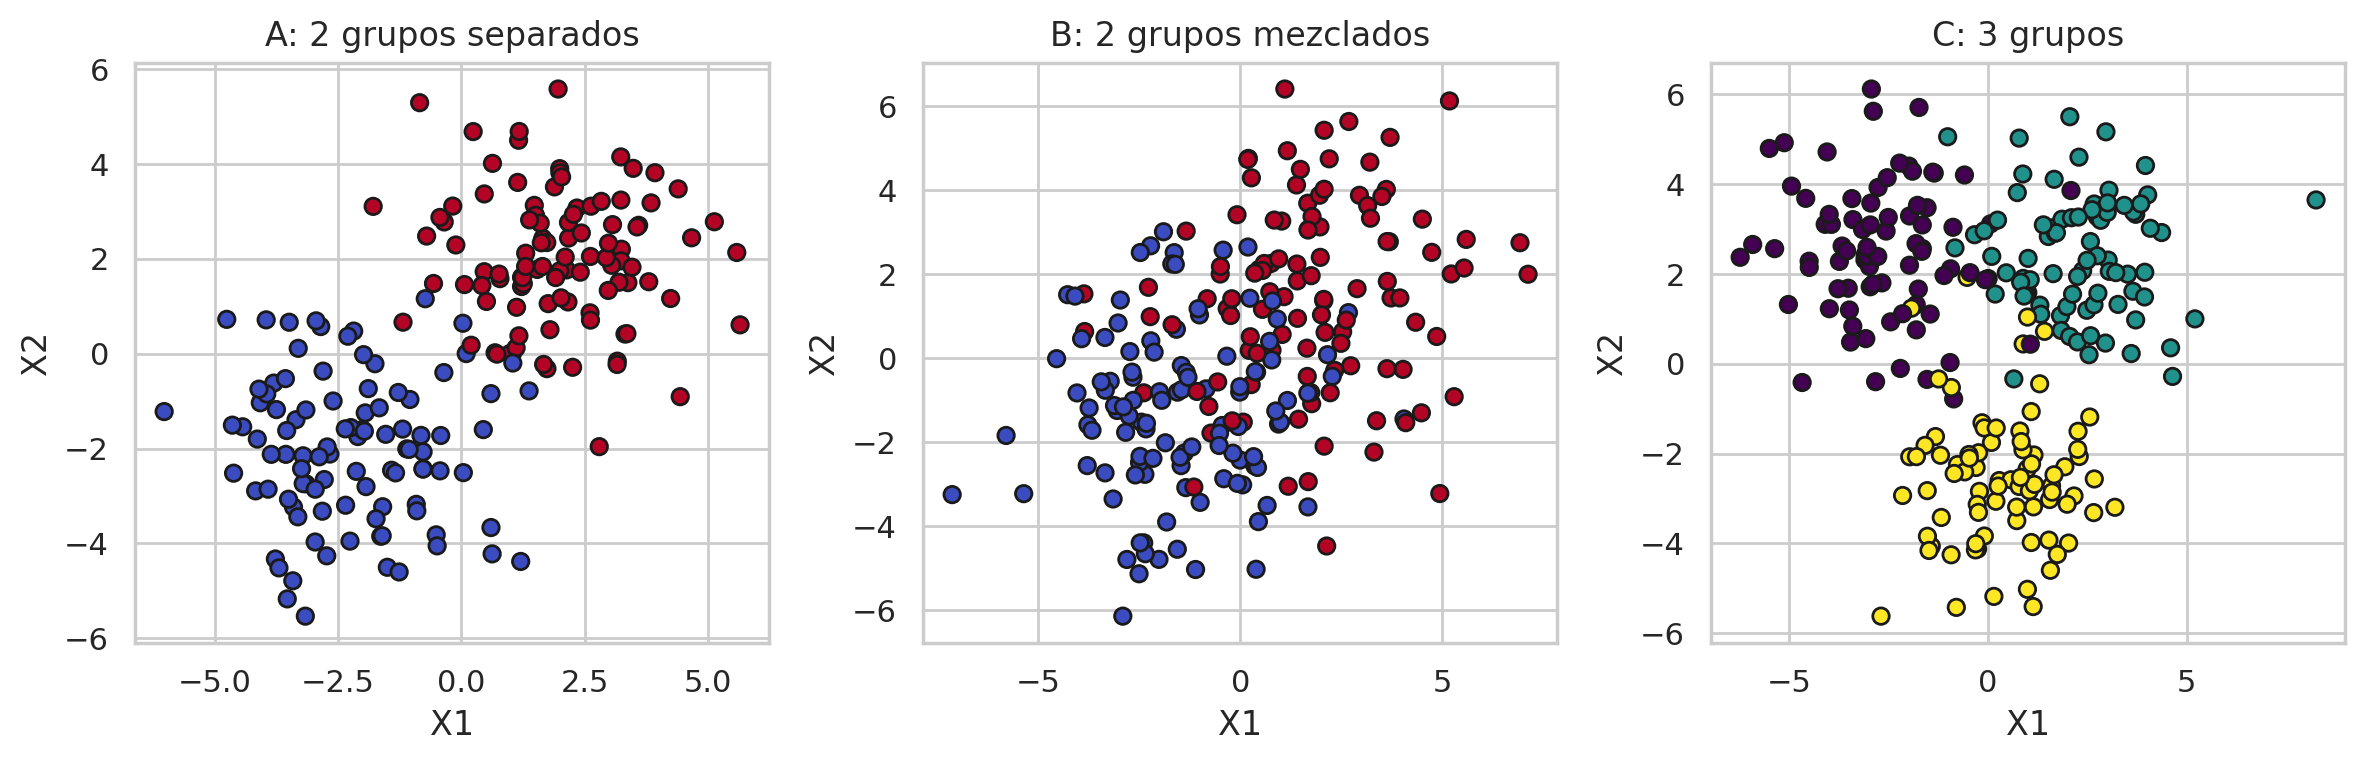

In [3]:
XA, yA = make_blobs(n_samples=200, centers=[[-2.2, -2.2], [2.2, 2.2]], cluster_std=1.5, random_state=0)
XB, yB = make_blobs(n_samples=220, centers=[[-1.3, -1.3], [1.5, 1.5]], cluster_std=2.0, random_state=3)
XC, yC = make_blobs(n_samples=240, centers=[[-2.5, 2.5], [2.5, 2.5], [0, -2.5]], cluster_std=1.4, random_state=2)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, (X, y, t, cm) in zip(ax, [(XA, yA, 'A: 2 grupos separados', 'coolwarm'),
                                 (XB, yB, 'B: 2 grupos mezclados', 'coolwarm'),
                                 (XC, yC, 'C: 3 grupos', 'viridis')]):
    a.scatter(X[:, 0], X[:, 1], c=y, s=35, cmap=cm, edgecolor='k')
    a.set_title(t)
    a.set_xlabel('X1')
    a.set_ylabel('X2')
plt.tight_layout()
plt.show()

## <font color="steelblue">1.1. Terminología</font>

Un árbol de decisión es una serie de **preguntas encadenadas** sobre las variables que va dividiendo los datos en grupos cada vez más homogéneos, hasta emitir una predicción. Su estructura se lee como un **organigrama** (o un árbol genealógico puesto boca abajo: la raíz arriba y las hojas abajo), con estos elementos:

* **Nodo raíz:** el nodo superior, que contiene **todas** las observaciones. Es el punto de partida y aplica la primera regla de división.
* **Nodo de decisión (o interno):** aplica una **regla binaria** sobre una variable —del tipo *"¿$X_j \le t$?"*— y reparte sus observaciones por dos **ramas** hacia dos **nodos hijos**: las que cumplen la condición van a un lado y las que no, al otro.
* **Ramas:** las conexiones que salen de cada nodo de decisión; representan el resultado de la pregunta (**sí** / **no**) y llevan a los nodos hijos.
* **Nodo padre e hijo:** términos relativos. Todo nodo que se divide es el **padre** de los dos nodos que genera, sus **hijos**. Así, un mismo nodo interno es hijo del anterior y padre de los siguientes.
* **Hojas (o nodos terminales):** los nodos del final, que **ya no se dividen** y **emiten la predicción**. En clasificación, esa predicción es la **clase mayoritaria** de las observaciones que caen en la hoja (y la proporción de cada clase da una probabilidad estimada); en regresión, sería la **media** de sus valores.

Un par de conceptos más que usaremos:

* **Profundidad:** el número de divisiones (preguntas) de la rama **más larga**, desde la raíz hasta la hoja más profunda. Es la medida principal de la **complejidad** del árbol: a más profundidad, fronteras más finas... y más riesgo de sobreajuste.
* **Tamaño de un nodo:** cuántas observaciones contiene. Los nodos se van **empequeñeciendo** al descender, y exigir un mínimo de observaciones por hoja es una forma de frenar el crecimiento.
* **Subárbol y poda:** cualquier nodo interno es, a su vez, la raíz de un **subárbol** (él y todo lo que cuelga de él). **Podar** consiste en recortar subárboles poco útiles para simplificar el modelo, algo a lo que volveremos al hablar de regularización.

Para predecir un caso nuevo basta con **recorrer el árbol desde la raíz**, respondiendo en cada nodo a su pregunta y siguiendo la rama correspondiente, hasta llegar a una hoja: su valor es la predicción.



## <font color="steelblue">1.2. La geometría: particiones en rectángulos</font>

Como cada regla es "$X_j \le t$", **cada división es un corte perpendicular a un eje**: el árbol **trocea el espacio en rectángulos** y asigna una clase a cada uno. Su frontera es siempre una **escalera** de tramos horizontales y verticales. Lo vemos en los **tres** juguetes (árbol a la izquierda, regiones a la derecha). Empezamos por el juguete A:

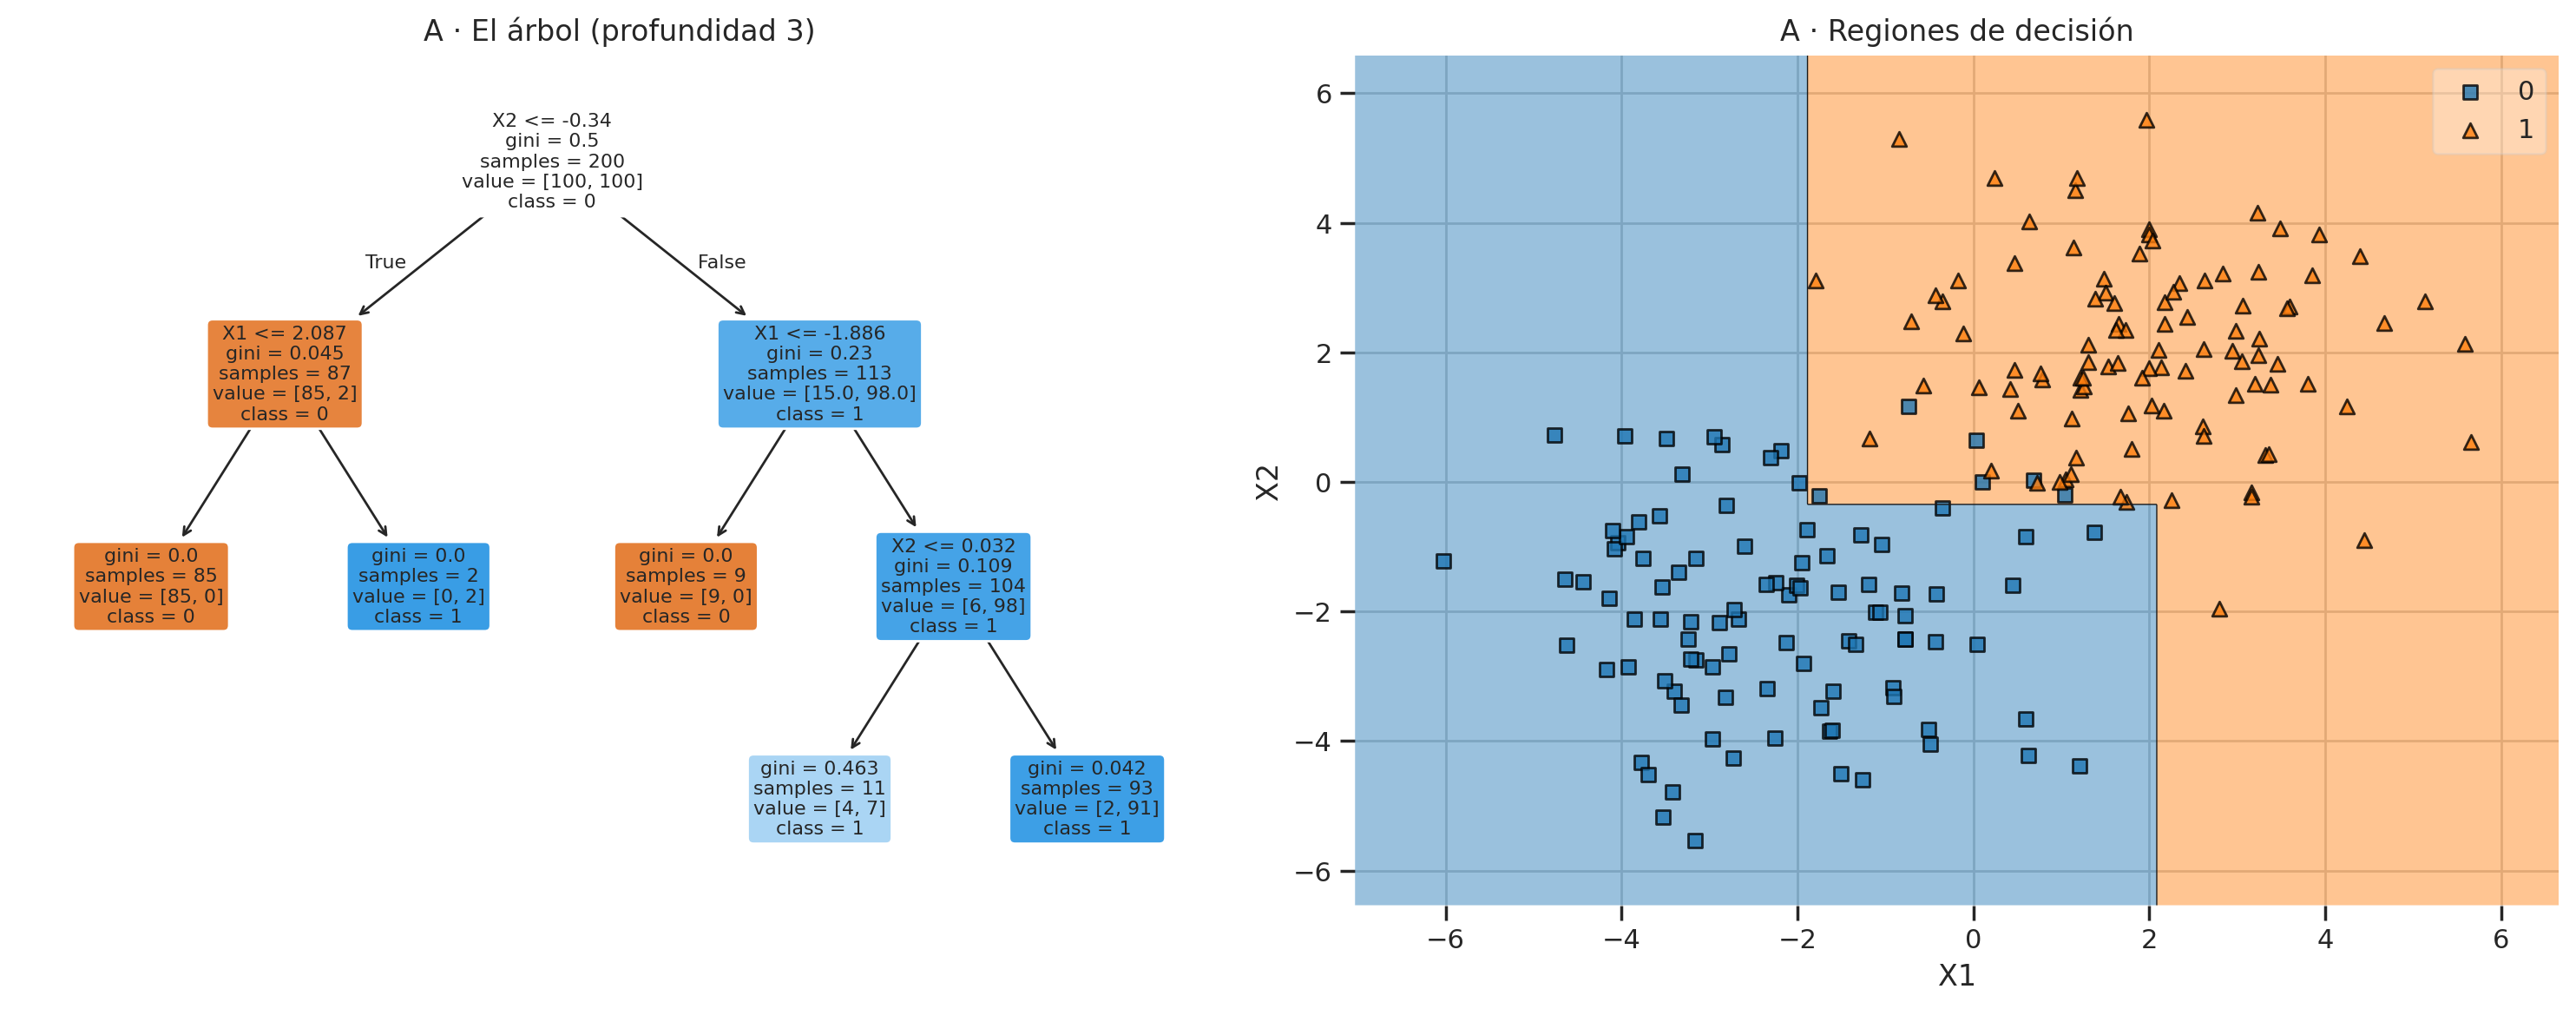

In [6]:
arbolA = DecisionTreeClassifier(max_depth=3, random_state=0).fit(XA, yA)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
plot_tree(arbolA, filled=True, rounded=True, feature_names=['X1', 'X2'], class_names=['0', '1'], ax=ax[0])
ax[0].set_title('A · El árbol (profundidad 3)')
plot_decision_regions(X=XA, y=yA, clf=arbolA, ax=ax[1])
ax[1].set_title('A · Regiones de decisión')
ax[1].set_xlabel('X1')
ax[1].set_ylabel('X2')
plt.tight_layout()
plt.show()

Con el juguete **B** (grupos mezclados), el árbol necesita **más cortes** para separar la zona de solape:

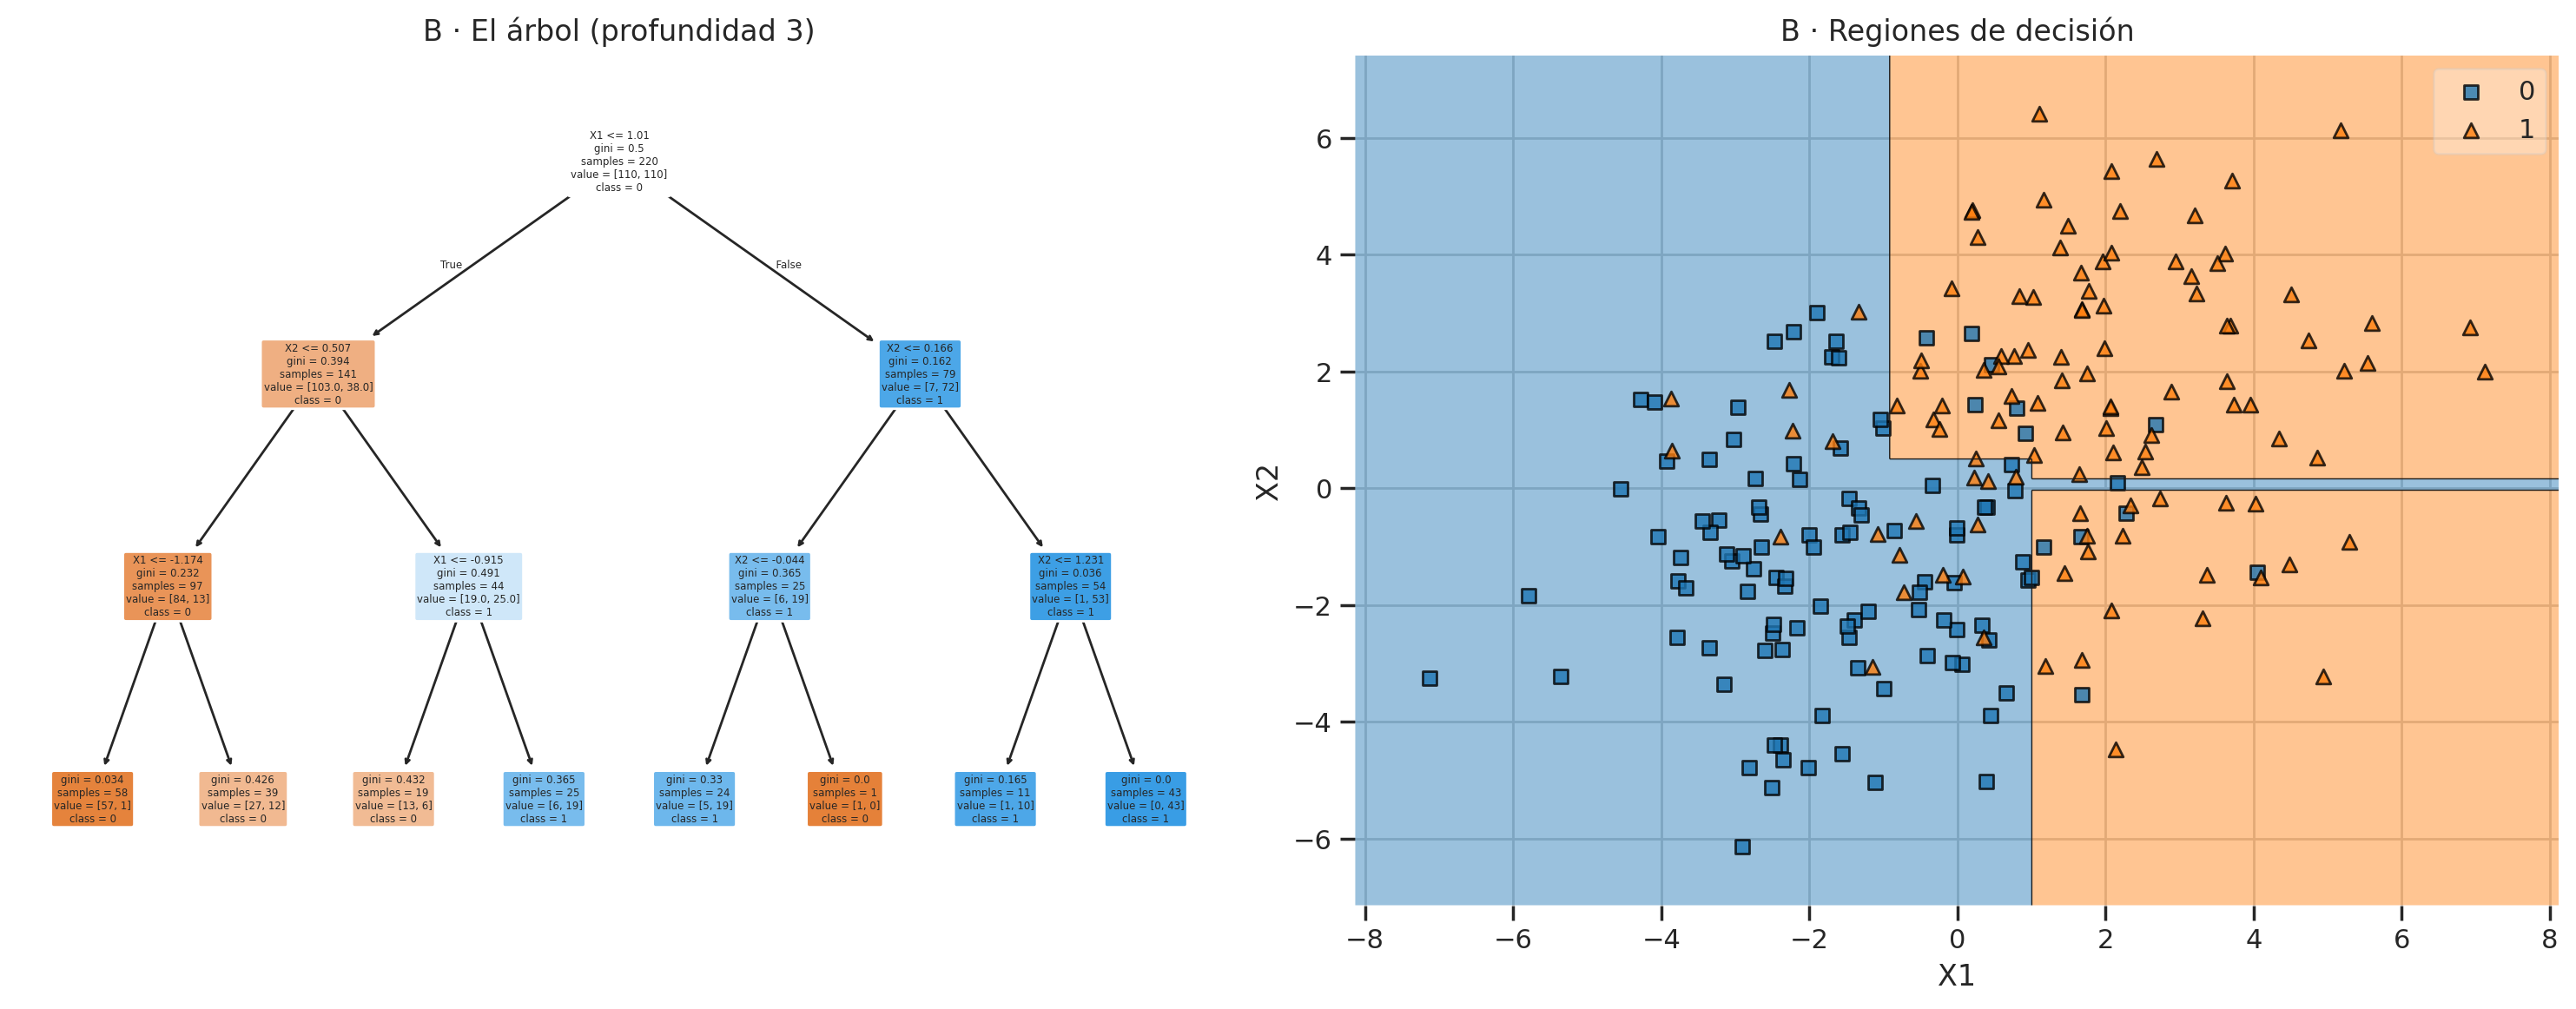

In [7]:
arbolB = DecisionTreeClassifier(max_depth=3, random_state=0).fit(XB, yB)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
plot_tree(arbolB, filled=True, rounded=True, feature_names=['X1', 'X2'], class_names=['0', '1'], ax=ax[0])
ax[0].set_title('B · El árbol (profundidad 3)')
plot_decision_regions(X=XB, y=yB, clf=arbolB, ax=ax[1])
ax[1].set_title('B · Regiones de decisión')
ax[1].set_xlabel('X1')
ax[1].set_ylabel('X2')
plt.tight_layout()
plt.show()

Y con el juguete **C** (tres grupos), las hojas predicen **tres etiquetas** distintas; las regiones siguen siendo rectangulares:

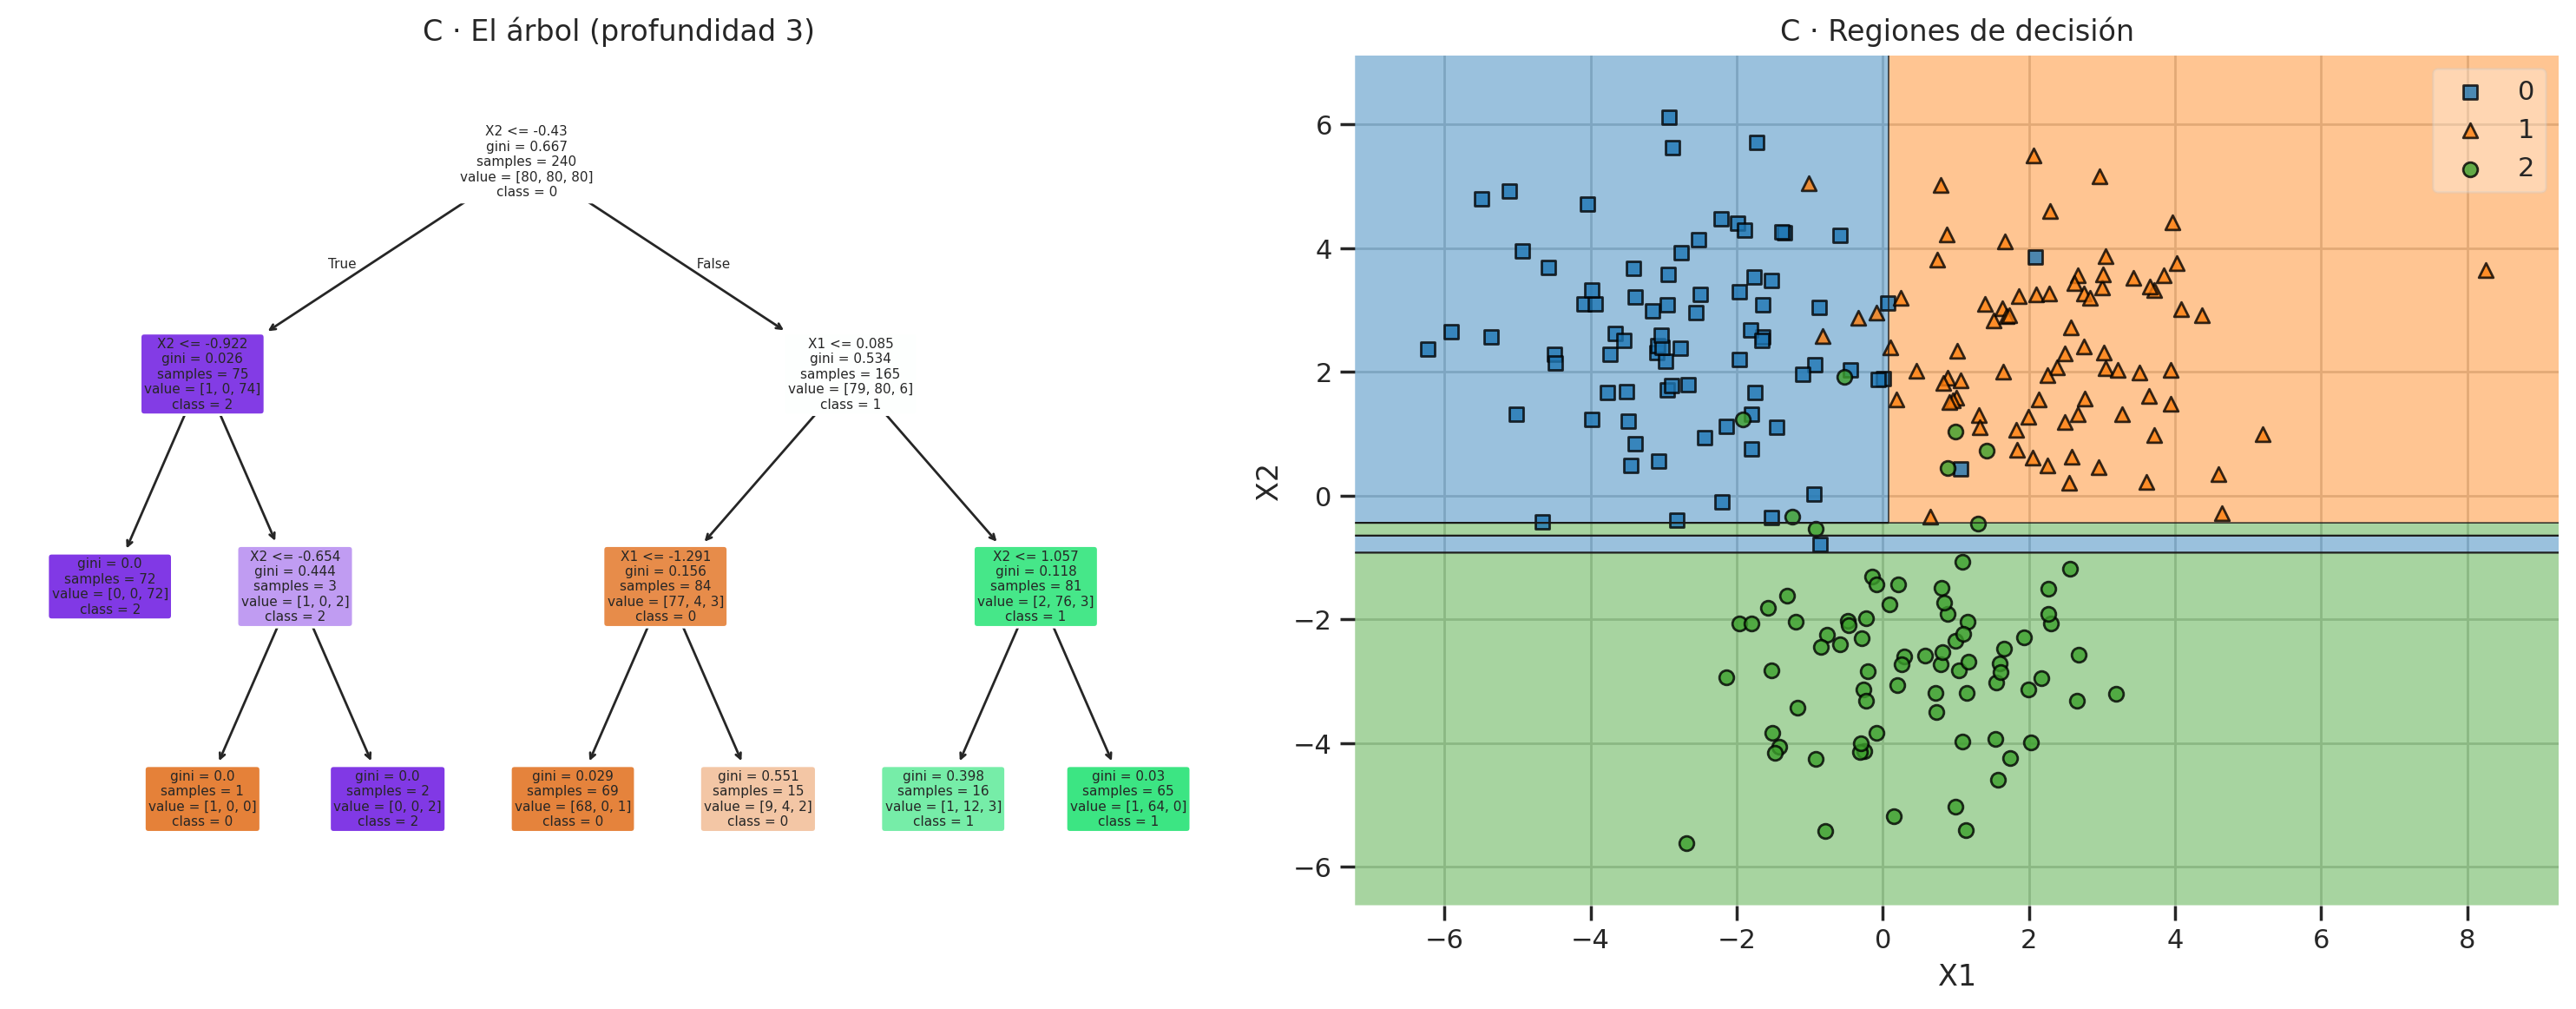

In [8]:
arbolC = DecisionTreeClassifier(max_depth=3, random_state=0).fit(XC, yC)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
plot_tree(arbolC, filled=True, rounded=True, feature_names=['X1', 'X2'], class_names=['0', '1', '2'], ax=ax[0])
ax[0].set_title('C · El árbol (profundidad 3)')
plot_decision_regions(X=XC, y=yC, clf=arbolC, ax=ax[1])
ax[1].set_title('C · Regiones de decisión')
ax[1].set_xlabel('X1')
ax[1].set_ylabel('X2')
plt.tight_layout()
plt.show()

En los tres casos las fronteras son siempre **horizontales o verticales** —la huella geométrica de los árboles— y cada hoja se corresponde con un **rectángulo** del plano. Cuanto más se mezclan los grupos (B) o más clases hay (C), **más cortes** necesita el árbol, lo que ya anticipa el riesgo de complejidad excesiva que trataremos en la sección 4.

> **Alternativa de visualización más legible: Graphviz.** `plot_tree` es cómodo, pero cuando el árbol crece la **letra se vuelve diminuta** y las ramas se amontonan. Una alternativa mucho más clara es exportar el árbol con **`export_graphviz`** y representarlo con **`graphviz.Source`**: produce diagramas nítidos, con cajas redondeadas **coloreadas por clase**, el reparto de cada nodo y texto que **no se encoge** aunque el árbol sea grande (en Colab puedes ampliar la imagen). Definimos un pequeño ayudante reutilizable y lo probamos con el árbol del juguete A:

In [9]:
# Función para representar el árbol de decisión
def arbol_graphviz(modelo, nombres, clases):
    dot = export_graphviz(modelo, feature_names=list(nombres), class_names=list(clases),
                          filled=True, rounded=True, special_characters=True)
    return graphviz.Source(dot)

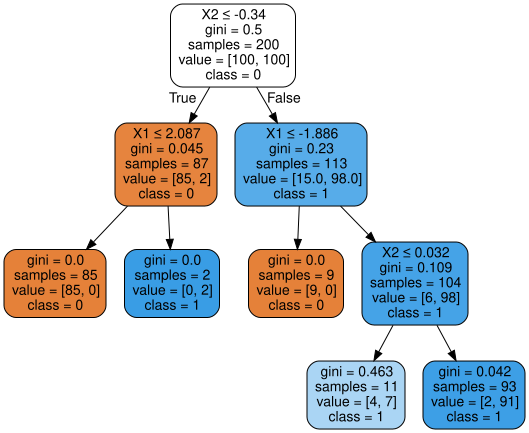

In [10]:
# Banco de datos A
arbol_graphviz(arbolA, ['X1', 'X2'], ['0', '1'])

Compáralo con el `plot_tree` de antes: las mismas reglas, pero **mucho más legibles**. Usaremos `arbol_graphviz` para los árboles más grandes del cuaderno. *(Para una visualización aún más rica —con la distribución de clases dibujada en cada nodo— existe la librería `dtreeviz`, opcional.)*

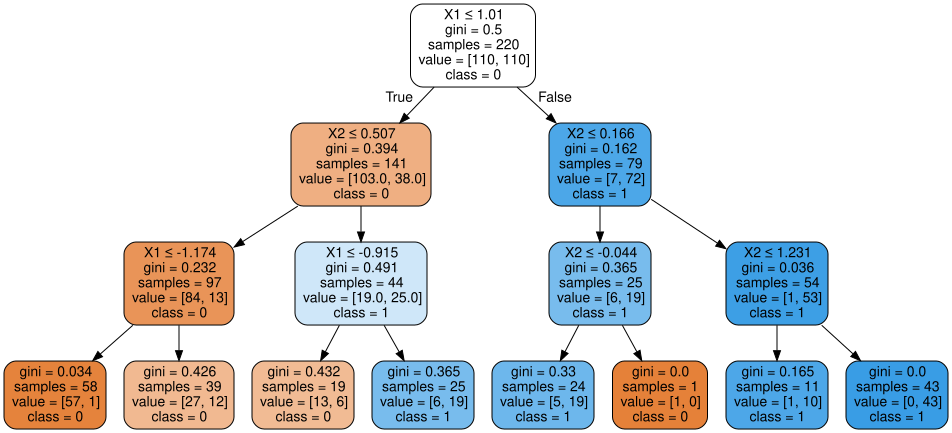

In [14]:
arbol_graphviz(arbolB, ['X1', 'X2'], ['0', '1'])

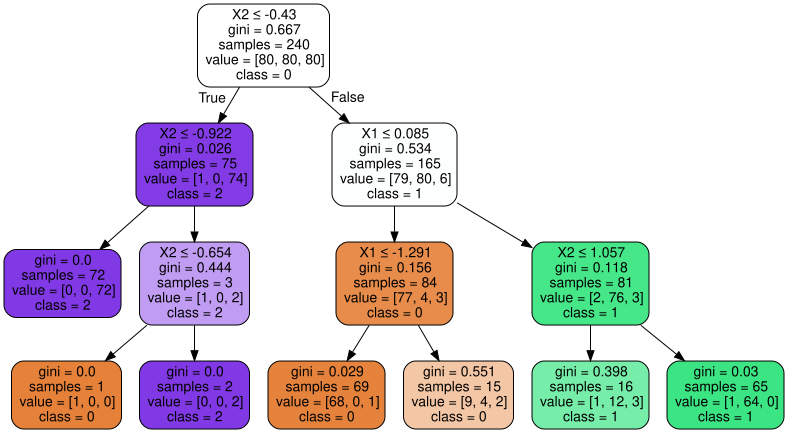

In [15]:
arbol_graphviz(arbolC, ['X1', 'X2'], ['0', '1', '2'])

# <font color="steelblue">2. Construcción del árbol: cómo se elige cada división</font>

## <font color="steelblue">2.1. Medidas de impureza</font>

El árbol crece **de forma voraz**: en cada nodo prueba todas las divisiones posibles ("¿$X_j \le t$?") y se queda con la que produce nodos hijos lo más **puros** posible (que dentro de cada uno domine una sola clase). Pero para elegir la mejor división primero hay que **medir** esa pureza con un número. Para eso están las **medidas de impureza**, que cuantifican cuán mezcladas están las clases en un nodo $m$ a partir de sus proporciones de clase $\hat p_{mk}$: valen **0 cuando el nodo es puro** (una sola clase) y **crecen con la mezcla** (máximas cuando las clases están equilibradas).

La lógica de cada división es, entonces, comparar la impureza del **padre** con la de sus **hijos**: se elige el corte que produce la mayor **reducción de impureza** (impureza del padre menos la media ponderada de la de los hijos). Las medidas más habituales son:

* **Entropía:** $H_m = -\sum_{k}\hat p_{mk}\log_2\hat p_{mk}$. Procede de la teoría de la información: mide los *bits* de incertidumbre del nodo —cuánta «sorpresa» hay al sacar una observación al azar—. Es **0** si todas las observaciones son de una clase y **máxima** (1 bit, en el caso binario) cuando están al 50/50. La reducción de entropía al dividir se llama **ganancia de información** y es el criterio de los algoritmos C4.5/C5.0.
* **Índice de Gini:** $G_m = \sum_{k}\hat p_{mk}(1-\hat p_{mk}) = 1-\sum_k \hat p_{mk}^2$. Es la **probabilidad de equivocarse** si etiquetáramos una observación al azar según las proporciones del nodo. Muy barato de calcular (sin logaritmos) y **muy parecido** a la entropía en la práctica; es el criterio de **CART**, el que usa scikit-learn por defecto.
* **Error de clasificación:** $E_m = 1-\max_k\hat p_{mk}$. La fracción de observaciones que no son de la clase mayoritaria. Es el más intuitivo, pero **poco sensible**: solo cambia cuando cambia la clase mayoritaria, así que ignora mejoras en las proporciones que no alteran quién manda. Por eso se reserva para **podar o evaluar**, no para hacer crecer el árbol.
* **Ji-cuadrado ($\chi^2$):** en lugar de medir impureza, **contrasta** si la distribución de clases de los hijos difiere **significativamente** de la del padre; si la diferencia no es estadísticamente relevante, no merece la pena dividir (criterio CHAID).

### <font color="steelblue">¿Cuál usar?</font>

**Gini y entropía dan árboles casi idénticos**; la diferencia práctica es menor y la elección rara vez cambia el resultado. Gini es algo **más rápido** (no calcula logaritmos), por lo que es el **valor por defecto** de scikit-learn (`criterion='gini'`, con `'entropy'`/`'log_loss'` como alternativa). El **error de clasificación**, en cambio, no se usa para construir porque su insensibilidad puede **frenar divisiones útiles**: dos cortes distintos pueden dar el mismo error aunque uno deje los nodos mucho más «encaminados» hacia la pureza, algo que Gini y la entropía **sí** detectan.

Para fijar ideas, calculamos las tres primeras en nodos binarios concretos (clase A frente a clase B):

In [16]:
ejemplos = [(8, 2), (5, 5), (9, 1), (10, 0)]
filas = []
for na, nb in ejemplos:
    n = na + nb; p = na / n
    H = 0.0 if p in (0, 1) else -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    filas.append({'nodo [A,B]': f'[{na},{nb}]', 'p(A)': round(p, 2),
                  'Gini': round(1 - (p**2 + (1 - p)**2), 3), 'Entropía': round(H, 3),
                  'Error': round(1 - max(p, 1 - p), 3)})
print(pd.DataFrame(filas).to_string(index=False))

nodo [A,B]  p(A)  Gini  Entropía  Error
     [8,2]   0.8  0.32     0.722    0.2
     [5,5]   0.5  0.50     1.000    0.5
     [9,1]   0.9  0.18     0.469    0.1
    [10,0]   1.0  0.00     0.000    0.0


Vemos que el nodo equilibrado `[5,5]` es el **más impuro** con las tres medidas (Gini 0.5, entropía 1, error 0.5), mientras que el nodo puro `[10,0]` da **0** en todas. Representamos las tres como función de la proporción $p$ de la clase 1:

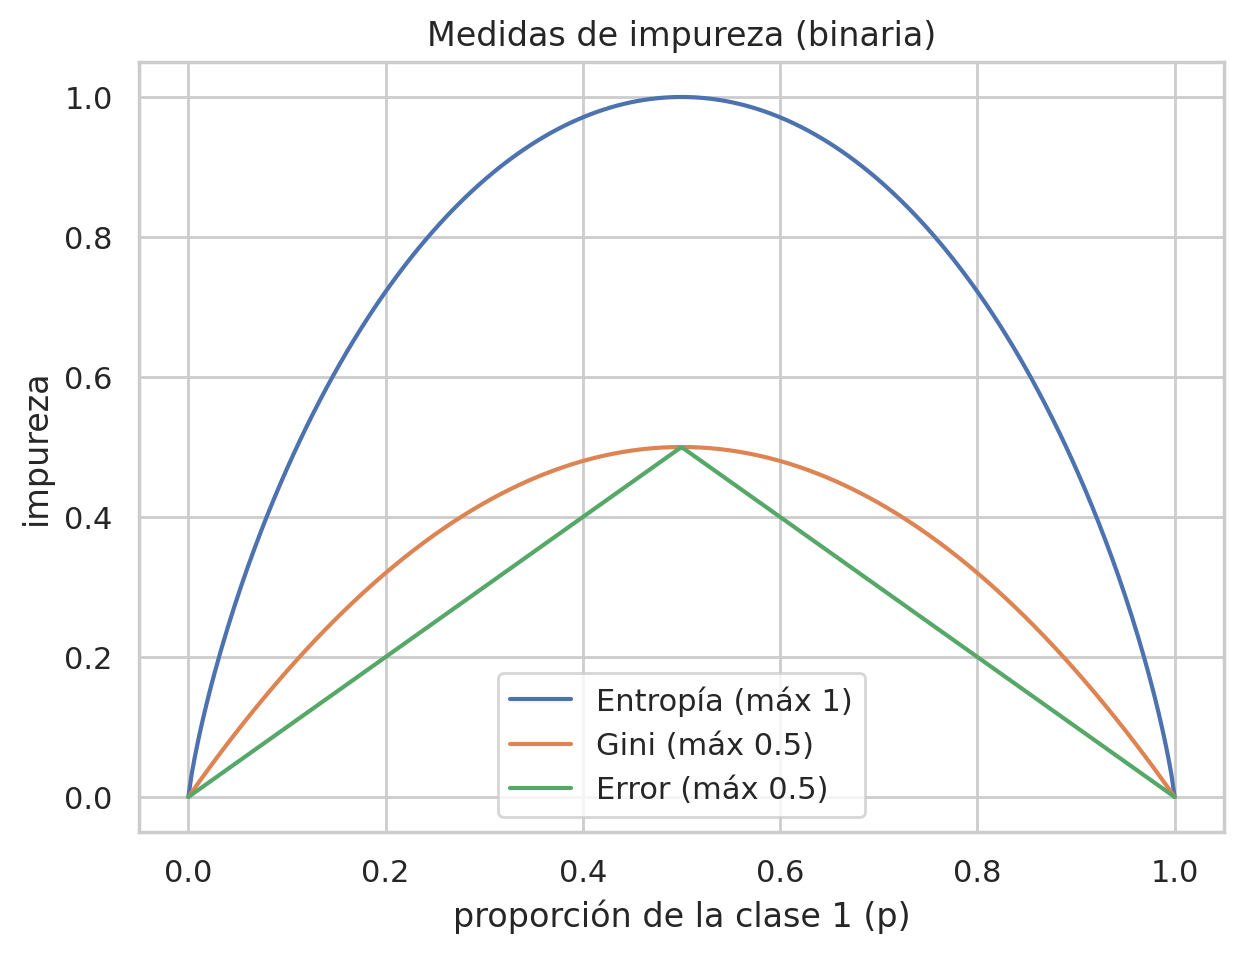

In [17]:
p = np.linspace(1e-6, 1 - 1e-6, 300)
gini_b = 2 * p * (1 - p); ent = -(p * np.log2(p) + (1 - p) * np.log2(1 - p)); err = 1 - np.maximum(p, 1 - p)
plt.figure(figsize=(7, 5))
plt.plot(p, ent, label='Entropía (máx 1)')
plt.plot(p, gini_b, label='Gini (máx 0.5)')
plt.plot(p, err, label='Error (máx 0.5)')
plt.xlabel('proporción de la clase 1 (p)')
plt.ylabel('impureza')
plt.title('Medidas de impureza (binaria)')
plt.legend()
plt.show()

Las tres curvas comparten la idea esencial —valen **0 en los extremos** ($p=0$ o $p=1$, nodo puro) y son **máximas en el centro** ($p=0.5$, máxima mezcla)— pero se comportan distinto:

* **Entropía y Gini son curvas suaves y cóncavas.** Esa concavidad es clave: significa que **cualquier** división que aleje un hijo del 50/50 reduce la impureza media, aunque no llegue a cambiar la clase mayoritaria. Por eso "premian" mejoras parciales de pureza y generan buenos árboles. Tienen casi la misma forma (la entropía es algo más "puntiaguda" en el centro); la elección entre ambas rara vez cambia mucho el resultado.
* **El error de clasificación es lineal a trozos**, con un pico anguloso en 0.5. Al ser recto, una división que pase de `[6,4]` a dos hijos `[6,3]` y `[0,1]` puede **no cambiar** su valor (la clase mayoritaria sigue siendo la misma), de modo que el algoritmo "no ve" la mejora. Esa insensibilidad es la razón de que **no se use para construir** el árbol, solo para evaluarlo.

## <font color="steelblue">2.2. El algoritmo CART al completo</font>

scikit-learn implementa **CART** (*Classification And Regression Trees*), que construye el árbol **de arriba abajo**, dividiendo cada nodo en dos y repitiendo el proceso de forma recursiva. Su funcionamiento, paso a paso:

1. **Inicio.** Todas las observaciones de entrenamiento se colocan en el **nodo raíz**.
2. **Búsqueda de la mejor división.** Para el nodo actual se consideran **todas** las divisiones binarias candidatas: para cada variable $k$ y cada **umbral** $t_k$ (los puntos medios entre valores consecutivos ordenados de esa variable), se parte el nodo en dos hijos $A=\{X_k\le t_k\}$ y $B=\{X_k> t_k\}$ y se calcula la **impureza ponderada por tamaño**:
$$J(k, t_k) = \frac{n_A}{n}\,G_A + \frac{n_B}{n}\,G_B,$$
donde $G$ es el índice de Gini y $n=n_A+n_B$. La ponderación por $n_A/n$ y $n_B/n$ es esencial: no purifica igual separar 2 observaciones que 100, así que cada hijo pesa en proporción a las observaciones que recibe.
3. **Selección.** Se elige el par $(k, t_k)$ que **minimiza** $J$ (equivalentemente, el que **maximiza el descenso de impureza** respecto al nodo padre). Esa es la regla de decisión de ese nodo.
4. **Partición y recursión.** Se crean los dos nodos hijos con sus observaciones y se **repite** el proceso (pasos 2–3) en **cada** hijo de forma independiente. Cada rama sigue creciendo por su cuenta.
5. **Condiciones de parada.** Un nodo deja de dividirse y se convierte en **hoja** cuando se cumple alguna de estas condiciones: (a) el nodo es **puro** (una sola clase); (b) **ninguna** división disminuye la impureza; o (c) se alcanza algún **límite** impuesto por el usuario (`max_depth`, `min_samples_split`, `min_samples_leaf`, `min_impurity_decrease`…).
6. **Predicción en las hojas.** Cada hoja almacena el reparto de clases de sus observaciones: predice la **clase mayoritaria** y usa esas proporciones como **probabilidades** estimadas.

**Detalles importantes:**

* **Solo divisiones binarias.** CART parte cada nodo en exactamente **dos** hijos; una misma variable **puede reutilizarse** en varios niveles (con umbrales distintos), lo que permite modelar relaciones no lineales por tramos.
* **Es voraz (*greedy*).** En cada nodo toma la mejor división **local**, sin anticipar cómo condicionará las siguientes. No garantiza el árbol globalmente óptimo —hallarlo es un problema **NP-completo**—, pero en la práctica da muy buenos resultados con un coste razonable (aproximadamente $O(n_{\text{features}}\cdot n\log n)$ por nivel). Una consecuencia práctica es que el árbol puede ser **inestable**: un pequeño cambio en los datos altera una división alta y **arrastra** todo lo que cuelga de ella (algo que los *bosques* de la sección siguiente mitigan).
* **Variables numéricas.** CART trabaja directamente con variables **numéricas** (busca umbrales); las **categóricas** deben codificarse previamente en scikit-learn (por ejemplo, con *one-hot*).

Hacemos explícito el paso 2 sobre el juguete **B**: para cada variable recorremos los umbrales y calculamos $J$; el mínimo marca el corte.

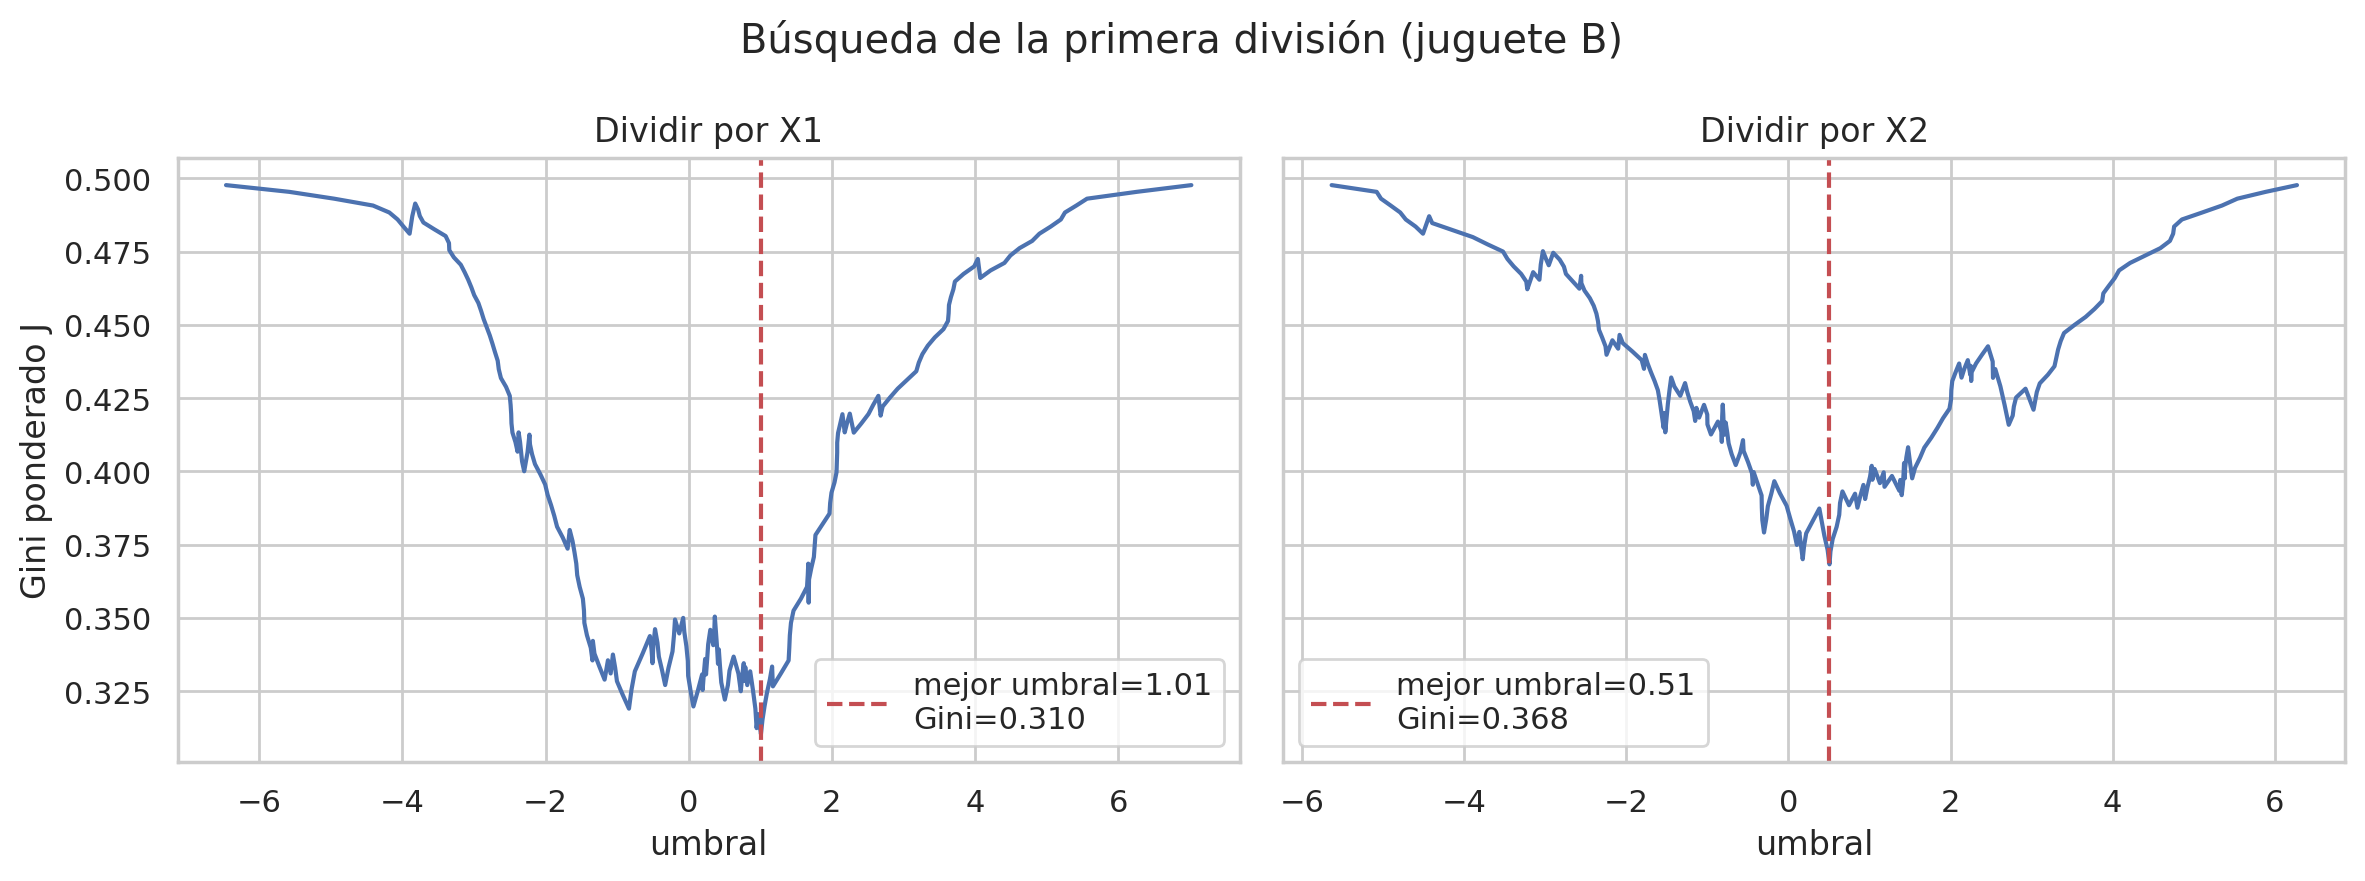

Mejor primera división: X1 <= 1.010  (Gini ponderado = 0.310)


In [19]:
# Funciones para evaluar divisiones
def gini(y):
    if len(y) == 0: return 0.0
    _, c = np.unique(y, return_counts=True); pr = c / len(y); return 1 - np.sum(pr**2)
def gini_ponderado(X, y, f, t):
    L = X[:, f] <= t; return L.mean() * gini(y[L]) + (~L).mean() * gini(y[~L])
def escanear(X, y, f):
    v = np.unique(X[:, f]); thr = (v[:-1] + v[1:]) / 2
    return thr, np.array([gini_ponderado(X, y, f, t) for t in thr])

# Gráfico de evolución de las impurezas (Gini) para X1 y X2
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True); mejor = (1e9, None, None)
for a, f, nm in zip(ax, [0, 1], ['X1', 'X2']):
    thr, g = escanear(XB, yB, f); i = g.argmin()
    a.plot(thr, g); a.axvline(thr[i], ls='--', color='r', label=f'mejor umbral={thr[i]:.2f}\nGini={g[i]:.3f}')
    a.set_title(f'Dividir por {nm}')
    a.set_xlabel('umbral')
    a.legend()
    if g[i] < mejor[0]: mejor = (g[i], nm, thr[i])
ax[0].set_ylabel('Gini ponderado J')
plt.suptitle('Búsqueda de la primera división (juguete B)'); plt.tight_layout()
plt.show()
print(f'Mejor primera división: {mejor[1]} <= {mejor[2]:.3f}  (Gini ponderado = {mejor[0]:.3f})')

Cada curva tiene un **mínimo claro** en su mejor umbral; CART elige el corte global de menor $J$, que en este caso corresponde con $X1$ en el valor 1.010. Dibujamos la región de decisión y proporcionamos los valores de impureza de cada rama del árbol para dicho valor de corte:

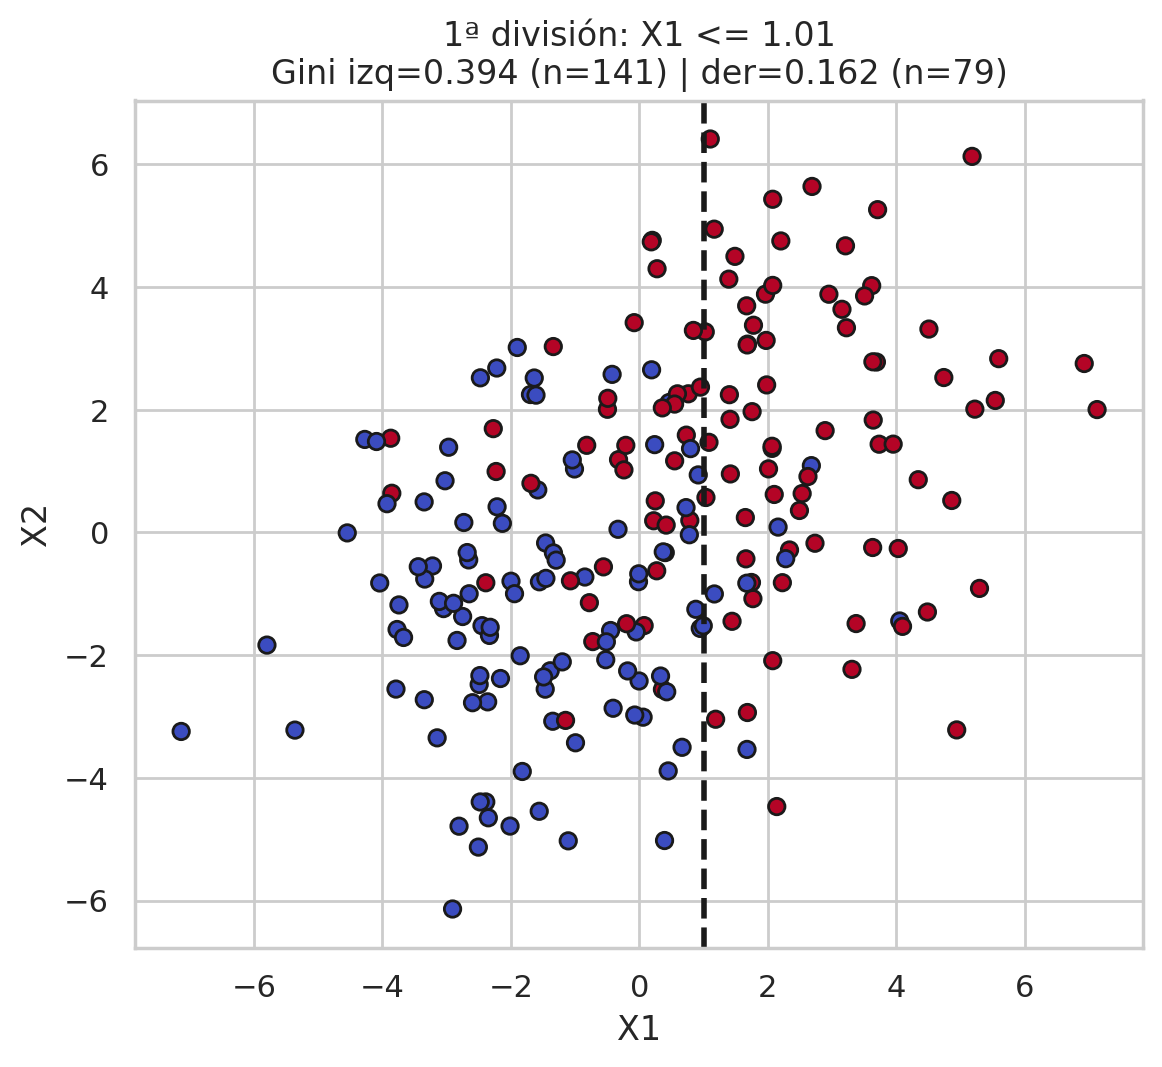

In [20]:
f0 = 0 if mejor[1] == 'X1' else 1; t0 = mejor[2]; L = XB[:, f0] <= t0
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(XB[:, 0], XB[:, 1], c=yB, s=35, cmap='coolwarm', edgecolor='k')
(ax.axvline if f0 == 0 else ax.axhline)(t0, color='k', lw=2, ls='--')
ax.set_title(f'1ª división: {mejor[1]} <= {t0:.2f}\nGini izq={gini(yB[L]):.3f} (n={L.sum()}) | der={gini(yB[~L]):.3f} (n={(~L).sum()})')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
plt.show()

## <font color="steelblue">2.3. Las divisiones sucesivas hasta la clasificación final</font>

El proceso se repite en cada hijo. Vemos cómo se **acumulan los cortes** (juguete B), gráficamente (las regiones se subdividen) y numéricamente (impureza total baja, exactitud sube):

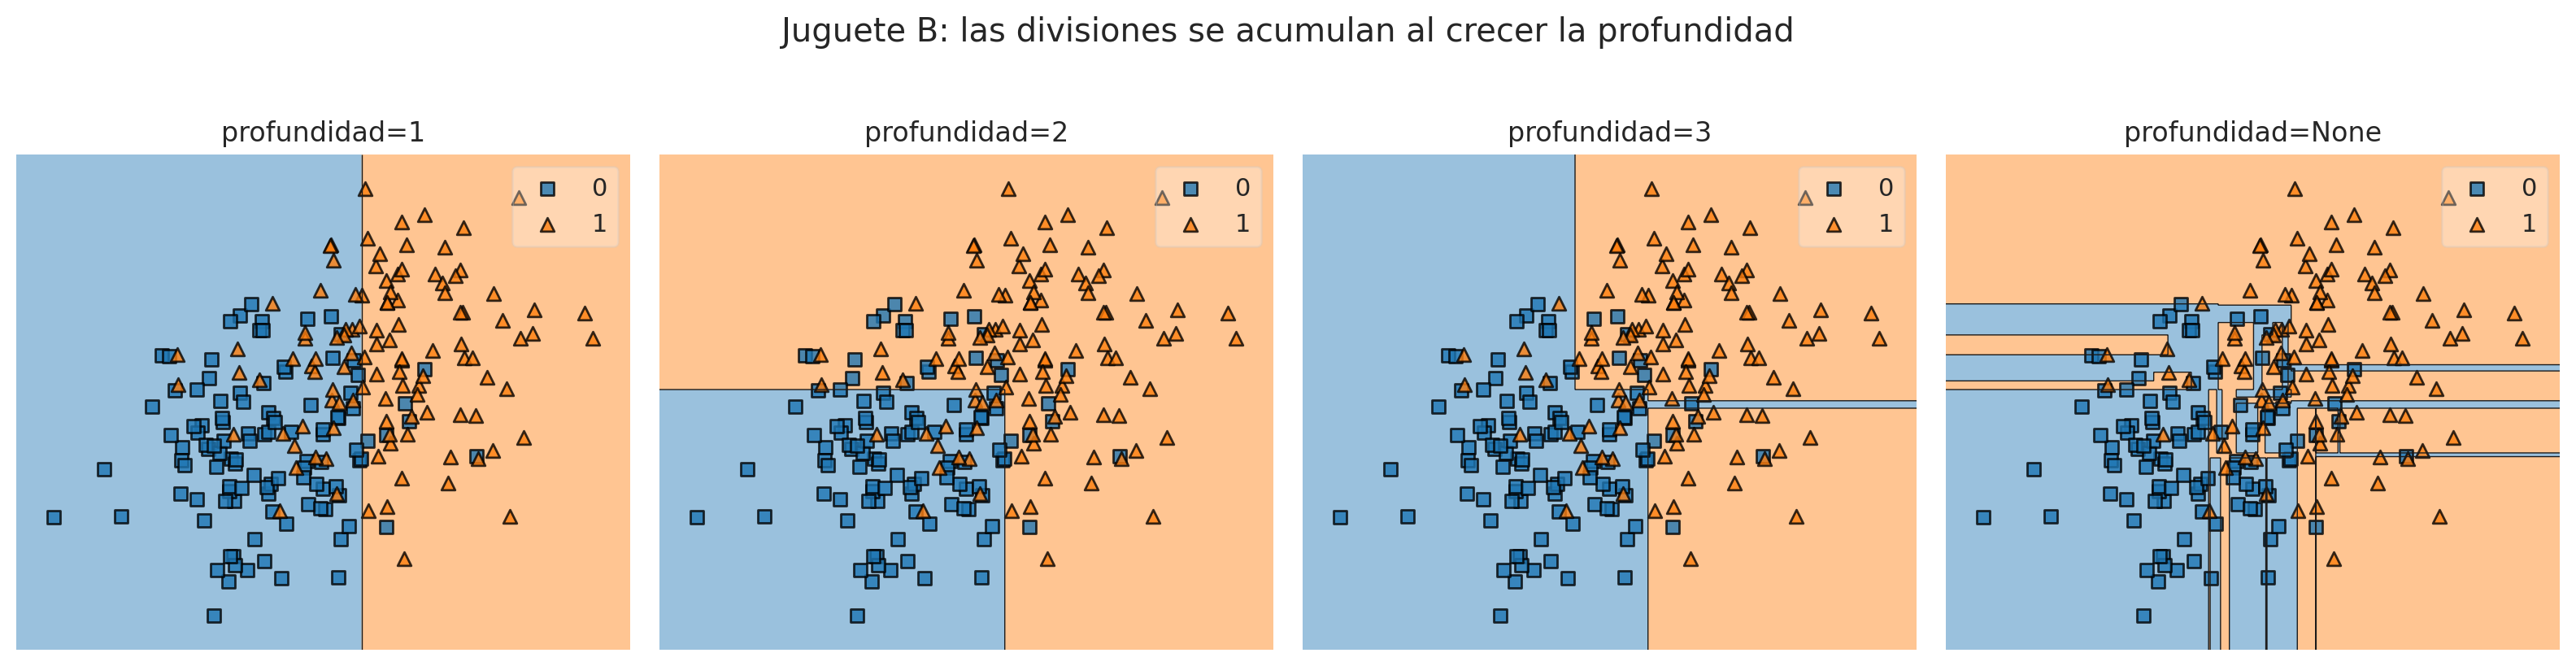

profundidad  nº hojas  impureza total  exactitud train
          1         2           0.310            0.795
          2         4           0.251            0.823
          3         8           0.207            0.859
       None        48           0.000            1.000


In [22]:
# Función para evaluar la impureza de forma sucesiva
def impureza_total(m, X, y):
    hojas = m.apply(X); return sum(len(y[hojas == h]) / len(y) * gini(y[hojas == h]) for h in np.unique(hojas))
# Gráfico de la solución obtenida
fig, ax = plt.subplots(1, 4, figsize=(16, 4)); filas = []
for a, d in zip(ax, [1, 2, 3, None]):
    m = DecisionTreeClassifier(max_depth=d, random_state=0).fit(XB, yB)
    plot_decision_regions(X=XB, y=yB, clf=m, ax=a)
    a.set_title(f'profundidad={d}')
    a.set_xticks([])
    a.set_yticks([])
    filas.append({'profundidad': str(d), 'nº hojas': m.get_n_leaves(),
                  'impureza total': round(impureza_total(m, XB, yB), 3), 'exactitud train': round(m.score(XB, yB), 3)})
plt.suptitle('Juguete B: las divisiones se acumulan al crecer la profundidad', y=1.02)
plt.tight_layout()
plt.show()
print(pd.DataFrame(filas).to_string(index=False))

A cada nivel los rectángulos se **subdividen**: la **impureza total baja** y la exactitud de train sube hacia 1. Pero los últimos cortes ya solo aíslan **puntos sueltos** dentro de la zona de mezcla: **sobreajuste** incipiente.

## <font color="steelblue">2.4. La importancia de las variables, vista en el juguete</font>

¿Cómo decide un árbol **qué variables importan**? La idea es sencilla: una variable es importante si, cuando el árbol la usa para dividir, **consigue nodos mucho más puros**. Cada vez que una variable se usa en una división, **reduce impureza**; la **importancia** de una variable es la suma de esas reducciones (ponderadas por el tamaño del nodo), normalizada. Formalmente, para la variable $j$:

$$\text{Imp}(j) = \frac{1}{N}\sum_{t:\,\text{divide por }j} \big[\,N_t\,G_t - N_{t_L}G_{t_L} - N_{t_R}G_{t_R}\,\big], \qquad \text{(luego se normaliza para que sumen 1)}$$

donde $N_t$ son las muestras del nodo $t$ y $G$ su Gini.

Leída con calma, la fórmula solo dice tres cosas:

* El corchete es el **descenso de impureza** de una división: la impureza del nodo padre menos la de sus dos hijos (izquierdo $t_L$ y derecho $t_R$).
* La ponderación por $N_t$ hace que las divisiones **cerca de la raíz** (que afectan a muchas observaciones) **pesen más** que las de nodos pequeños y profundos.
* Se **suma** sobre todos los nodos donde aparece la variable $j$ (una misma variable puede usarse varias veces) y al final se **normaliza** para que las importancias de todas las variables **sumen 1**, así se leen como porcentajes.

Es lo que scikit-learn devuelve en `modelo.feature_importances_`. Una variable con importancia **0** no significa que sea inútil, sino que **este árbol no la ha usado** (quizá otra variable correlacionada «se le adelantó» en las divisiones).

> **Dos cautelas importantes.** Esta importancia por impureza (*Gini importance*) es cómoda y rápida, pero tiene dos sesgos conocidos: (1) **favorece a las variables con muchos valores distintos** (numéricas continuas o categóricas de alta cardinalidad), que ofrecen más umbrales donde «encontrar» una buena división aunque sea por azar; y (2) **reparte de forma arbitraria** la importancia entre variables **correlacionadas** (le da casi todo a una y casi nada a la otra, según cuál eligió primero). Además, se calcula sobre el **entrenamiento**, así que puede premiar sobreajuste. Cuando la interpretación es crítica, conviene contrastarla con la **importancia por permutación** (`permutation_importance`, mide cuánto empeora el modelo al «romper» una variable, y se calcula sobre datos de test) o con los **valores SHAP**.

Con solo **dos** predictoras el cálculo es casi trivial, ideal para **ver cómo se obtiene**. Lo reproducimos a mano sobre el juguete B (profundidad 2) y lo comparamos con scikit-learn:

In [24]:
arbolB2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(XB, yB)
t = arbolB2.tree_; N = t.weighted_n_node_samples[0]
imp_manual = np.zeros(2)
for nodo in range(t.node_count):
    if t.feature[nodo] != -2:
        izq, der = t.children_left[nodo], t.children_right[nodo]
        descenso = (t.weighted_n_node_samples[nodo] * t.impurity[nodo]
                    - t.weighted_n_node_samples[izq] * t.impurity[izq]
                    - t.weighted_n_node_samples[der] * t.impurity[der]) / N
        imp_manual[t.feature[nodo]] += descenso
        print(f'nodo {nodo}: divide por X{t.feature[nodo]+1}, desciende impureza en {descenso:.4f}')
imp_manual = imp_manual / imp_manual.sum()
print('\nImportancia manual :', np.round(imp_manual, 4))
print('feature_importances_:', np.round(arbolB2.feature_importances_, 4))

nodo 0: divide por X1, desciende impureza en 0.1896
nodo 1: divide por X2, desciende impureza en 0.0519
nodo 4: divide por X2, desciende impureza en 0.0076

Importancia manual : [0.7612 0.2388]
feature_importances_: [0.7612 0.2388]


Los dos cálculos **coinciden**, y esa coincidencia es justo lo que buscábamos: confirma que la importancia que devuelve scikit-learn **no es una caja negra**. Detrás del número hay una cuenta transparente que ya sabemos reproducir: para cada variable, se **suman los descensos de impureza** de todas las divisiones en las que participa, cada uno **ponderado por el tamaño** del nodo, y al final se **normaliza** para que las importancias sumen 1 (se lean como porcentajes). En una palabra: **una variable es importante si, allí donde el árbol la usa, consigue separar bien las clases**.

Esta misma idea escala directamente a problemas con **muchas variables**: en lugar de calcularla a mano, leeremos `feature_importances_`, **ordenaremos** las predictoras de mayor a menor aportación y nos quedaremos con las más relevantes. Así, la importancia deja de ser solo una herramienta para *interpretar* el árbol y se convierte en un criterio para **seleccionar predictoras** en los datos reales, como haremos a continuación.

# <font color="steelblue">3. Predicción: el recorrido de una observación nueva</font>

Para clasificar una observación, se la deja **caer por el árbol**: en cada nodo se evalúa su regla y se baja por la rama correspondiente hasta una **hoja**, que da la clase y la **probabilidad**. Lo ilustramos en los **tres** juguetes con observaciones nuevas, siguiendo el recorrido **regla a regla**. Definimos una función auxiliar para establecer la "caida" por el árbol establecido:

In [25]:
def predecir_traza(arbol, puntos, X, y, titulo):
    t = arbol.tree_; feat = t.feature; thr = t.threshold; dp = arbol.decision_path(puntos)
    for i, x in enumerate(puntos):
        nodos = dp.indices[dp.indptr[i]:dp.indptr[i + 1]]
        print(f'\n— Observación {i+1}: (X1={x[0]:.2f}, X2={x[1]:.2f}) —')
        for nodo in nodos:
            if feat[nodo] != -2:
                var = 'X1' if feat[nodo] == 0 else 'X2'; signo = '<=' if x[feat[nodo]] <= thr[nodo] else '>'
                print(f'   nodo {nodo}: {var} = {x[feat[nodo]]:.2f} {signo} {thr[nodo]:.2f}')
        print(f'   --> clase {arbol.predict([x])[0]}  | probabilidades {np.round(arbol.predict_proba([x])[0], 2)}')
    fig, ax = plt.subplots(figsize=(6.5, 5.5)); plot_decision_regions(X=X, y=y, clf=arbol, ax=ax)
    ax.scatter(puntos[:, 0], puntos[:, 1], marker='*', s=400, color='gold', edgecolor='k')
    for i, x in enumerate(puntos):
      ax.annotate(f'obs {i+1}', (x[0] + 0.15, x[1] + 0.15), weight='bold')
    ax.set_title(titulo)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    plt.show()

**Juguete A** (dos grupos separados). Probamos un punto en cada grupo y uno en la frontera:


— Observación 1: (X1=-3.00, X2=-3.00) —
   nodo 0: X2 = -3.00 <= -0.34
   nodo 1: X1 = -3.00 <= 2.09
   --> clase 0  | probabilidades [1. 0.]

— Observación 2: (X1=3.00, X2=3.00) —
   nodo 0: X2 = 3.00 > -0.34
   nodo 4: X1 = 3.00 > -1.89
   nodo 6: X2 = 3.00 > 0.03
   --> clase 1  | probabilidades [0.02 0.98]

— Observación 3: (X1=0.50, X2=-0.50) —
   nodo 0: X2 = -0.50 <= -0.34
   nodo 1: X1 = 0.50 <= 2.09
   --> clase 0  | probabilidades [1. 0.]


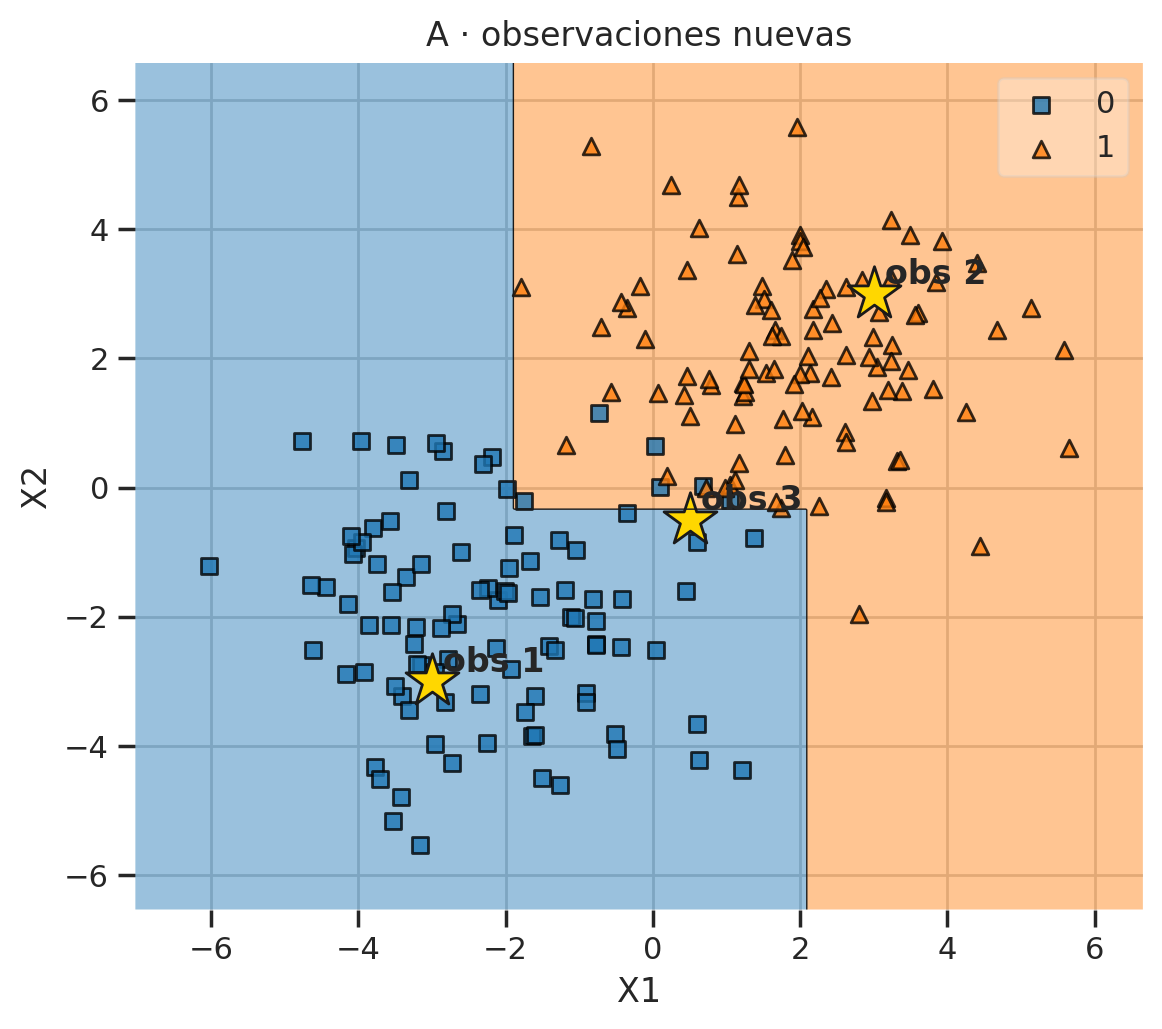

In [26]:
predecir_traza(arbolA, np.array([[-3.0, -3.0], [3.0, 3.0], [0.5, -0.5]]), XA, yA, 'A · observaciones nuevas')

**Juguete B** (dos grupos mezclados). Un punto claro de cada grupo y uno en plena zona de solape:


— Observación 1: (X1=-3.00, X2=-3.00) —
   nodo 0: X1 = -3.00 <= 1.01
   nodo 1: X2 = -3.00 <= 0.51
   nodo 2: X1 = -3.00 <= -1.17
   --> clase 0  | probabilidades [0.98 0.02]

— Observación 2: (X1=3.00, X2=3.00) —
   nodo 0: X1 = 3.00 > 1.01
   nodo 8: X2 = 3.00 > 0.17
   nodo 12: X2 = 3.00 > 1.23
   --> clase 1  | probabilidades [0. 1.]

— Observación 3: (X1=0.30, X2=0.30) —
   nodo 0: X1 = 0.30 <= 1.01
   nodo 1: X2 = 0.30 <= 0.51
   nodo 2: X1 = 0.30 > -1.17
   --> clase 0  | probabilidades [0.69 0.31]


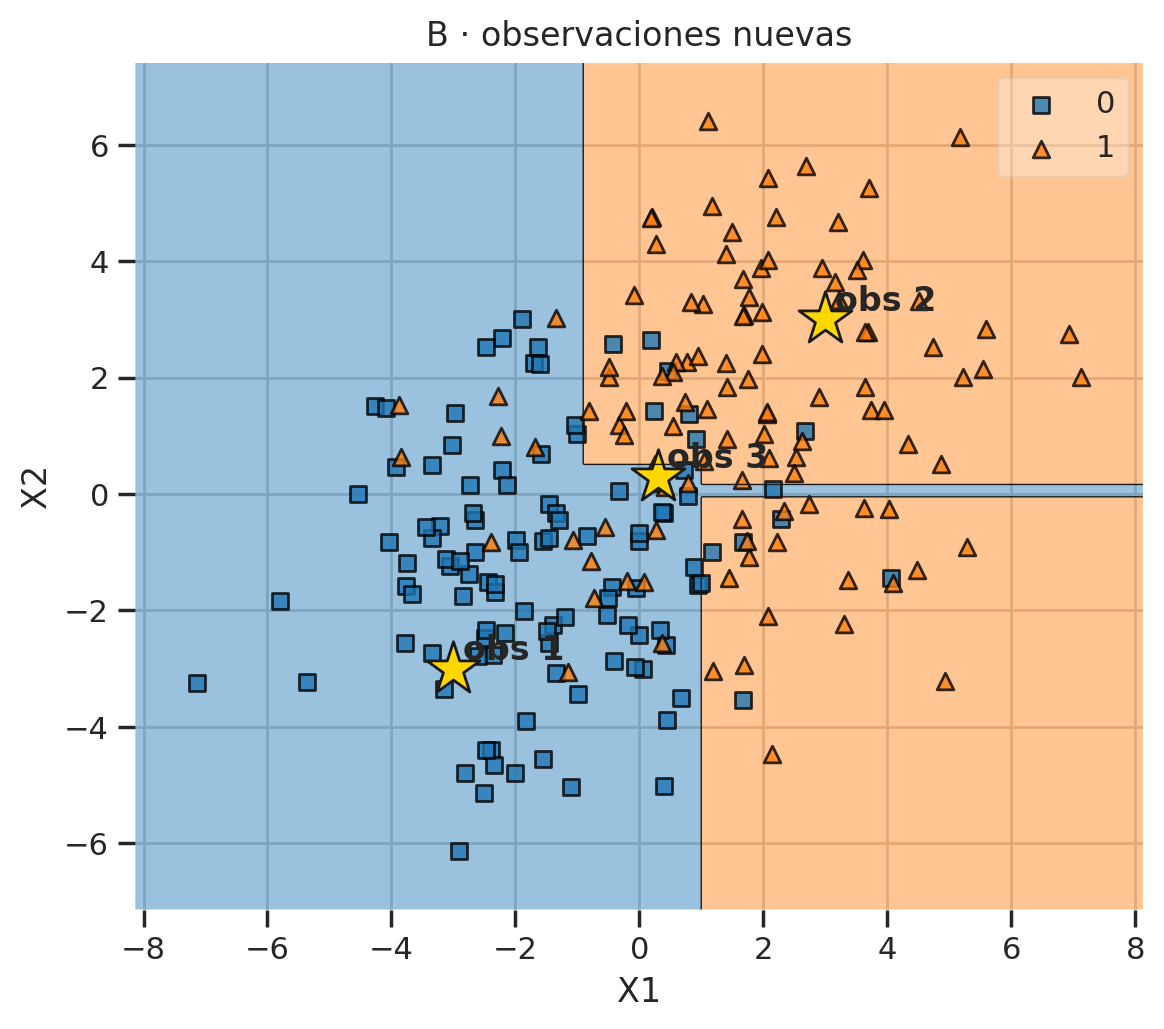

In [27]:
predecir_traza(arbolB, np.array([[-3.0, -3.0], [3.0, 3.0], [0.3, 0.3]]), XB, yB, 'B · observaciones nuevas')

**Juguete C** (tres grupos). Un punto dirigido a cada uno de los tres grupos:


— Observación 1: (X1=-3.00, X2=3.00) —
   nodo 0: X2 = 3.00 > -0.43
   nodo 6: X1 = -3.00 <= 0.08
   nodo 7: X1 = -3.00 <= -1.29
   --> clase 0  | probabilidades [0.99 0.   0.01]

— Observación 2: (X1=3.00, X2=3.00) —
   nodo 0: X2 = 3.00 > -0.43
   nodo 6: X1 = 3.00 > 0.08
   nodo 10: X2 = 3.00 > 1.06
   --> clase 1  | probabilidades [0.02 0.98 0.  ]

— Observación 3: (X1=0.00, X2=-3.00) —
   nodo 0: X2 = -3.00 <= -0.43
   nodo 1: X2 = -3.00 <= -0.92
   --> clase 2  | probabilidades [0. 0. 1.]


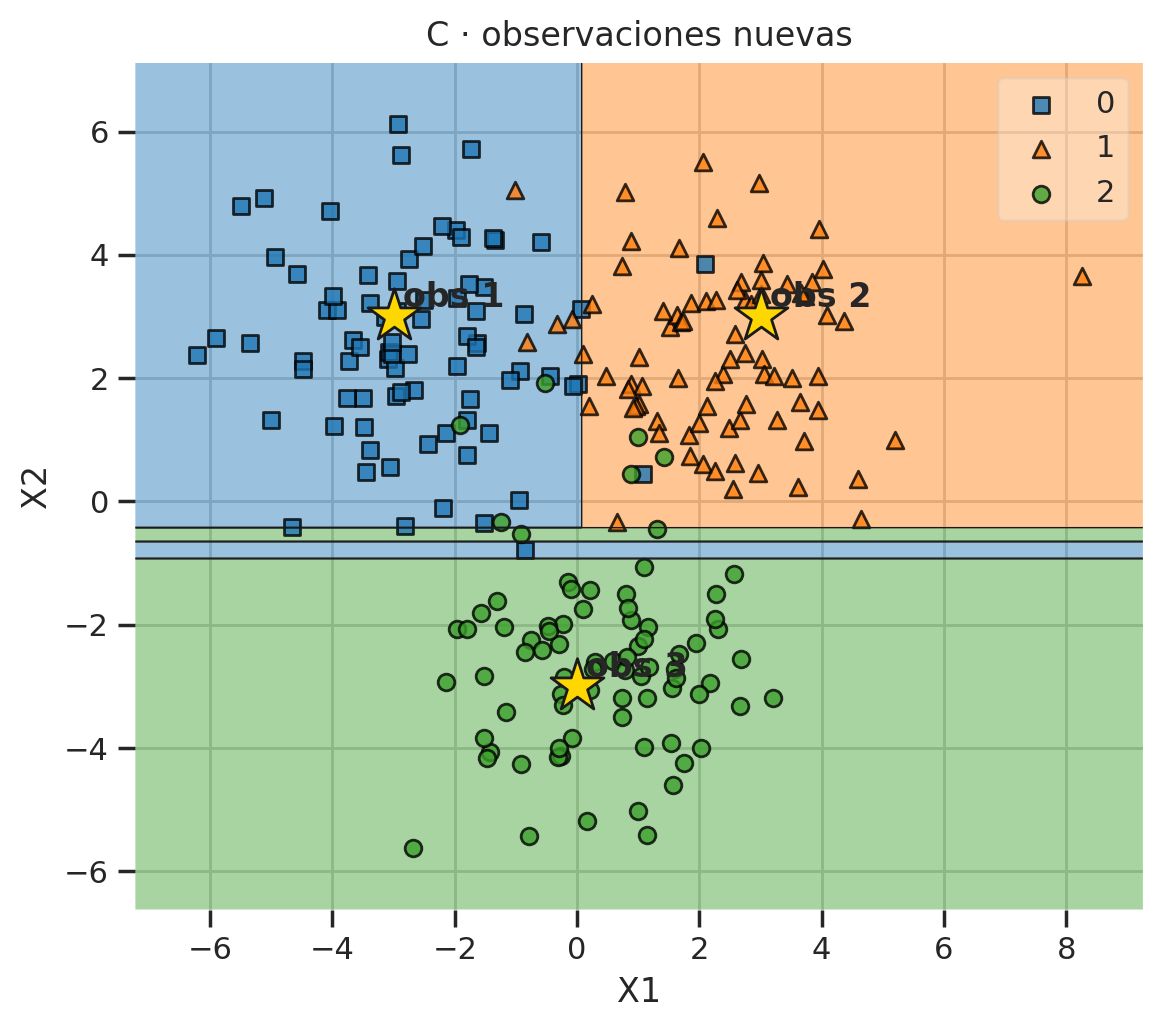

In [28]:
predecir_traza(arbolC, np.array([[-3.0, 3.0], [3.0, 3.0], [0.0, -3.0]]), XC, yC, 'C · observaciones nuevas')

El recorrido es totalmente **transparente**: cada predicción se justifica con la secuencia de reglas que la generó. Las observaciones situadas en el **corazón** de un grupo caen en hojas **puras**, con probabilidad cercana a 1 (máxima confianza). En cambio, los puntos en **zonas de frontera o solape** (la obs. 3 de A y de B) caen en hojas **menos puras**, por lo que su predicción es **menos fiable** —probabilidades más repartidas—. Esto enlaza con el riesgo de **sobreajuste**: si forzamos al árbol a separar también esos puntos dudosos, memorizaremos ruido.



# <font color="steelblue">4. Sobreajuste y cómo controlarlo</font>

Antes de pasar a los ejemplos, conviene entender **el problema y las estrategias** de forma teórica.

**¿Por qué sobreajustan los árboles?** El algoritmo CART reduce la impureza en cada paso, así que, si no se le pone límite, **seguirá dividiendo hasta que cada hoja sea pura** —en el extremo, una hoja por observación—. El resultado es un árbol enorme con **error de entrenamiento casi nulo** pero que ha aprendido también el **ruido** de la muestra concreta, por lo que generaliza mal a datos nuevos.

**El compromiso sesgo–varianza.** Un árbol muy pequeño (pocas divisiones) tiene **alto sesgo**: es demasiado rígido y no captura la estructura real (**infraajuste**). Un árbol muy grande tiene **alta varianza**: se adapta en exceso a la muestra y cambia mucho si cambiamos los datos (**sobreajuste**). El objetivo es encontrar la **complejidad intermedia** que minimiza el error en datos nuevos.

**Las dos estrategias de control:**

* **Parada temprana (pre-poda):** imponer condiciones que **detengan el crecimiento** antes de que el árbol se vuelva demasiado complejo.
* **Poda (post-poda):** dejar crecer el árbol completo y luego **recortar** las ramas que no aportan capacidad de generalización.

Las desarrollamos con un cuarto juguete más difícil: dos **medias lunas** con ruido, donde la frontera real es curva.

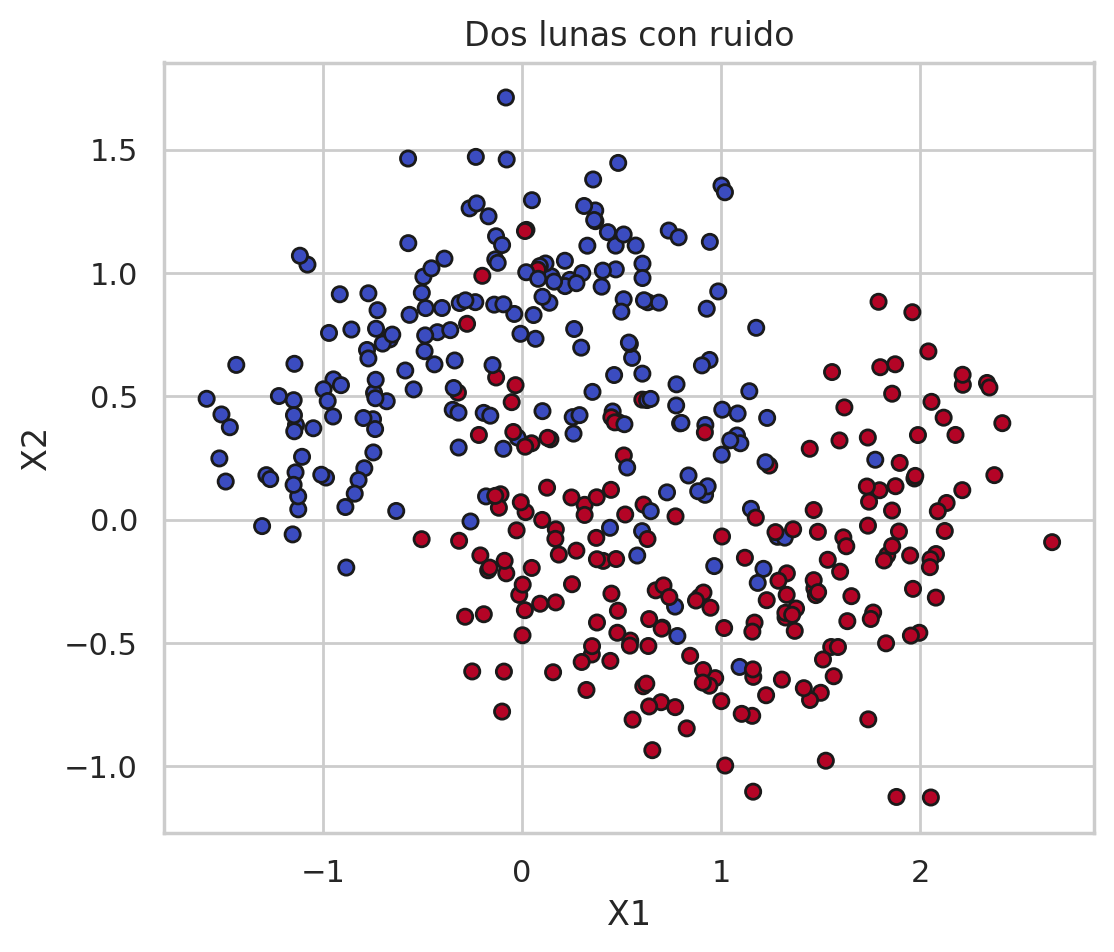

In [29]:
Xm_arr, ym_arr = make_moons(n_samples=400, noise=0.30, random_state=0)
Xm = pd.DataFrame(Xm_arr, columns=['X1', 'X2'])
ym = pd.Series(ym_arr)
xtr, xte, ytr, yte = train_test_split(Xm, ym, test_size=0.3, random_state=42)
plt.figure(figsize=(6, 5)); plt.scatter(Xm['X1'], Xm['X2'], c=ym, s=30, cmap='coolwarm', edgecolor='k')
plt.title('Dos lunas con ruido')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## <font color="steelblue">4.1. El sobreajuste, en imágenes</font>

Sin límites, el árbol divide hasta que **cada hoja sea pura**, memorizando el ruido. Mostramos sus **regiones dentadas** y, con **Graphviz**, el árbol completo (gigante: es justo lo que queremos evitar):

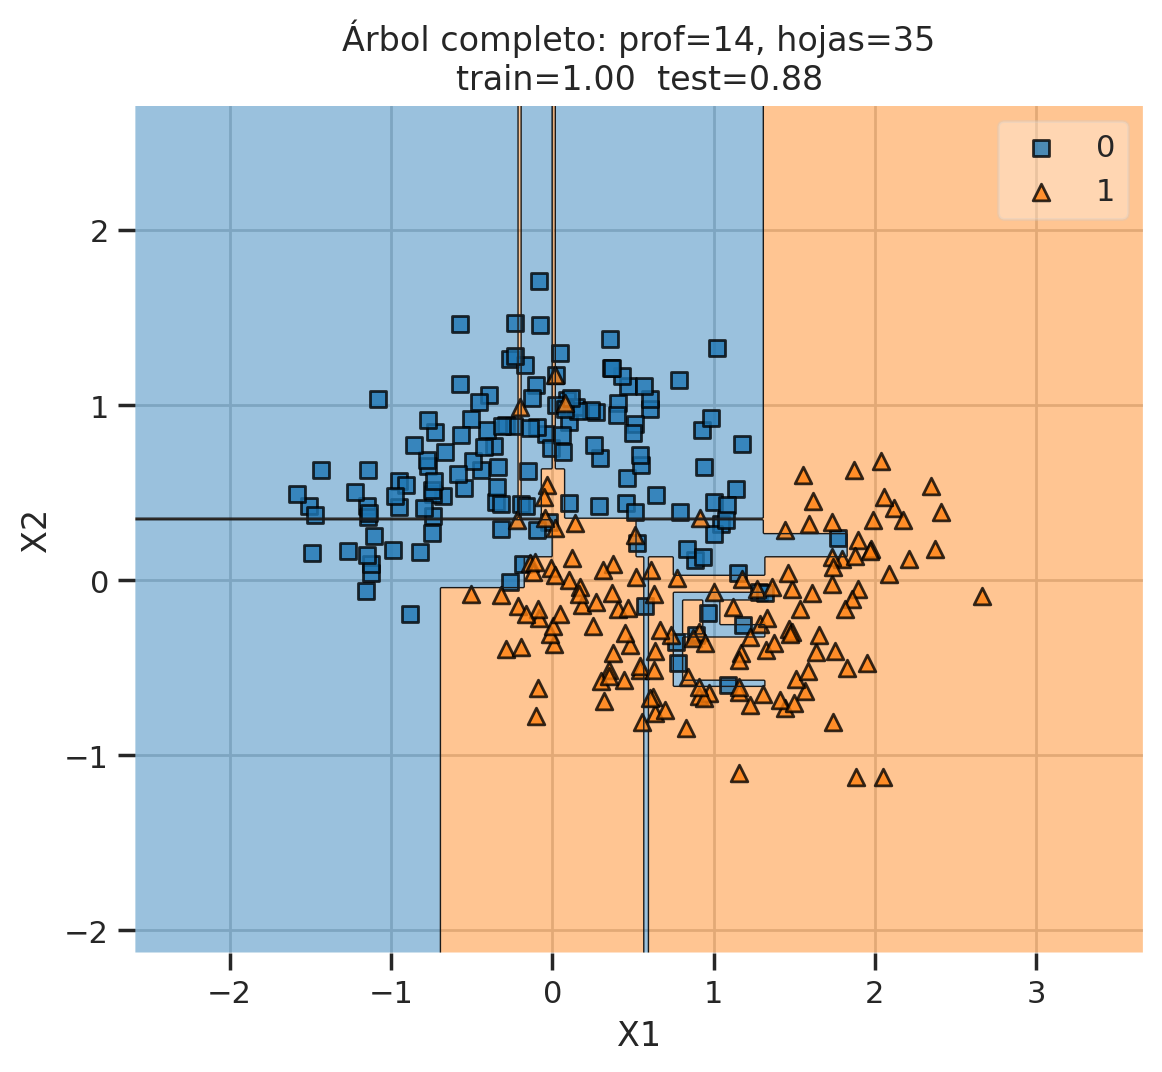

In [30]:
completo = DecisionTreeClassifier(random_state=0).fit(xtr, ytr)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_decision_regions(X=xtr.values, y=ytr.values, clf=completo, ax=ax)
ax.set_title(f'Árbol completo: prof={completo.get_depth()}, hojas={completo.get_n_leaves()}\n'
             f'train={completo.score(xtr, ytr):.2f}  test={completo.score(xte, yte):.2f}')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
plt.show()

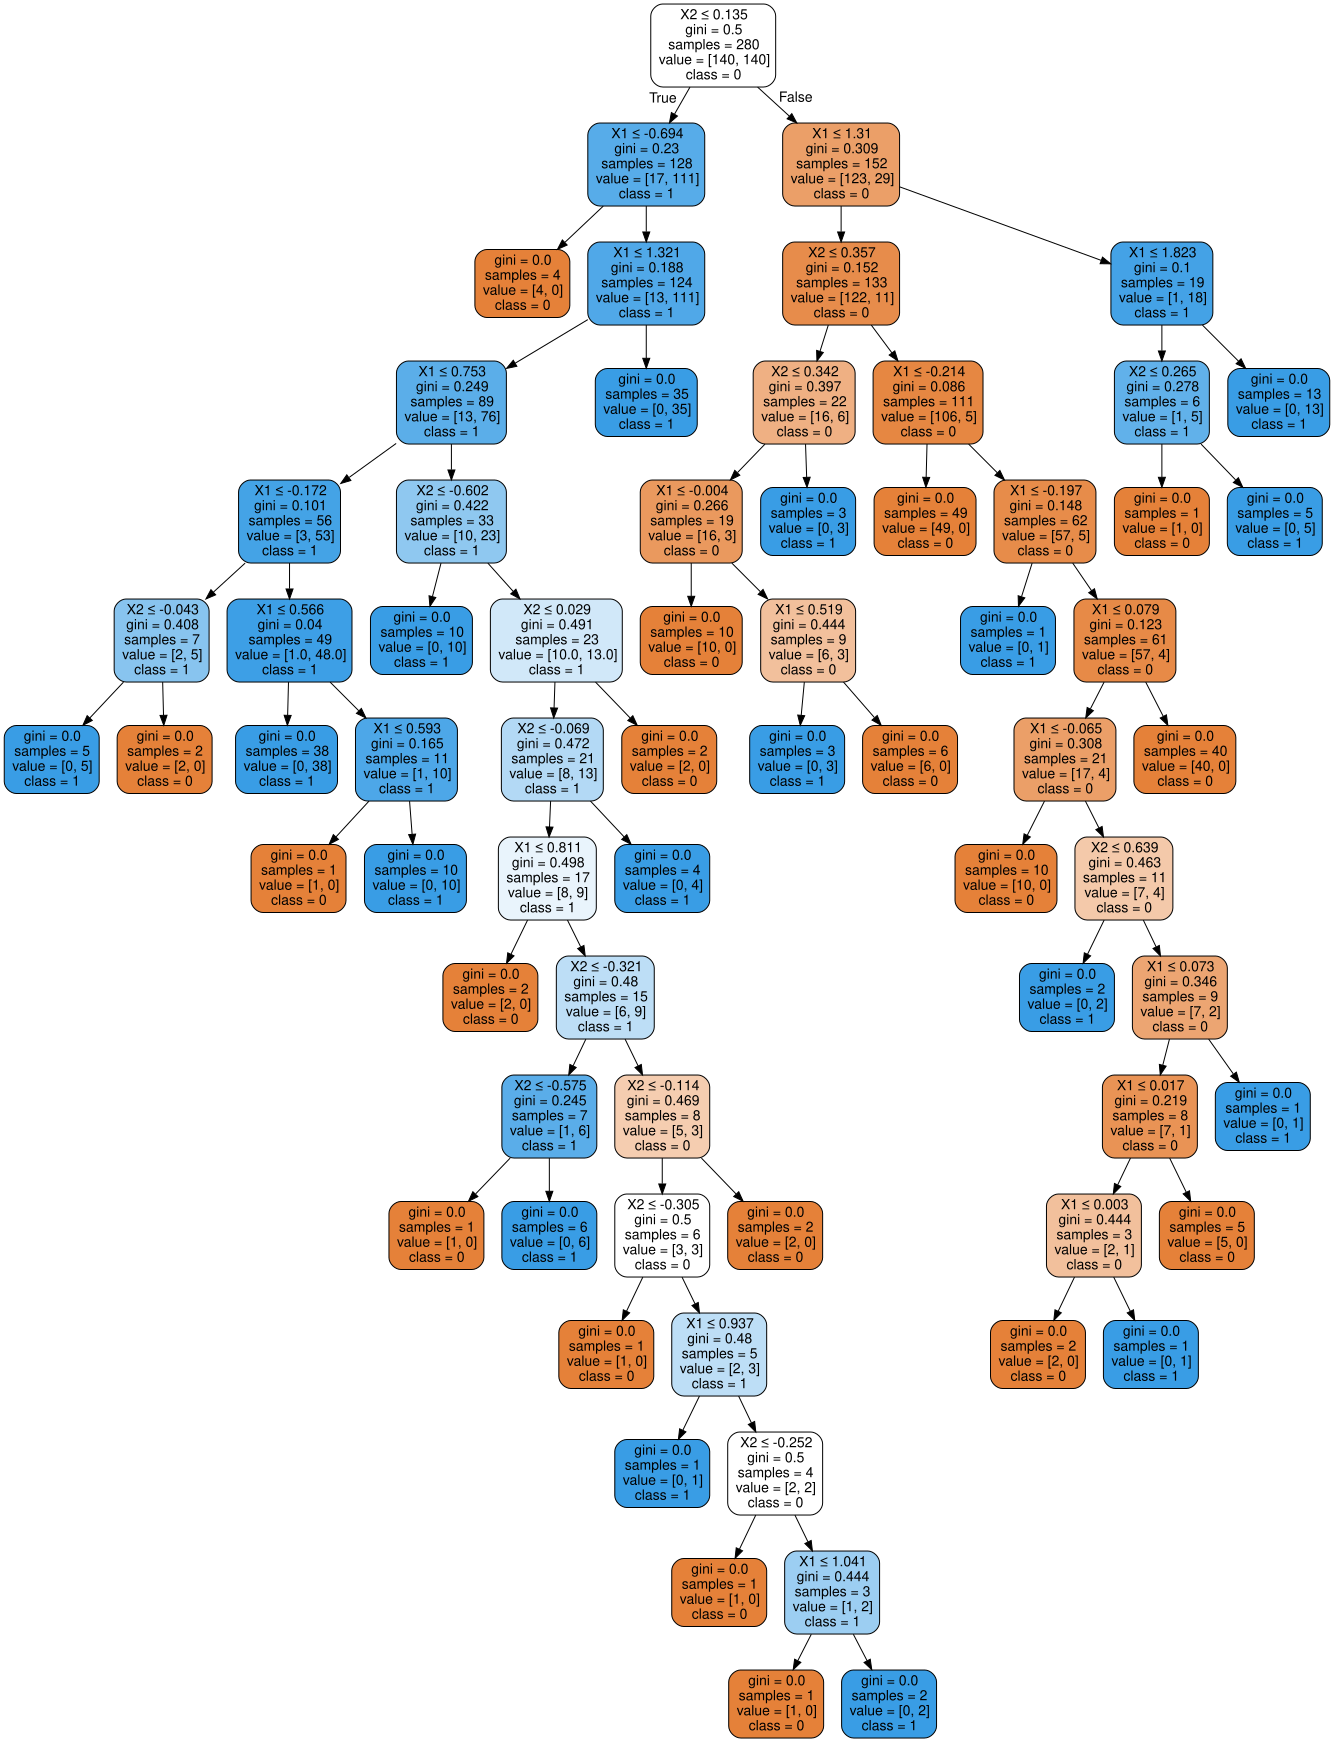

In [ ]:
arbol_graphviz(completo, ['X1', 'X2'], ['0', '1'])

El árbol es **profundo y frondoso** (mira cuántas ramas), acierta **todo** en train (≈1) pero su frontera tiene "islas" que persiguen puntos sueltos: la firma del **sobreajuste** (alta varianza), con peor test.

## <font color="steelblue">4.2. Parada temprana (pre-poda)</font>

Un árbol, si se le deja crecer sin freno, sigue dividiendo hasta que cada hoja es «pura», y acaba **memorizando** el entrenamiento (sobreajuste). La **parada temprana** es la solución más directa: ponerle **reglas de freno** que le impidan seguir dividiendo un nodo cuando se cumplen ciertas condiciones, **aunque todavía pudiera hacerlo**. La idea es **prevenir** el sobreajuste limitando de antemano lo complejo que puede llegar a ser el árbol.

Esas reglas se fijan con **hiperparámetros**: valores que **decide el usuario** (no se aprenden de los datos) y que se eligen probando cuál funciona mejor en validación. Cada uno limita el tamaño del árbol por una vía distinta:

| Hiperparámetro | Qué controla | Ventaja | Inconveniente |
|---|---|---|---|
| **`max_depth`** | Cuántas preguntas encadenadas como máximo (profundidad) | Control global simple del tamaño | Recorta por igual **todas** las ramas |
| **`min_samples_split`** | Cuántas observaciones debe tener un nodo para poder dividirse | Evita dividir grupos diminutos | El valor «bueno» depende del nº de datos |
| **`min_samples_leaf`** | Cuántas observaciones debe tener, como mínimo, cada hoja | Hojas con respaldo → predicciones **estables** | Puede tapar grupos minoritarios reales |
| **`max_leaf_nodes`** | Cuántas hojas como máximo | Fija directamente la complejidad final | Poco intuitivo de elegir |
| **`min_impurity_decrease`** | Cuánta impureza debe reducir una división para aceptarla | Solo divisiones «que valen la pena» | El umbral es difícil de calibrar |

> **Sobre `min_samples_leaf`:** si lo dejas en **1** (el valor por defecto), el árbol puede crear hojas con **una sola observación**: ramas que solo capturan ruido y sobreajustan. Es mejor exigir que cada hoja tenga **un mínimo razonable de datos**. Un truco cómodo es dárselo como **fracción** en vez de como número: por ejemplo `min_samples_leaf=0.05` significa «cada hoja debe contener al menos el **5 %** de las observaciones». Así el mínimo se adapta solo al tamaño del conjunto. Un rango habitual es del **5 % al 25 %**; por ejemplo, con ~50 observaciones, un 10 % obliga a tener unas **5 por hoja**.

Todas estas reglas comparten un mismo punto débil: son **miopes**. Frenan una división que parece pobre **sin saber** que quizá abría la puerta a otra excelente justo después. Esa limitación es la que justifica la **poda** (sección 4.3), que hace lo contrario: deja crecer el árbol y **recorta después**.

### <font color="steelblue">La curva de complejidad</font>

¿Y cómo elegimos el valor de un hiperparámetro (por ejemplo, qué `max_depth` poner)? Con la **curva de complejidad** (`validation_curve` en scikit-learn). La idea es simple: probamos **varios valores** del hiperparámetro y, para cada uno, medimos el acierto **dos veces** —en **entrenamiento** y en **validación**— y lo dibujamos. Comparar ambas curvas nos dice si el árbol se queda **corto** o se pasa de complejo. Se lee así:

* **Zona izquierda (árbol demasiado simple):** las dos curvas están **bajas y juntas** → el modelo **no aprende lo suficiente** (*infraajuste*).
* **Zona derecha (árbol demasiado complejo):** el acierto en **entrenamiento sigue subiendo** (hacia el 100 %), pero el de **validación empeora** → el modelo **memoriza** (*sobreajuste*). Cuanto más se **separan** las dos curvas, peor.
* **Punto óptimo:** el valor donde la curva de **validación** llega a su **máximo**, justo antes de empezar a bajar. Ese es el mejor equilibrio.

La construimos sobre `max_depth` en las lunas:

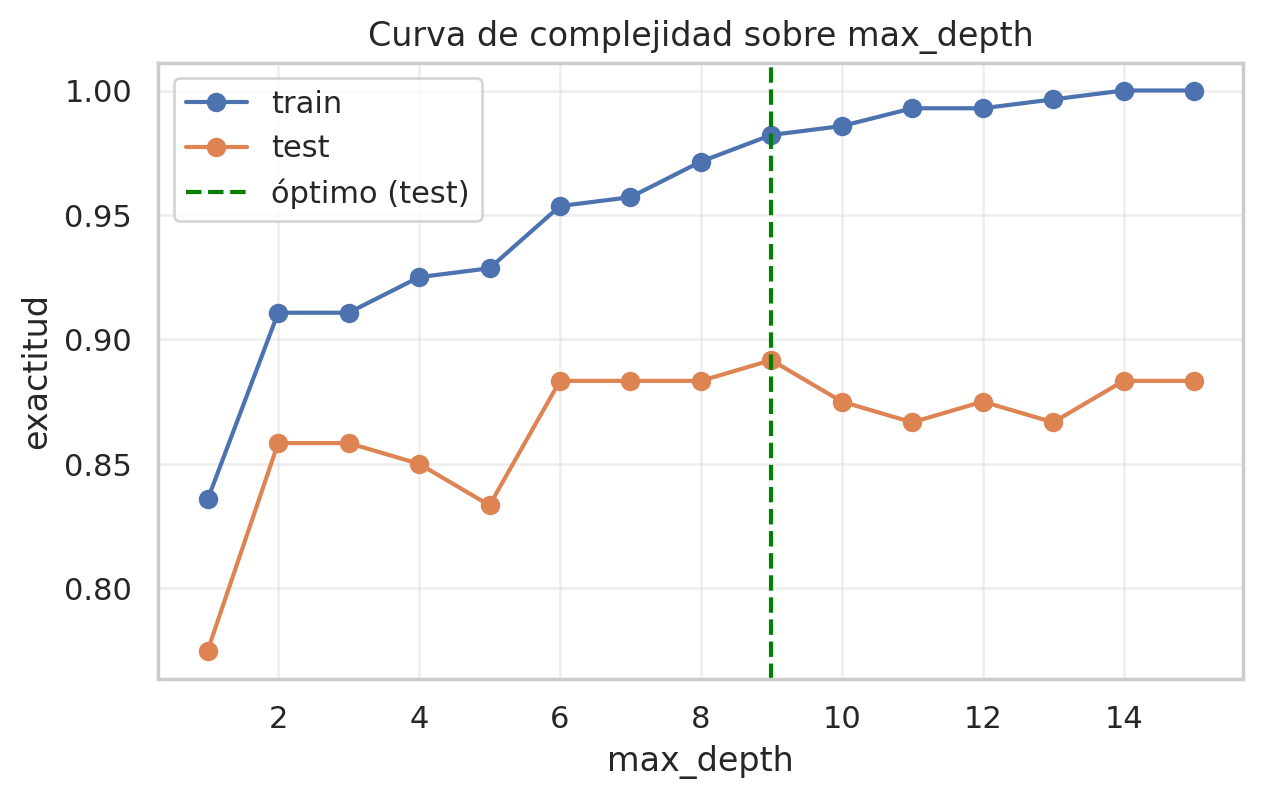

In [31]:
prof = range(1, 16)
tr = [DecisionTreeClassifier(max_depth=d, random_state=0).fit(xtr, ytr).score(xtr, ytr) for d in prof]
teo = [DecisionTreeClassifier(max_depth=d, random_state=0).fit(xtr, ytr).score(xte, yte) for d in prof]
plt.figure(figsize=(7, 4)); plt.plot(prof, tr, 'o-', label='train'); plt.plot(prof, teo, 'o-', label='test')
plt.axvline(list(prof)[int(np.argmax(teo))], ls='--', color='green', label='óptimo (test)')
plt.xlabel('max_depth')
plt.ylabel('exactitud')
plt.title('Curva de complejidad sobre max_depth')
plt.legend()
plt.grid(alpha=.3)
plt.show()

Con profundidad 1–2 ambas curvas son bajas (infraajuste); el test alcanza su **máximo** en una profundidad **intermedia** y luego cae mientras el train sigue subiendo hacia 1 (sobreajuste). La distancia creciente entre las curvas es la **varianza** del modelo. El valor óptimo de `max_depth` es el que marca la línea verde.

## <font color="steelblue">4.3 Varios hiperparámetros a la vez</font>

Los hiperparámetros **interactúan**: limitar la profundidad no es lo mismo si además exigimos hojas grandes. Por eso se exploran **a la vez** con `GridSearchCV`. Con **dos** (`max_depth` × `min_samples_leaf`, este como **fracción del 5 % al 25 %**) lo vemos como **mapa de calor** de la exactitud en validación cruzada:

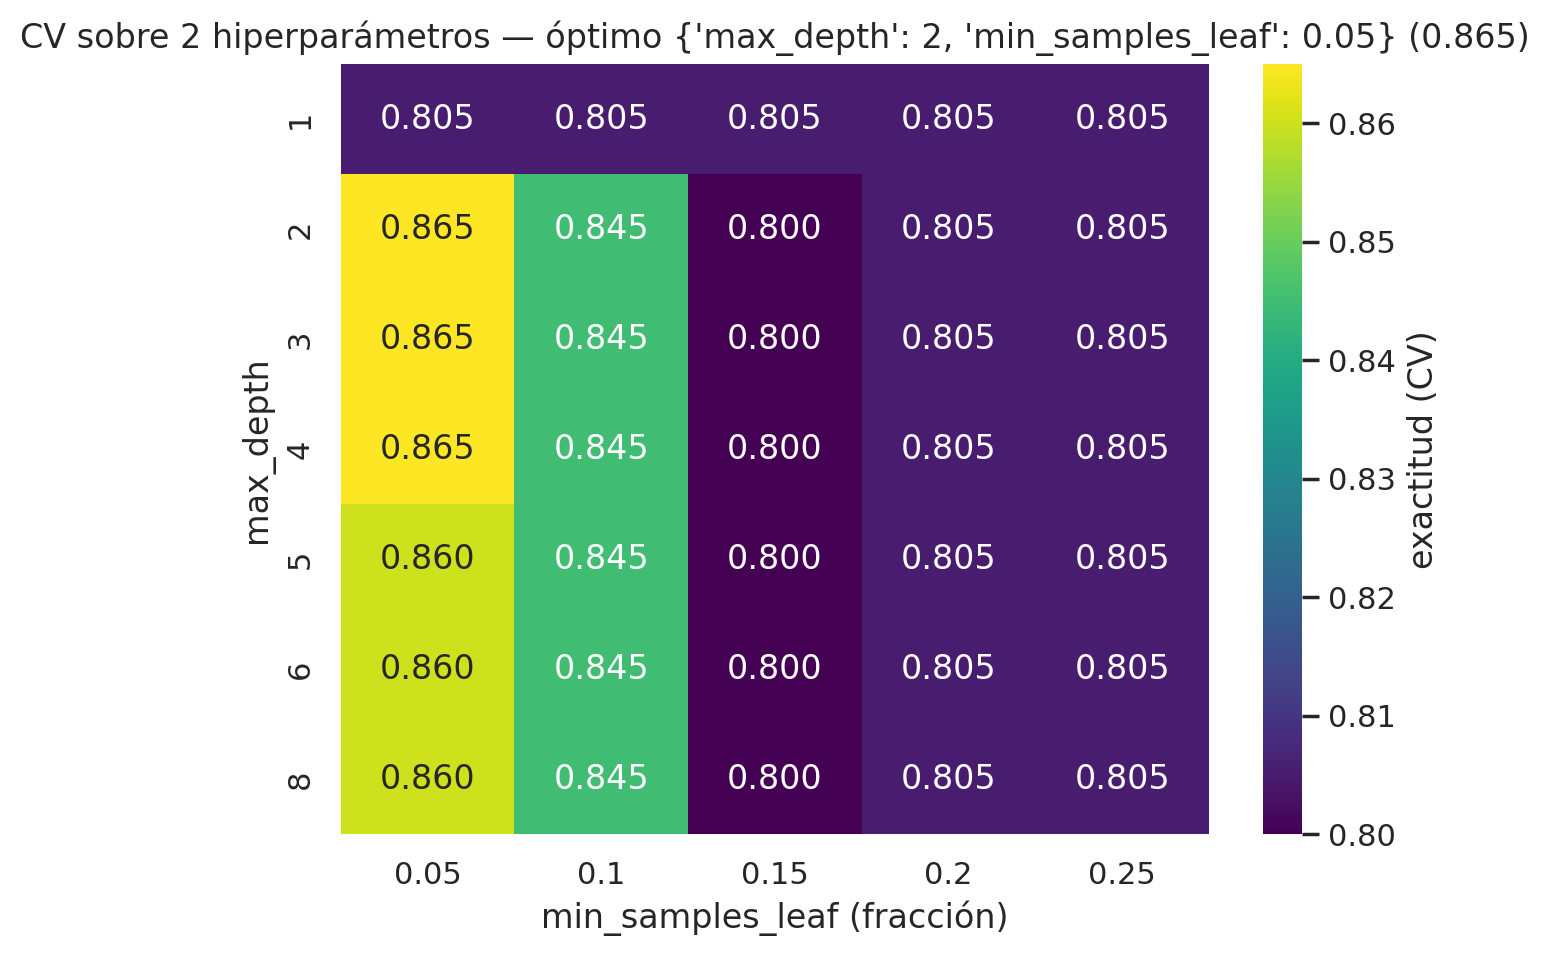

In [32]:
grid2 = {'max_depth': [1, 2, 3, 4, 5, 6, 8], 'min_samples_leaf': [0.05, 0.10, 0.15, 0.20, 0.25]}
gs2 = GridSearchCV(DecisionTreeClassifier(random_state=0), grid2, cv=5, scoring='accuracy').fit(Xm, ym)
piv = pd.DataFrame(gs2.cv_results_).pivot(index='param_max_depth', columns='param_min_samples_leaf', values='mean_test_score')
plt.figure(figsize=(7, 5)); sns.heatmap(piv, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'exactitud (CV)'})
plt.title(f'CV sobre 2 hiperparámetros — óptimo {gs2.best_params_} ({gs2.best_score_:.3f})')
plt.xlabel('min_samples_leaf (fracción)')
plt.ylabel('max_depth')
plt.show()

El óptimo **no es una profundidad concreta** sino una **combinación**: la mejor profundidad cambia según el `min_samples_leaf` exigido (y al revés). Con un solo hiperparámetro veríamos solo una "rodaja" de este mapa. Añadir un **tercero** (`ccp_alpha`) extiende la búsqueda a una rejilla 3D —ya no visualizable como mapa plano— que `GridSearchCV` explora igual; así lo haremos en los ejemplos reales.

## <font color="steelblue">4.4. Poda por coste-complejidad (post-poda)</font>

La pre-poda frenaba el árbol *durante* el crecimiento, con el riesgo de pararse demasiado pronto. La **post-poda** invierte el orden y evita esa miopía: primero **deja crecer el árbol completo** $T_0$ (que sobreajusta a propósito) y **después lo recorta** desde las hojas hacia la raíz, quedándose con la parte que de verdad generaliza. La pregunta es **cuánto** recortar, y para responderla necesitamos una forma de medir el equilibrio entre acierto y tamaño.

### <font color="steelblue">La idea: penalizar el tamaño</font>

Para un valor de $\alpha\ge0$ se define el **coste-complejidad** de un subárbol $T$:

$$R_\alpha(T) = R(T) + \alpha\,|T|,$$

donde $R(T)$ es el error (impureza) total de las hojas y $|T|$ su número. Es un **coste con dos términos en tensión**: $R(T)$ baja al añadir hojas (más ajuste), pero $\alpha\,|T|$ **sube** (paga un «peaje» por cada hoja). El parámetro $\alpha$ es el precio de ese peaje:

* con $\alpha = 0$, no se penaliza el tamaño y gana el árbol completo $T_0$;
* al **aumentar** $\alpha$, cada hoja debe «ganarse el sueldo» reduciendo bastante el error, o se elimina → árboles **cada vez más pequeños**;
* con $\alpha$ muy grande, hasta la primera división sale demasiado cara y queda solo la **raíz**.

Así, $\alpha$ es un **mando de simplicidad**: lo giramos de 0 (complejo) a grande (simple).

### <font color="steelblue">El atajo: no hay que probar todos los subárboles</font>

Buscar, para cada $\alpha$, el mejor $T$ entre **todos** los subárboles posibles sería inviable (son demasiados). Por suerte existe un procedimiento eficiente:

* **Poda del eslabón más débil.** Para cada nodo interno $t$ se mide
$$g(t)=\dfrac{R(t)-R(T_t)}{|T_t|-1},$$
es decir, cuánto **aumenta el error por cada hoja que eliminamos** si colapsamos la rama $T_t$ que cuelga de $t$ (convertir ese nodo en hoja). Un $g(t)$ pequeño significa que esa rama, con todas sus hojas, **aporta muy poco**: es el **«eslabón más débil»**, y se colapsa primero. (De hecho, $g(t)$ es el valor de $\alpha$ a partir del cual deja de compensar mantener esa rama.)
* **Secuencia anidada.** Repitiendo el proceso —podar el eslabón más débil, recalcular, volver a podar— se obtiene una **sucesión de subárboles encajados**
$$T_0 \supset T_1 \supset \dots \supset \{\text{raíz}\},$$
cada uno **óptimo** en un intervalo de $\alpha$. Lo valioso es que los valores de $\alpha$ donde cambia el subárbol óptimo forman una **lista finita**, los **alphas efectivos** (`ccp_alphas` en scikit-learn, junto con las impurezas en `ccp_alpha`s vía `cost_complexity_pruning_path`). En lugar de un continuo infinito de $\alpha$, solo hay que evaluar **esos** candidatos.
* **Elección de $\alpha$.** Cada subárbol de la secuencia se valora por **validación cruzada** y se aplica el $\alpha$ elegido reentrenando con `DecisionTreeClassifier(ccp_alpha=α)`.

### <font color="steelblue">Dos criterios para elegir el árbol: óptimo y parsimonioso (regla 1-SE)</font>

Una vez tenemos el rendimiento (CV) de cada subárbol de la secuencia, podemos elegir con **dos criterios**, que conviene tener claros **antes** de mirar el gráfico:

* **Criterio óptimo:** quedarse con el $\alpha$ de **máximo CV**. Da el mejor rendimiento estimado, pero el árbol resultante puede ser **innecesariamente grande**, porque a menudo varios $\alpha$ cercanos dan un CV casi idéntico (la curva de CV suele tener una **meseta** plana en su cima).
* **Criterio parsimonioso (regla de 1 error estándar, 1-SE):** la estimación de CV **no es exacta**, tiene incertidumbre; su desviación estándar (SE) mide cuánto podría variar solo por el azar de las particiones. La regla dice: no persigas diferencias más pequeñas que ese ruido. En concreto, elegimos el árbol **más pequeño** (mayor $\alpha$) cuyo CV siga **dentro de una desviación estándar** del mejor:
$$\alpha_{\text{1-SE}} = \max\{\alpha : \text{CV}(\alpha) \ge \text{CV}_{\max} - \text{SE}\}.$$
La idea: si dos árboles tienen un CV **estadísticamente indistinguible**, **preferimos el más simple** (navaja de Occam), porque será más **interpretable**, más **robusto** ante datos nuevos y menos propenso a sobreajustar. En la práctica, el criterio 1-SE suele dar árboles bastante más pequeños **sin apenas perder acierto**.

Calculamos la secuencia y dibujamos la curva de CV (media ± SE) con **ambos** criterios marcados:

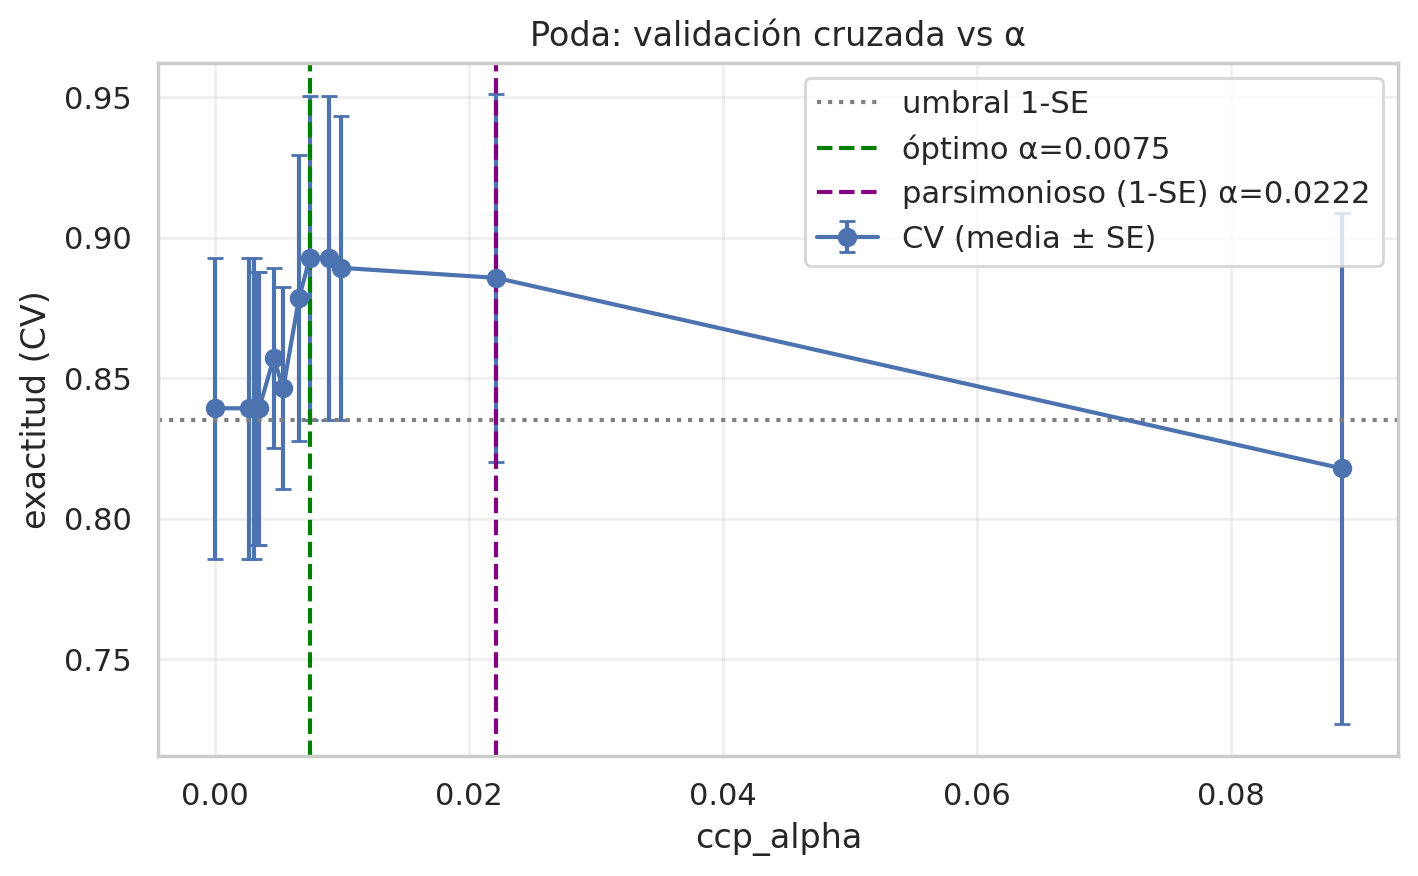

In [33]:
path = completo.cost_complexity_pruning_path(xtr, ytr)
alphas = path.ccp_alphas[:-1]
medias = np.array([cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a), xtr, ytr, cv=10).mean() for a in alphas])
desv   = np.array([cross_val_score(DecisionTreeClassifier(random_state=0, ccp_alpha=a), xtr, ytr, cv=10).std()  for a in alphas])
b = int(np.argmax(medias)); umbral_1se = medias[b] - desv[b]
cand = np.where(medias >= umbral_1se)[0]; ip = cand[int(np.argmax(alphas[cand]))]
alpha_opt, alpha_parsi = alphas[b], alphas[ip]
plt.figure(figsize=(8, 4.5)); plt.errorbar(alphas, medias, yerr=desv, marker='o', capsize=3, label='CV (media ± SE)')
plt.axhline(umbral_1se, ls=':', color='gray', label='umbral 1-SE')
plt.axvline(alpha_opt, ls='--', color='green', label=f'óptimo α={alpha_opt:.4f}')
plt.axvline(alpha_parsi, ls='--', color='purple', label=f'parsimonioso (1-SE) α={alpha_parsi:.4f}')
plt.xlabel('ccp_alpha')
plt.ylabel('exactitud (CV)')
plt.title('Poda: validación cruzada vs α')
plt.legend()
plt.grid(alpha=.3)
plt.show()

Cada punto es un **subárbol** de la secuencia de poda: a la **izquierda** ($\alpha$ pequeño) están los árboles **grandes** (apenas podados); a la **derecha** ($\alpha$ grande), los **pequeños** (muy podados, hasta la raíz). La curva de CV **sube** al principio (podar el exceso **mejora** la generalización), alcanza un **máximo** —el árbol **óptimo** (línea verde)— y luego **cae** cuando la poda es excesiva (infraajuste). La línea gris marca el **umbral 1-SE**; el mayor $\alpha$ cuyo CV queda por encima de esa línea define el árbol **parsimonioso** (línea morada), más a la derecha → **más pequeño**. Comparamos las dos soluciones, primero las **regiones**:

           solución  alpha  nº hojas  profundidad    CV  exactitud test
    Óptima (máx CV) 0.0075         8            6 0.893           0.867
Parsimoniosa (1-SE) 0.0222         3            2 0.886           0.833


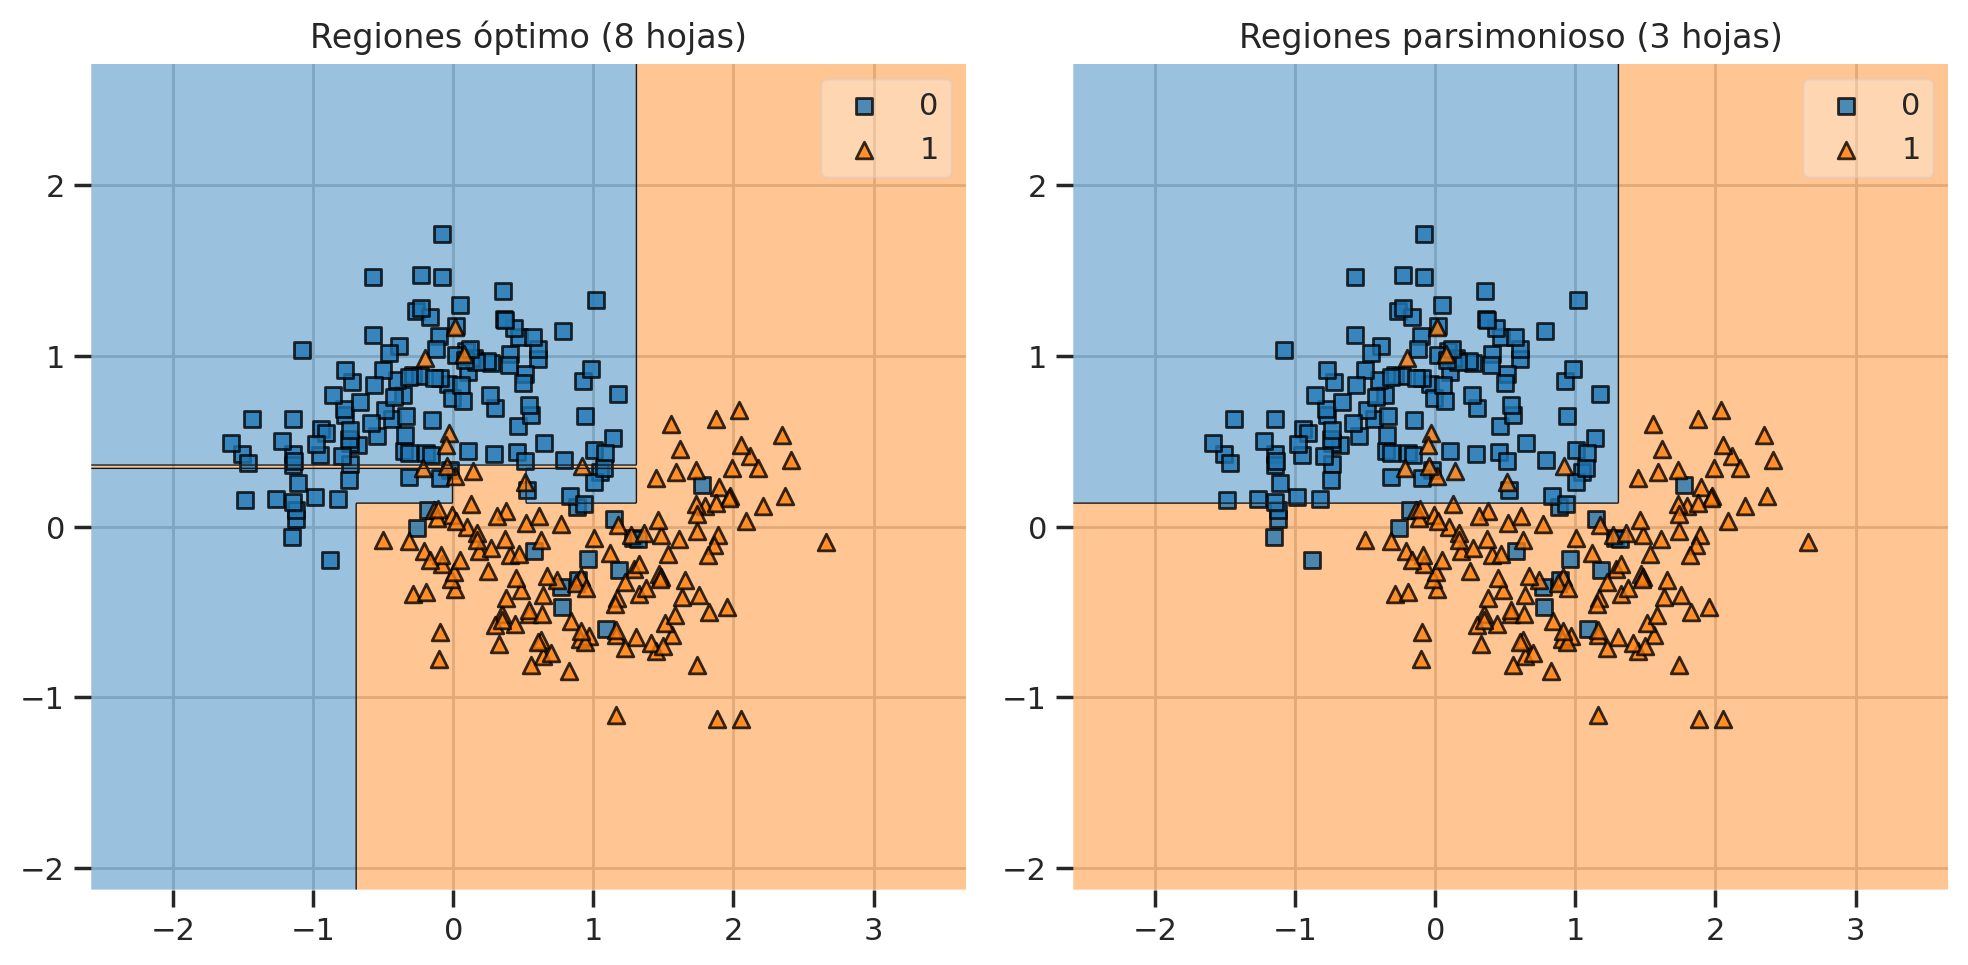

In [35]:
opt = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha_opt).fit(xtr, ytr)
par = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha_parsi).fit(xtr, ytr)
comparacion = pd.DataFrame({
    'solución': ['Óptima (máx CV)', 'Parsimoniosa (1-SE)'],
    'alpha': [round(alpha_opt, 4), round(alpha_parsi, 4)],
    'nº hojas': [opt.get_n_leaves(), par.get_n_leaves()],
    'profundidad': [opt.get_depth(), par.get_depth()],
    'CV': [round(medias[b], 3), round(medias[ip], 3)],
    'exactitud test': [round(opt.score(xte, yte), 3), round(par.score(xte, yte), 3)]})
print(comparacion.to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_decision_regions(X=xtr.values, y=ytr.values, clf=opt, ax=ax[0])
ax[0].set_title(f'Regiones óptimo ({opt.get_n_leaves()} hojas)')
plot_decision_regions(X=xtr.values, y=ytr.values, clf=par, ax=ax[1])
ax[1].set_title(f'Regiones parsimonioso ({par.get_n_leaves()} hojas)')
plt.tight_layout()
plt.show()

Y los dos árboles con **Graphviz** (legibles). Árbol **ÓPTIMO**:

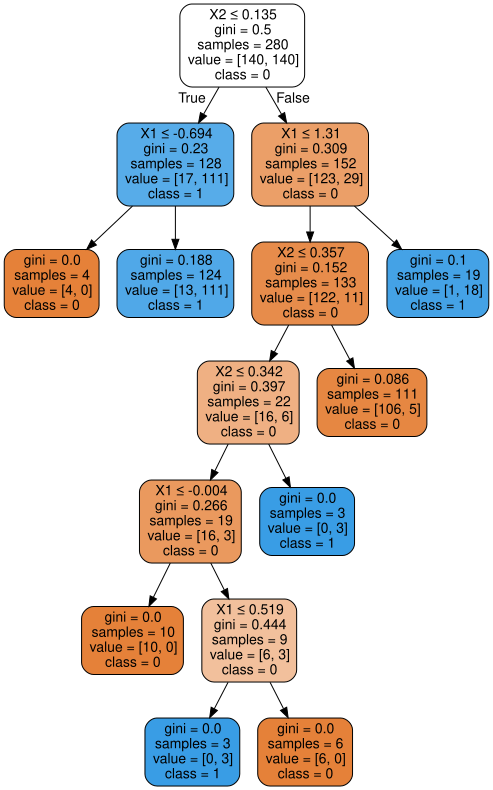

In [36]:
arbol_graphviz(opt, ['X1', 'X2'], ['0', '1'])

Árbol **PARSIMONIOSO**:

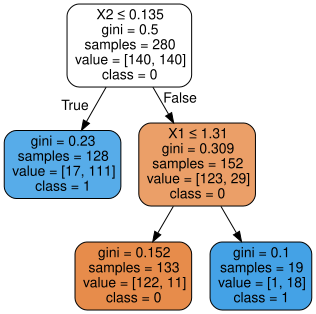

In [37]:
arbol_graphviz(par, ['X1', 'X2'], ['0', '1'])

El árbol **parsimonioso** tiene **bastantes menos hojas** que el óptimo y un CV prácticamente igual (dentro del margen de 1-SE): su frontera es más **suave y robusta**, más fácil de explicar y con menos riesgo de sobreajuste, sacrificando muy poco rendimiento. Cuando la interpretabilidad importa, suele ser la elección preferible.

## <font color="steelblue">4.5. Valoración de la clasificación y efectos del sobreentrenamiento</font>

Valoramos el modelo **parsimonioso** con las **funciones del curso** y comparamos train vs test para detectar sobreentrenamiento.

In [38]:
reports_clas(par, xtr, ytr, xte, yte)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       140
           1       0.88      0.92      0.90       140

    accuracy                           0.90       280
   macro avg       0.90      0.90      0.90       280
weighted avg       0.90      0.90      0.90       280


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        60
           1       0.83      0.83      0.83        60

    accuracy                           0.83       120
   macro avg       0.83      0.83      0.83       120
weighted avg       0.83      0.83      0.83       120



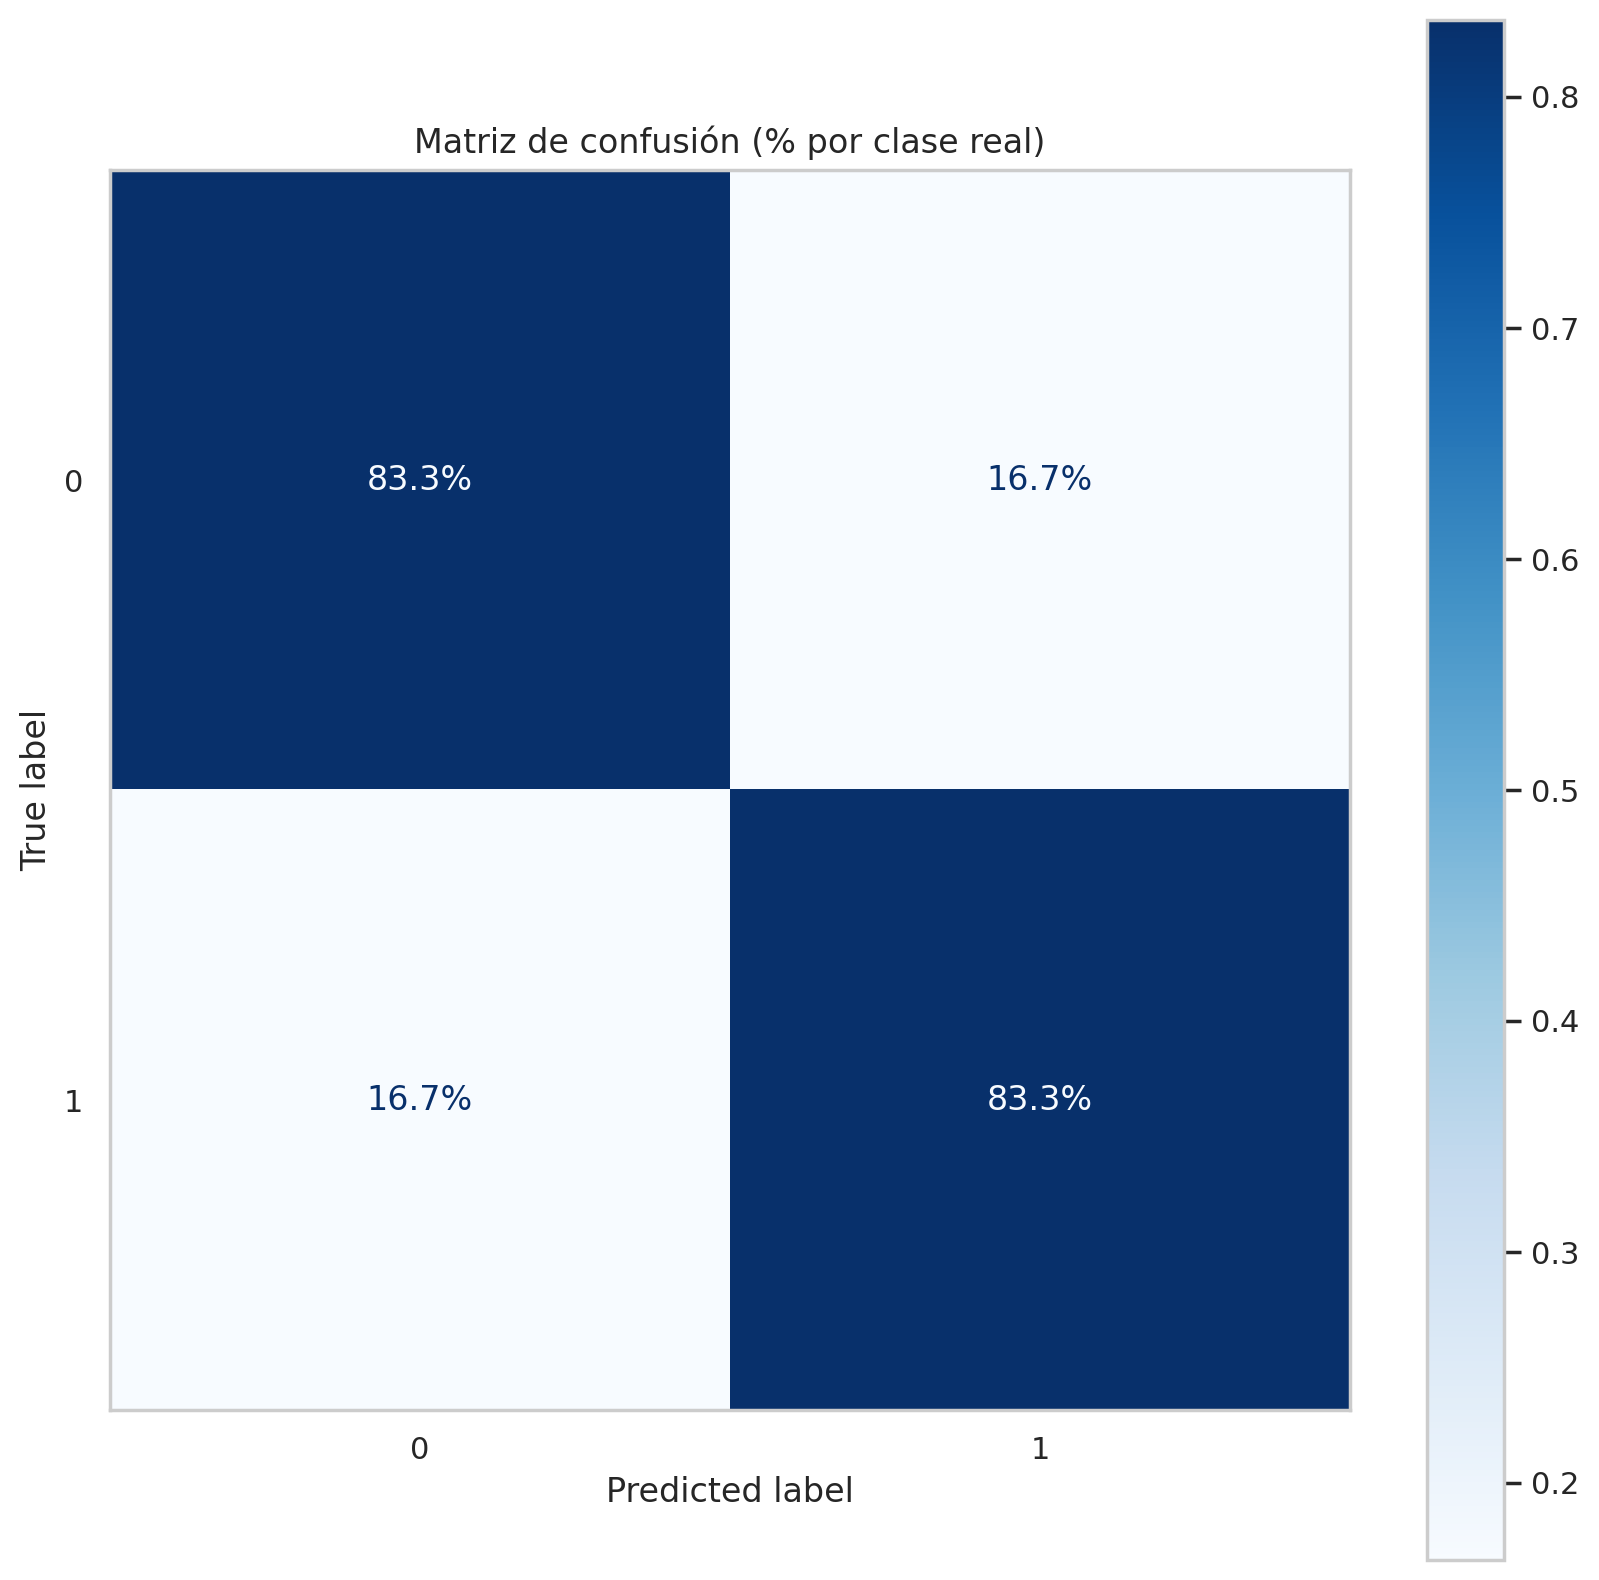

In [39]:
matriz_confusion(par, xte, yte);

In [40]:
val_toy = validar_modelo(par, xtr, ytr, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.886 +/- 0.065


En `reports_clas` comparamos las métricas de **entrenamiento** y **test**: si las de train fueran casi perfectas y las de test mucho peores, sería la firma del **sobreentrenamiento**. Tras la poda, ambas quedan **próximas**, señal de que el modelo **generaliza**. `validar_modelo` añade la **estabilidad**: una media de CV alta con poca dispersión indica que el resultado no depende de la partición concreta.

# <font color="steelblue">5. Ventajas y desventajas</font>

**Ventajas**
* **Interpretables y visualizables:** el modelo es un diagrama de reglas legible, incluso con muchas predictoras.
* **No paramétricos:** no suponen ninguna distribución ni forma funcional de la frontera.
* **Mínimo preprocesado:** no requieren estandarizar; toleran escalas mixtas y son robustos a valores atípicos.
* **Capturan interacciones** complejas y no lineales entre variables de forma automática.
* **Seleccionan variables** por sí mismos mediante la importancia (reducción de impureza).
* **Manejan numéricas y categóricas** y degradan con elegancia ante valores ausentes.

**Desventajas**
* **Alta varianza:** un único árbol es **inestable** —pequeños cambios en los datos producen árboles distintos— y su capacidad predictiva es limitada.
* **Sobreajustan** con facilidad si no se controlan con parada temprana y/o poda.
* **Sensibles al desbalanceo** de clases (la clase mayoritaria domina las divisiones).
* **Discretizan** las predictoras continuas al cortar por umbrales, perdiendo parte de la información.
* **No extrapolan** fuera del rango de valores observado en el entrenamiento.
* **Sesgo de selección:** tienden a favorecer variables con muchos posibles puntos de corte.

> Muchas de estas debilidades se corrigen **combinando árboles** (*Bagging*, *Random Forest*, *Boosting*), que reducen drásticamente la varianza manteniendo el bajo sesgo.



# <font color="steelblue">6. Árboles de decisión en scikit-learn</font>

La clase es **`DecisionTreeClassifier`**. Parámetros principales (casi todos para **controlar el sobreajuste**):

| Parámetro | Descripción | Por defecto |
|---|---|---|
| **`criterion`** | Impureza: `'gini'`, `'entropy'`/`'log_loss'`. | `'gini'` |
| **`max_depth`** | Profundidad máxima. | `None` |
| **`min_samples_split`** | Mínimo de muestras para dividir. | `2` |
| **`min_samples_leaf`** | Mínimo de muestras por hoja (entero o **fracción**). | `1` |
| **`max_leaf_nodes`** | Número máximo de hojas. | `None` |
| **`max_features`** | Variables candidatas por división. | `None` |
| **`min_impurity_decrease`** | Reducción mínima de impureza para dividir. | `0.0` |
| **`ccp_alpha`** | Parámetro $\alpha$ de la poda por coste-complejidad. | `0.0` |
| **`class_weight`** | `'balanced'` compensa el desbalanceo. | `None` |
| **`random_state`** | Semilla. | `None` |

**Métodos y atributos:** `fit`, `predict`, `predict_proba`, `score`, `decision_path`, `cost_complexity_pruning_path`, `get_depth`/`get_n_leaves`, `feature_importances_`. Visualización: `plot_tree`, `export_text` y **`export_graphviz`** (la más legible).



# <font color="steelblue">6. Árboles de decisión en scikit-learn</font>

La clase es **`sklearn.tree.DecisionTreeClassifier`** (para regresión, su análoga `DecisionTreeRegressor`). La mayoría de sus parámetros existen con un único fin: **controlar el sobreajuste**, ya sea frenando el crecimiento (pre-poda) o recortando después (post-poda).

**Parámetros**

Criterio de división.
* **`criterion`** — impureza a minimizar: `'gini'` (por defecto), `'entropy'` o `'log_loss'` (estas dos equivalentes, usan la entropía). En la práctica dan árboles muy parecidos.
* **`splitter`** — `'best'` (busca el **mejor** umbral, por defecto) o `'random'` (elige el mejor entre umbrales al azar; más rápido y aporta aleatoriedad, útil dentro de *ensembles*).

Pre-poda (frenar el crecimiento).
* **`max_depth`** — profundidad máxima. Def. `None` (crece hasta agotar la pureza).
* **`min_samples_split`** — mínimo de muestras para que un nodo **pueda** dividirse. Def. `2`.
* **`min_samples_leaf`** — mínimo de muestras que debe quedar en **cada hoja** (entero o **fracción** del total). Def. `1`.
* **`min_weight_fraction_leaf`** — como el anterior, pero en **fracción del peso** total de las muestras; útil con `sample_weight` o clases desbalanceadas. Def. `0.0`.
* **`max_leaf_nodes`** — nº máximo de hojas (hace crecer el árbol en modo *best-first*, priorizando las mejores divisiones). Def. `None`.
* **`min_impurity_decrease`** — una división solo se acepta si reduce la impureza **al menos** este valor. Def. `0.0`.

Post-poda.
* **`ccp_alpha`** — el $\alpha$ de la **poda por coste-complejidad** (sección 4.4): mayor $\alpha$ → árbol más pequeño. Def. `0.0` (sin poda).

Otros.
* **`max_features`** — nº de variables candidatas que se consideran **en cada división** (`None` = todas; también `'sqrt'`, `'log2'`, un entero o una fracción). Introduce aleatoriedad; es clave en *random forests*, pero en un árbol único suele dejarse en `None`.
* **`class_weight`** — `'balanced'` compensa el **desbalanceo** (pondra cada clase inversamente a su frecuencia) o un diccionario de pesos. Def. `None`.
* **`random_state`** — semilla. **Importa** aunque `splitter='best'`, porque ante **empates** entre divisiones igual de buenas la elección es aleatoria; fíjala para resultados **reproducibles**. Def. `None`.
* **`monotonic_cst`** — permite **forzar monotonía** (que la predicción solo pueda crecer o decrecer con una variable); uso avanzado. Def. `None`.

**Métodos**

* **`fit(X, y[, sample_weight])`** — construye el árbol.
* **`predict(X)`** — clase predicha; **`predict_proba(X)`** / **`predict_log_proba(X)`** — probabilidades por clase (las proporciones de la hoja) y su log.
* **`score(X, y)`** — exactitud media.
* **`apply(X)`** — devuelve el **índice de la hoja** en la que cae cada muestra (útil para agrupar o depurar).
* **`decision_path(X)`** — la **secuencia de nodos** que recorre cada muestra (para explicar una predicción).
* **`cost_complexity_pruning_path(X, y)`** — calcula los **`ccp_alphas`** e impurezas de la secuencia de poda (sección 4.4).
* **`get_depth()` / `get_n_leaves()`** — profundidad y nº de hojas del árbol ya ajustado.
* **`get_params()` / `set_params()`** — para `Pipeline` y `GridSearchCV`.

**Atributos tras ajustar**

* **`feature_importances_`** `(n_features,)` — importancia por reducción de impureza (sección 2.4), normalizada a suma 1.
* **`classes_`** / **`n_classes_`** — etiquetas y nº de clases.
* **`tree_`** — el objeto **árbol** en bruto: expone `node_count`, `children_left`/`children_right`, `feature`, `threshold`, `value`… (para inspeccionar la estructura a bajo nivel).
* **`max_features_`** — nº efectivo de variables usadas por división; **`n_features_in_`** / **`feature_names_in_`** — nº y nombres de variables vistas en `fit`.

**Visualización**

* **`plot_tree(modelo, ...)`** — dibuja el árbol con matplotlib (rápido, no necesita nada externo).
* **`export_text(modelo, ...)`** — versión **en texto** (útil en consola o para árboles pequeños).
* **`export_graphviz(modelo, ...)`** — genera código Graphviz; es la salida **más legible** (la que usamos con `graphviz.Source`). Para gráficos aún más informativos (distribución por nodo), la librería externa **`dtreeviz`**.

# <font color="steelblue">7. Aplicación 1: Breast Cancer Wisconsin</font>

Clasificamos tumores como **benignos (B)** o **malignos (M)** a partir de 30 características.

In [41]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer_clean.csv'
cancer = pd.read_csv(url, index_col=0)
cancer['diagnosis'] = cancer['diagnosis'].astype('category')

Los árboles **no necesitan estandarización**, pero aplicamos `preprocesar_datos` para mantener el flujo del curso (el árbol es invariante a esa transformación). Como las clases **no están equilibradas**, optimizamos y validamos con **F1 ponderada**.

In [42]:
strain_raw, stest_raw = split_sample(cancer, 'diagnosis', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'diagnosis')
stest,  _    = preprocesar_datos(stest_raw,  'diagnosis', prep)
xtrain, ytrain = strain.drop('diagnosis', axis=1), strain['diagnosis']
xtest,  ytest  = stest.drop('diagnosis', axis=1),  stest['diagnosis']
print('Entrenamiento:', xtrain.shape, '| Test:', xtest.shape)

Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras
Entrenamiento: (398, 30) | Test: (171, 30)


### <font color="steelblue">7.1. Árbol base y optimización (tres hiperparámetros)</font>

El árbol completo sobreajusta; lo regulamos buscando la mejor combinación de **profundidad, tamaño mínimo de hoja (fracción del 5 % al 25 %) y poda**.

In [43]:
base = DecisionTreeClassifier(random_state=0).fit(xtrain, ytrain)
print(f'Árbol completo: prof {base.get_depth()}, hojas {base.get_n_leaves()} | F1 train {f1_score(ytrain, base.predict(xtrain), average="weighted"):.3f} | F1 test {f1_score(ytest, base.predict(xtest), average="weighted"):.3f}')
pgrid = {'max_depth': [2, 3, 4, 5, None],
         'min_samples_leaf': [0.05, 0.10, 0.15, 0.20, 0.25],
         'ccp_alpha': [0.0, 0.005, 0.01, 0.02]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=0), pgrid, scoring='f1_weighted', cv=KFold(5)).fit(xtrain, ytrain)
print('Mejores hiperparámetros:', gs.best_params_, '| F1 ponderada CV:', round(gs.best_score_, 3))
modelo = gs.best_estimator_

Árbol completo: prof 6, hojas 15 | F1 train 1.000 | F1 test 0.907
Mejores hiperparámetros: {'ccp_alpha': 0.0, 'max_depth': 2, 'min_samples_leaf': 0.1} | F1 ponderada CV: 0.932


### <font color="steelblue">7.2. Valoración de la clasificación</font>

In [44]:
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       0.95      0.95      0.95       250
           M       0.91      0.91      0.91       148

    accuracy                           0.93       398
   macro avg       0.93      0.93      0.93       398
weighted avg       0.93      0.93      0.93       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.95      0.82      0.88       107
           M       0.76      0.92      0.83        64

    accuracy                           0.86       171
   macro avg       0.85      0.87      0.86       171
weighted avg       0.88      0.86      0.86       171



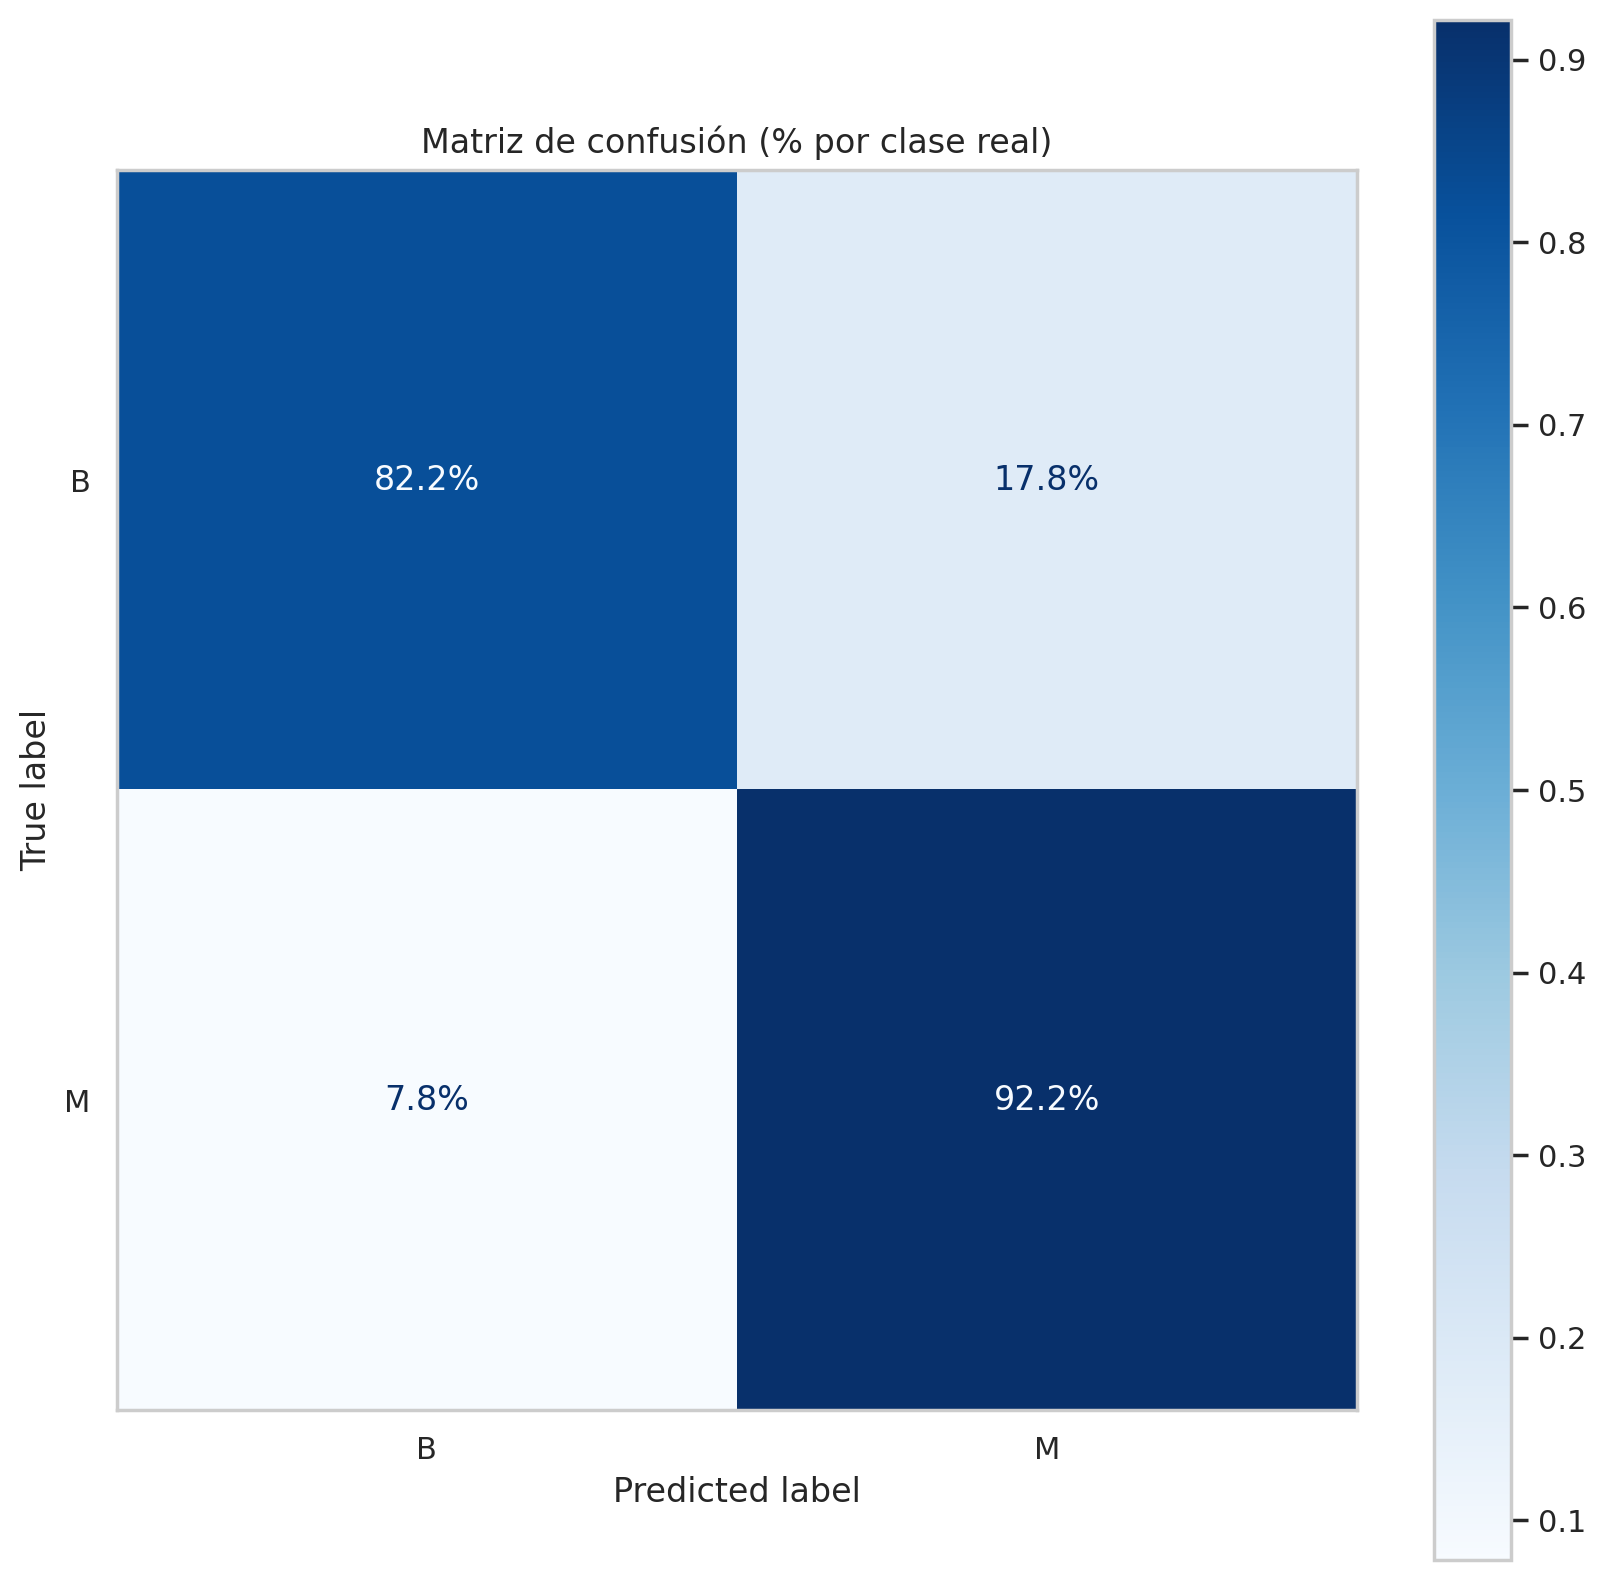

In [45]:
matriz_confusion(modelo, xtest, ytest);

In [46]:
val = validar_modelo(modelo, xtrain, ytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.932 +/- 0.051


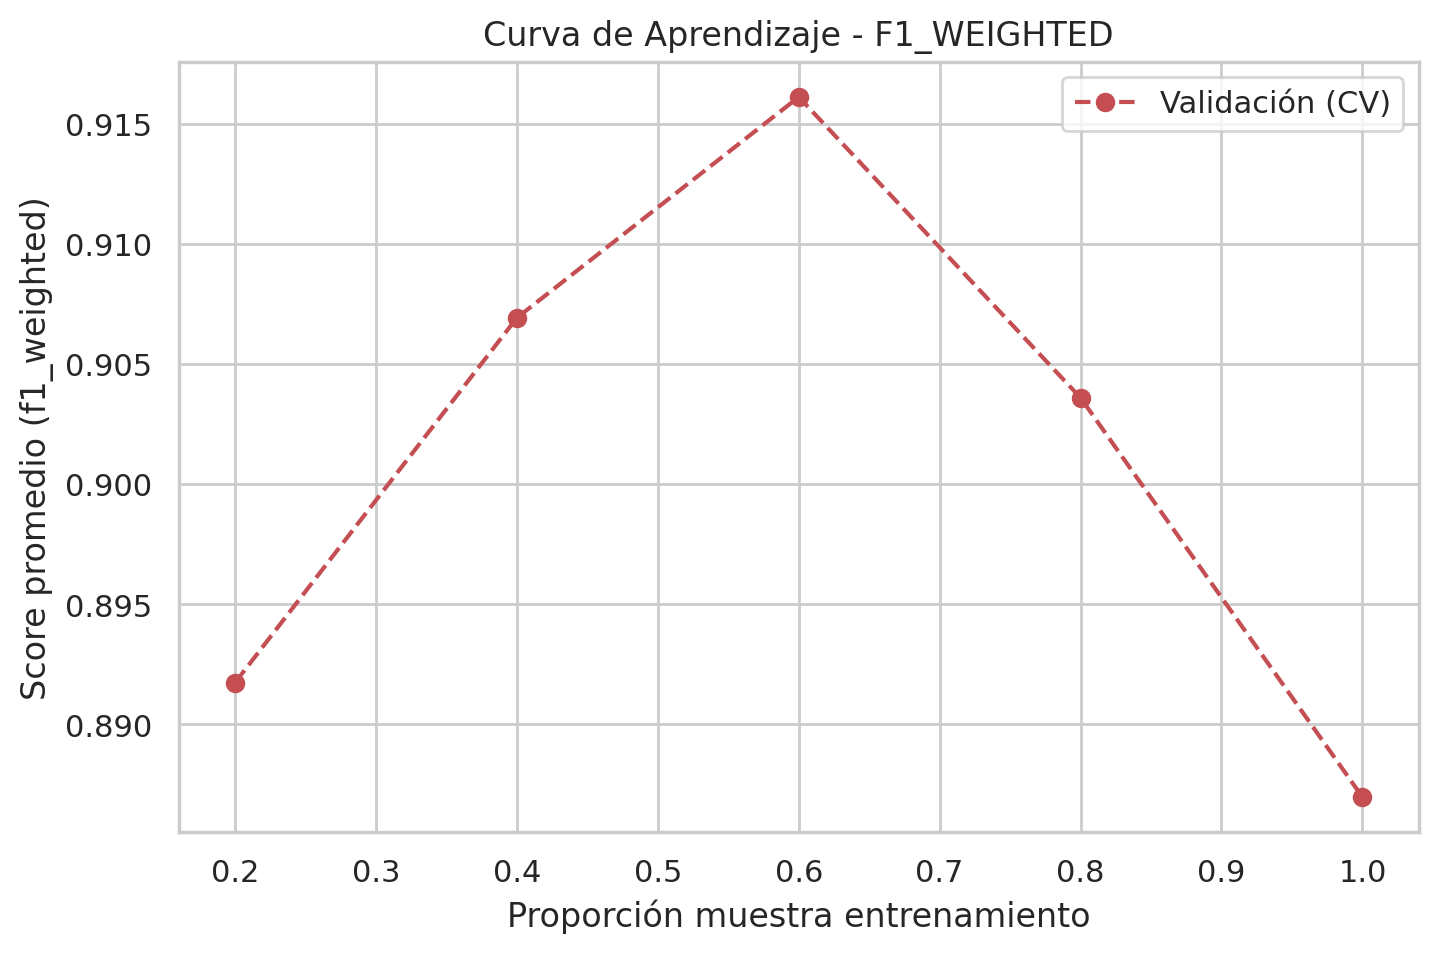

In [47]:
datos_pp, _ = preprocesar_datos(cancer, 'diagnosis')
X = datos_pp.drop('diagnosis', axis=1)
y = datos_pp['diagnosis']
curva_aprendizaje(modelo, X, y, 'f1_weighted', 10);

Comparando train y test en `reports_clas` valoramos el **sobreentrenamiento**: tras la optimización ambas quedan próximas. Conviene recordar que un **árbol único** tiene **alta varianza** (su F1 de test puede quedar por debajo de la de CV); por eso en la práctica se usan **conjuntos de árboles** (Random Forest, boosting).



### <font color="steelblue">7.3. Importancia de variables y árbol interpretable</font>

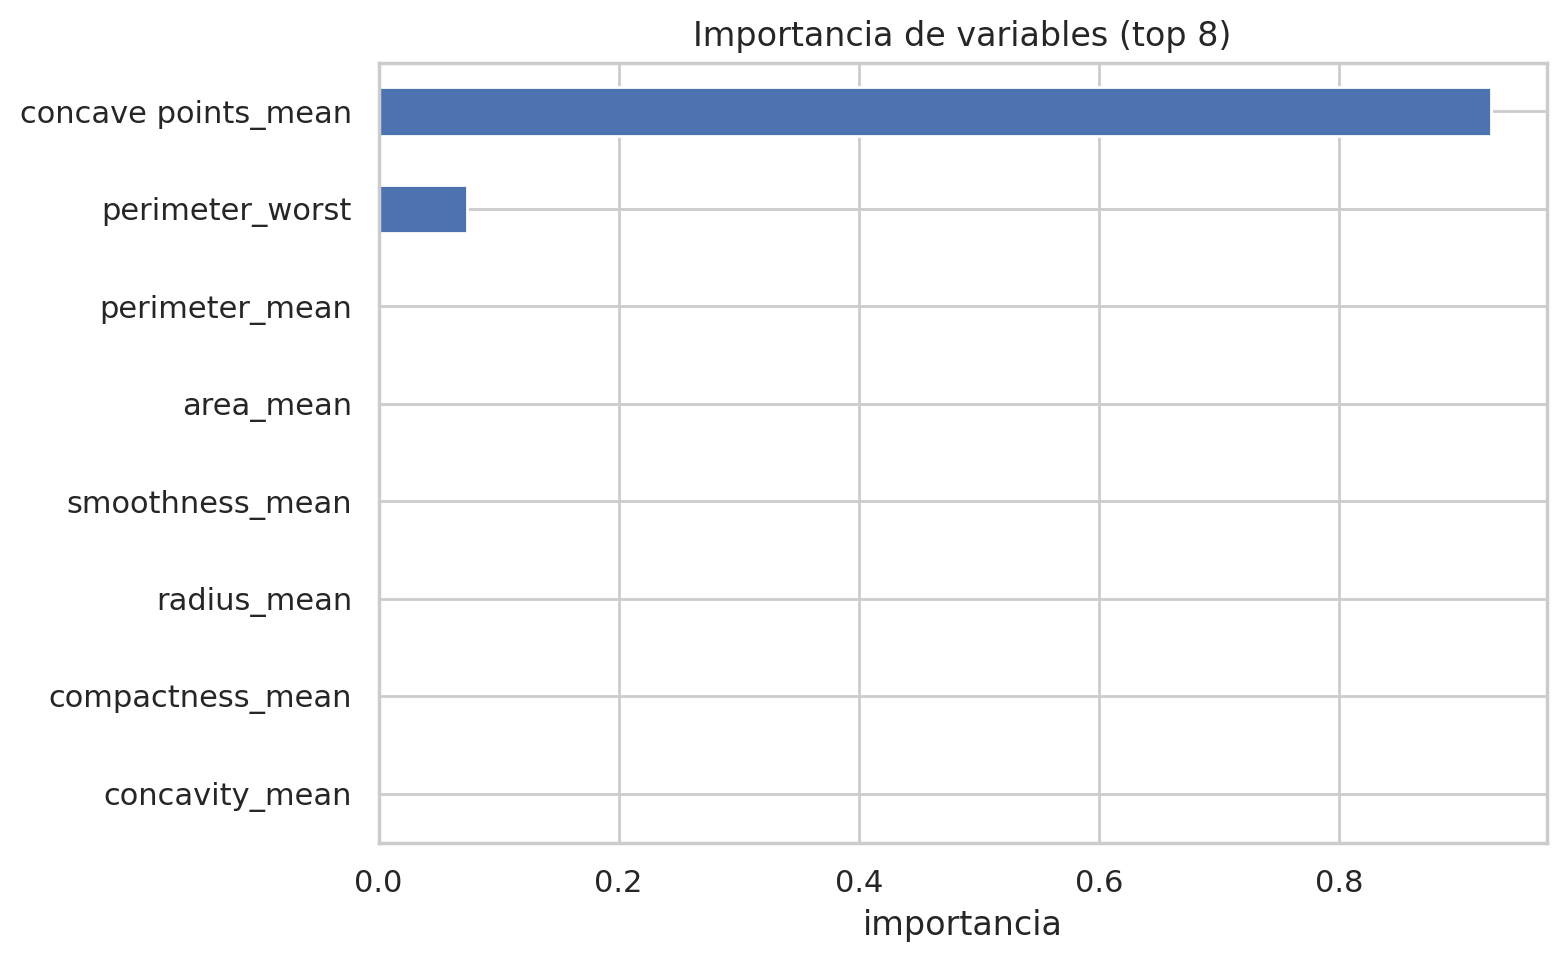

In [48]:
imp = pd.Series(modelo.feature_importances_, index=xtrain.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5)); imp.head(8).iloc[::-1].plot.barh()
plt.title('Importancia de variables (top 8)')
plt.xlabel('importancia')
plt.tight_layout()
plt.show()
arbol_vis = DecisionTreeClassifier(max_depth=3, random_state=0).fit(xtrain, ytrain)

Y el **árbol interpretable** (profundidad 3) con Graphviz, legible incluso con 30 variables:

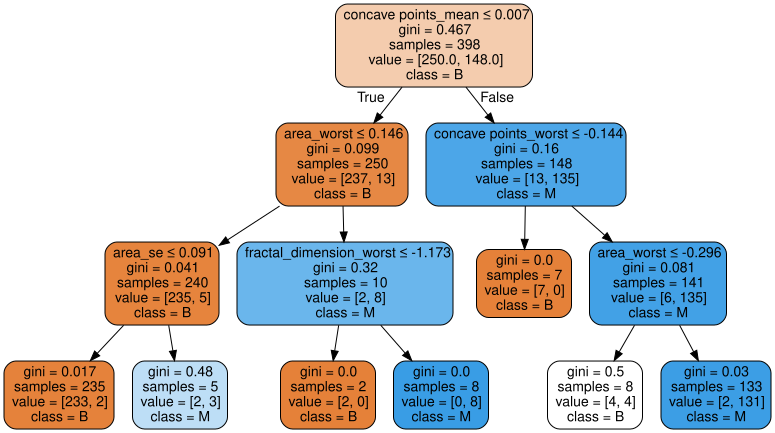

In [49]:
arbol_graphviz(arbol_vis, list(xtrain.columns), ['B', 'M'])

Unas pocas variables (concavidad y tamaño del núcleo) concentran casi toda la separación. El árbol de profundidad 3 es un **modelo legible** que un clínico podría seguir regla a regla.



### <font color="steelblue">7.4. Selección de variables por evolución de la importancia</font>

En lugar de una búsqueda recursiva, usamos directamente la **importancia**: ordenamos las variables de mayor a menor y vemos **cuánta F1 (en CV) se consigue con las $k$ más importantes**. El **codo** de la curva indica el conjunto mínimo suficiente.

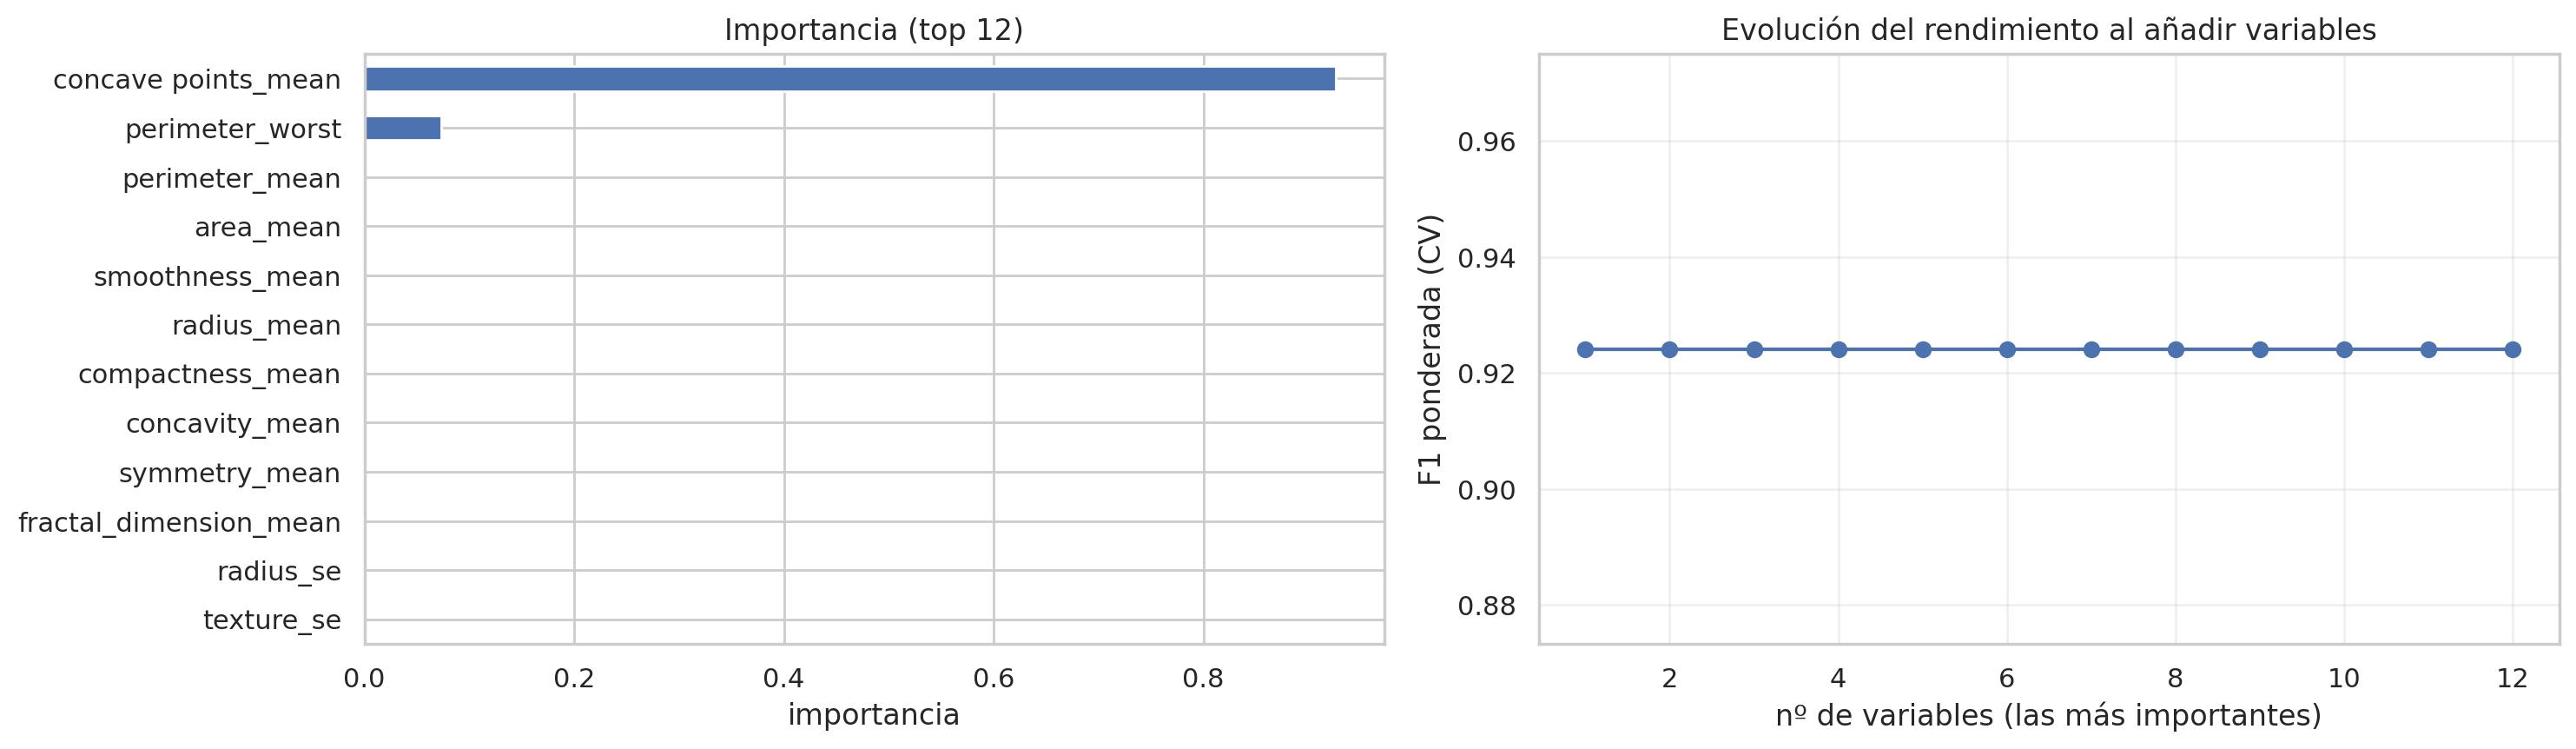

Conjunto mínimo suficiente ≈ top 1: ['concave points_mean']
F1 test modelo reducido: 0.862


In [50]:
orden = imp.index.tolist()
ks = list(range(1, 13)); f1_k = []
for k in ks:
    cols = orden[:k]
    f1_k.append(cross_val_score(DecisionTreeClassifier(random_state=0, **gs.best_params_), xtrain[cols], ytrain, cv=5, scoring='f1_weighted').mean())
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
imp.head(12).iloc[::-1].plot.barh(ax=ax[0]); ax[0].set_title('Importancia (top 12)')
ax[0].set_xlabel('importancia')
ax[1].plot(ks, f1_k, 'o-'); ax[1].set_xlabel('nº de variables (las más importantes)')
ax[1].set_ylabel('F1 ponderada (CV)')
ax[1].set_title('Evolución del rendimiento al añadir variables'); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.show()
k_codo = int(np.argmax(np.array(f1_k) >= max(f1_k) - 0.005) + 1)
print(f'Conjunto mínimo suficiente ≈ top {k_codo}:', orden[:k_codo])
modelo_red = DecisionTreeClassifier(random_state=0, **gs.best_params_).fit(xtrain[orden[:k_codo]], ytrain)
print('F1 test modelo reducido:', round(f1_score(ytest, modelo_red.predict(xtest[orden[:k_codo]]), average='weighted'), 3))

La curva **se aplana enseguida**: con muy **pocas** variables (las de mayor importancia) se alcanza casi la F1 máxima, porque el árbol ya concentra la decisión en ellas. El conjunto reducido da un modelo más simple con rendimiento comparable.



### <font color="steelblue">7.5. Equilibrado de clases</font>

In [51]:
modelo_bal = DecisionTreeClassifier(random_state=0, class_weight='balanced', **gs.best_params_).fit(xtrain, ytrain)
xtr_sm, ytr_sm = SMOTE(random_state=RNG).fit_resample(xtrain, ytrain)
modelo_smote = DecisionTreeClassifier(random_state=0, **gs.best_params_).fit(xtr_sm, ytr_sm)
xtr_nm, ytr_nm = NearMiss().fit_resample(xtrain, ytrain)
modelo_nm = DecisionTreeClassifier(random_state=0, **gs.best_params_).fit(xtr_nm, ytr_nm)
resumen = pd.DataFrame({'modelo': ['Base', 'class_weight=balanced', 'SMOTE', 'NearMiss'],
    'recall_maligno': [recall_score(ytest, m.predict(xtest), pos_label='M') for m in [modelo, modelo_bal, modelo_smote, modelo_nm]],
    'f1_ponderada': [f1_score(ytest, m.predict(xtest), average='weighted') for m in [modelo, modelo_bal, modelo_smote, modelo_nm]]})
resumen.round(3)

,modelo,recall_maligno,f1_ponderada
0,Base,0.922,0.862
1,class_weight=balanced,0.922,0.862
2,SMOTE,0.922,0.867
3,NearMiss,0.922,0.873


El equilibrado busca **mejorar el
recall de la clase maligna** —el error clínicamente más grave— normalmente a cambio de algo de F1 global. La estrategia adecuada depende del coste de cada tipo de error. En este caso todas las soluciones proporcionaan valores similares.



# <font color="steelblue">8. Aplicación 2: Abulones (tres clases)</font>

Clasificamos el **sexo** de abulones (M, F, I = infantil) a partir de medidas físicas. Es un problema **difícil** y con **tres clases**, ideal para ver los árboles en multiclase.

In [52]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone_clean.csv'
abalone = pd.read_csv(url, index_col=0)
abalone['Sex'] = abalone['Sex'].astype('category')

Las tres clases están **bastante equilibradas**. Aun así usamos **F1 ponderada** para ser coherentes. Preparamos los datos con el flujo del curso.

In [53]:
astrain_raw, astest_raw = split_sample(abalone, 'Sex', 0.3, 0, True)
astrain, aprep = preprocesar_datos(astrain_raw, 'Sex')
astest,  _     = preprocesar_datos(astest_raw,  'Sex', aprep)
axtrain, aytrain = astrain.drop('Sex', axis=1), astrain['Sex']
axtest,  aytest  = astest.drop('Sex', axis=1),  astest['Sex']
print('Entrenamiento:', axtrain.shape, '| Test:', axtest.shape)

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras
Entrenamiento: (2923, 8) | Test: (1254, 8)


### <font color="steelblue">8.1. Árbol base y optimización</font>

In [54]:
abase = DecisionTreeClassifier(random_state=0).fit(axtrain, aytrain)
print(f'Árbol completo: prof {abase.get_depth()}, hojas {abase.get_n_leaves()} | F1 train {f1_score(aytrain, abase.predict(axtrain), average="weighted"):.3f} | F1 test {f1_score(aytest, abase.predict(axtest), average="weighted"):.3f}')
agrid = {'max_depth': [2, 3, 4, 5, None], 'min_samples_leaf': [0.05, 0.10, 0.15, 0.20, 0.25], 'ccp_alpha': [0.0, 0.005, 0.01, 0.02]}
ags = GridSearchCV(DecisionTreeClassifier(random_state=0), agrid, scoring='f1_weighted', cv=KFold(5)).fit(axtrain, aytrain)
print('Mejores hiperparámetros:', ags.best_params_, '| F1 ponderada CV:', round(ags.best_score_, 3))
amodelo = ags.best_estimator_

Árbol completo: prof 29, hojas 862 | F1 train 1.000 | F1 test 0.497
Mejores hiperparámetros: {'ccp_alpha': 0.0, 'max_depth': 3, 'min_samples_leaf': 0.05} | F1 ponderada CV: 0.532


El árbol completo vuelve a sobreajustar (F1 train muy alta, test mucho menor). Tras optimizar, valoramos la clasificación.

### <font color="steelblue">8.2. Valoración de la clasificación</font>

In [55]:
reports_clas(amodelo, axtrain, aytrain, axtest, aytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.49      0.55      0.52       915
           I       0.67      0.82      0.74       939
           M       0.46      0.33      0.38      1069

    accuracy                           0.56      2923
   macro avg       0.54      0.57      0.55      2923
weighted avg       0.54      0.56      0.54      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.43      0.49      0.45       392
           I       0.68      0.78      0.72       403
           M       0.39      0.29      0.33       459

    accuracy                           0.51      1254
   macro avg       0.50      0.52      0.50      1254
weighted avg       0.49      0.51      0.50      1254



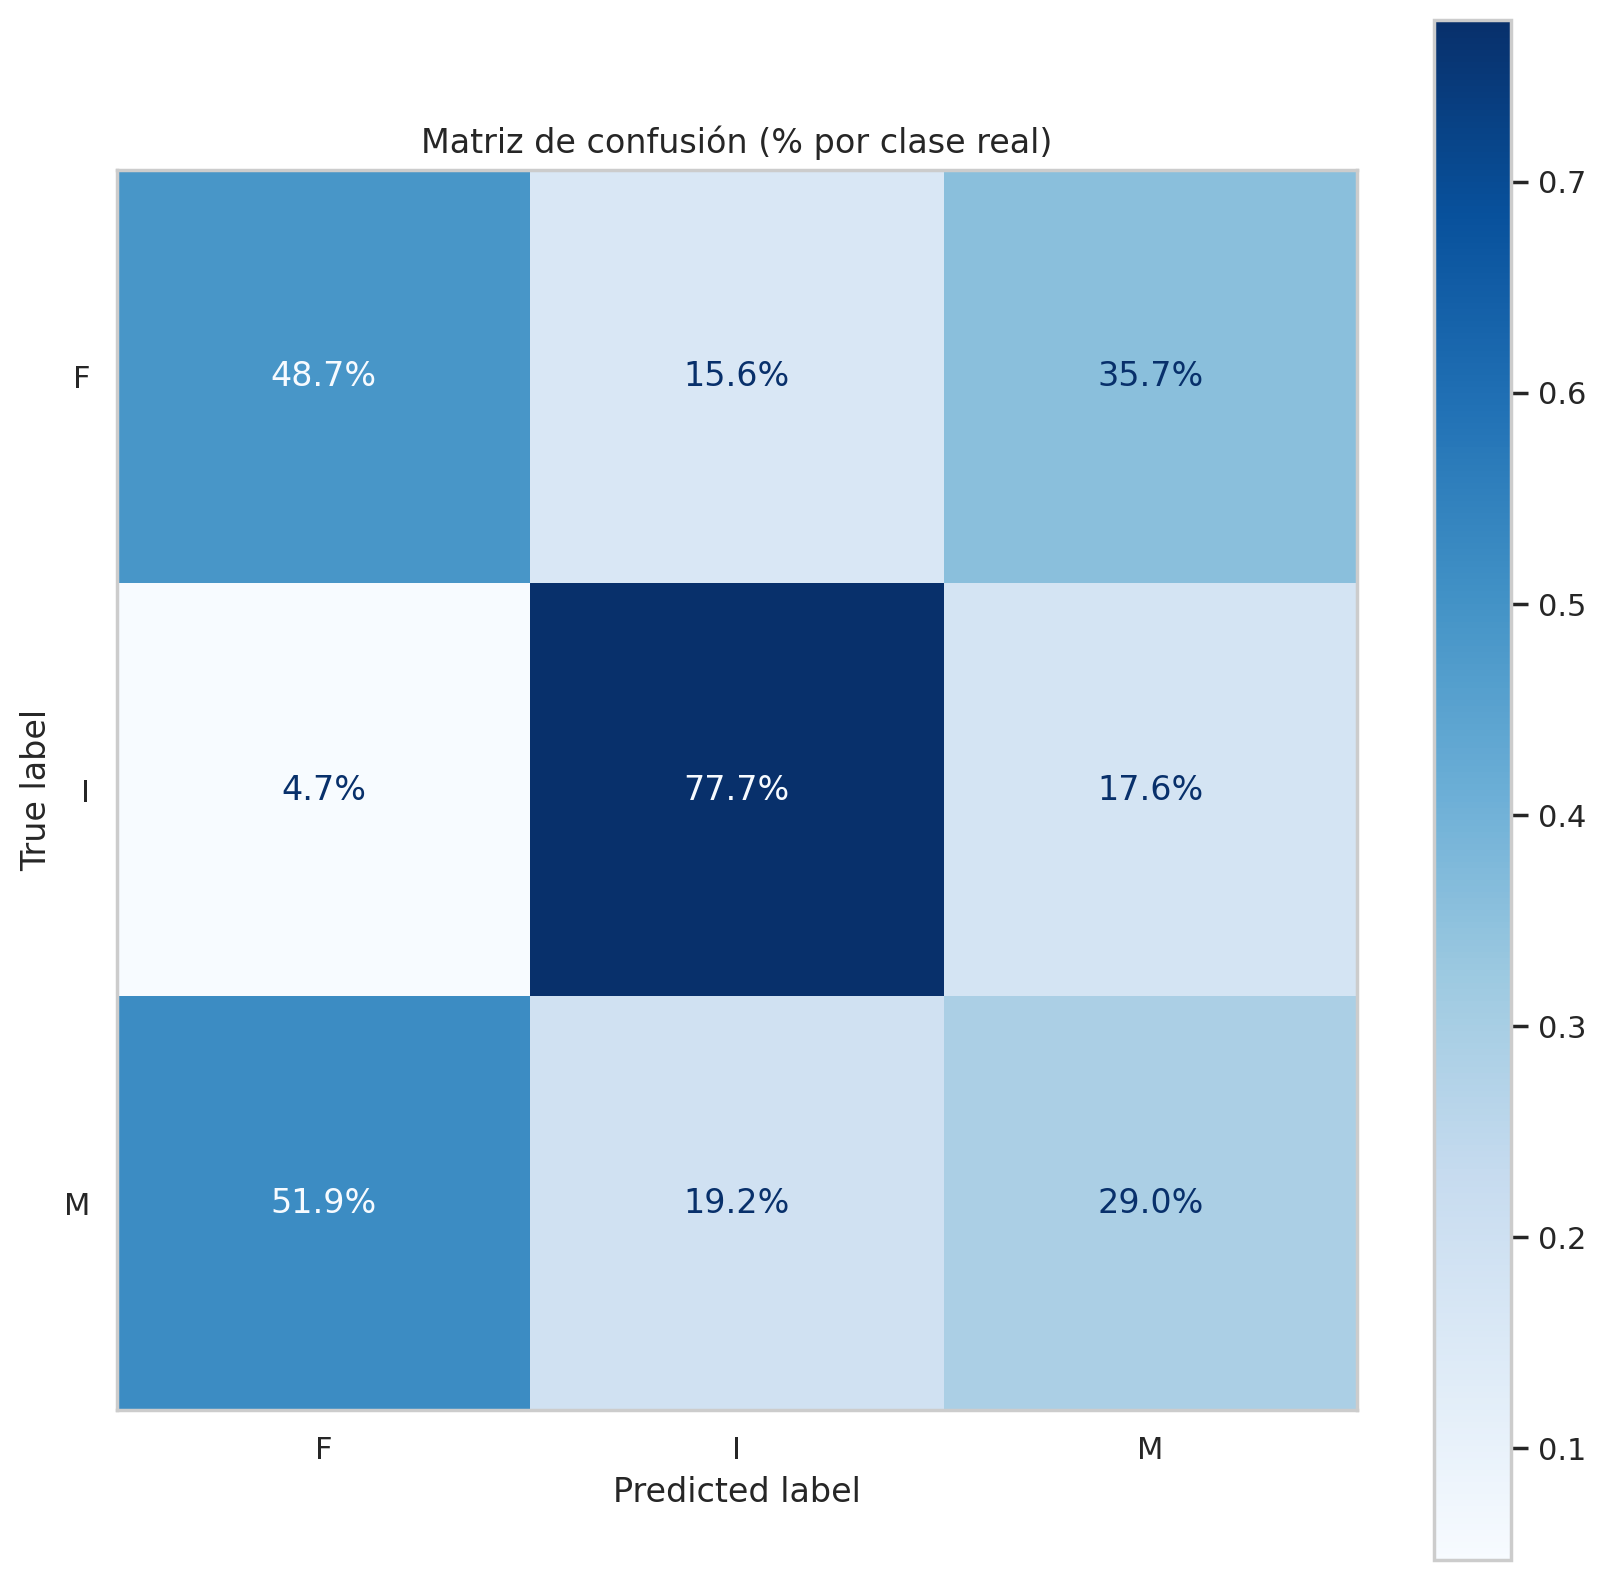

In [56]:
matriz_confusion(amodelo, axtest, aytest);

In [57]:
aval = validar_modelo(amodelo, axtrain, aytrain, 'f1_weighted', 10)

Validacion cruzada (10 folds, score=f1_weighted): media = 0.545 +/- 0.022


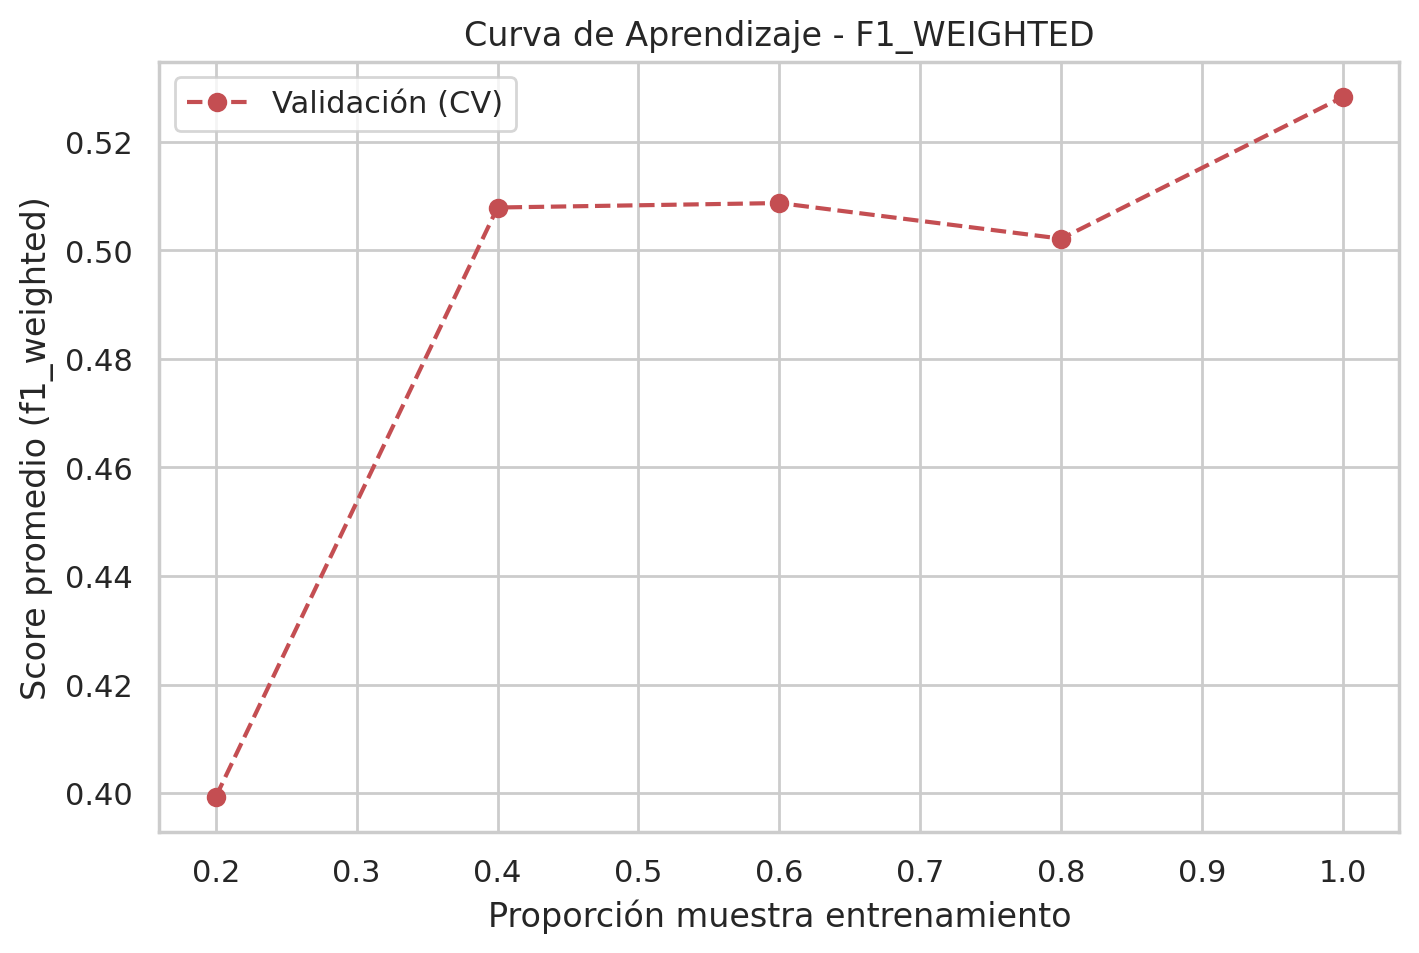

In [58]:
adatos_pp, _ = preprocesar_datos(abalone, 'Sex')
aX = adatos_pp.drop('Sex', axis=1)
aY = adatos_pp['Sex']
curva_aprendizaje(amodelo, aX, aY, 'f1_weighted', 10);

El rendimiento es **modesto** (F1 en torno a 0.5): la matriz de confusión muestra que **M y F se confunden mucho** entre sí (físicamente son muy parecidos), mientras que los **infantiles (I)** se distinguen mejor por su menor tamaño. La curva de aprendizaje queda **plana y baja**: estamos ante un problema con **alto sesgo** para un árbol único —más datos no ayudarían; harían falta variables más informativas o modelos más potentes—.



### <font color="steelblue">8.3. Importancia y selección por evolución</font>

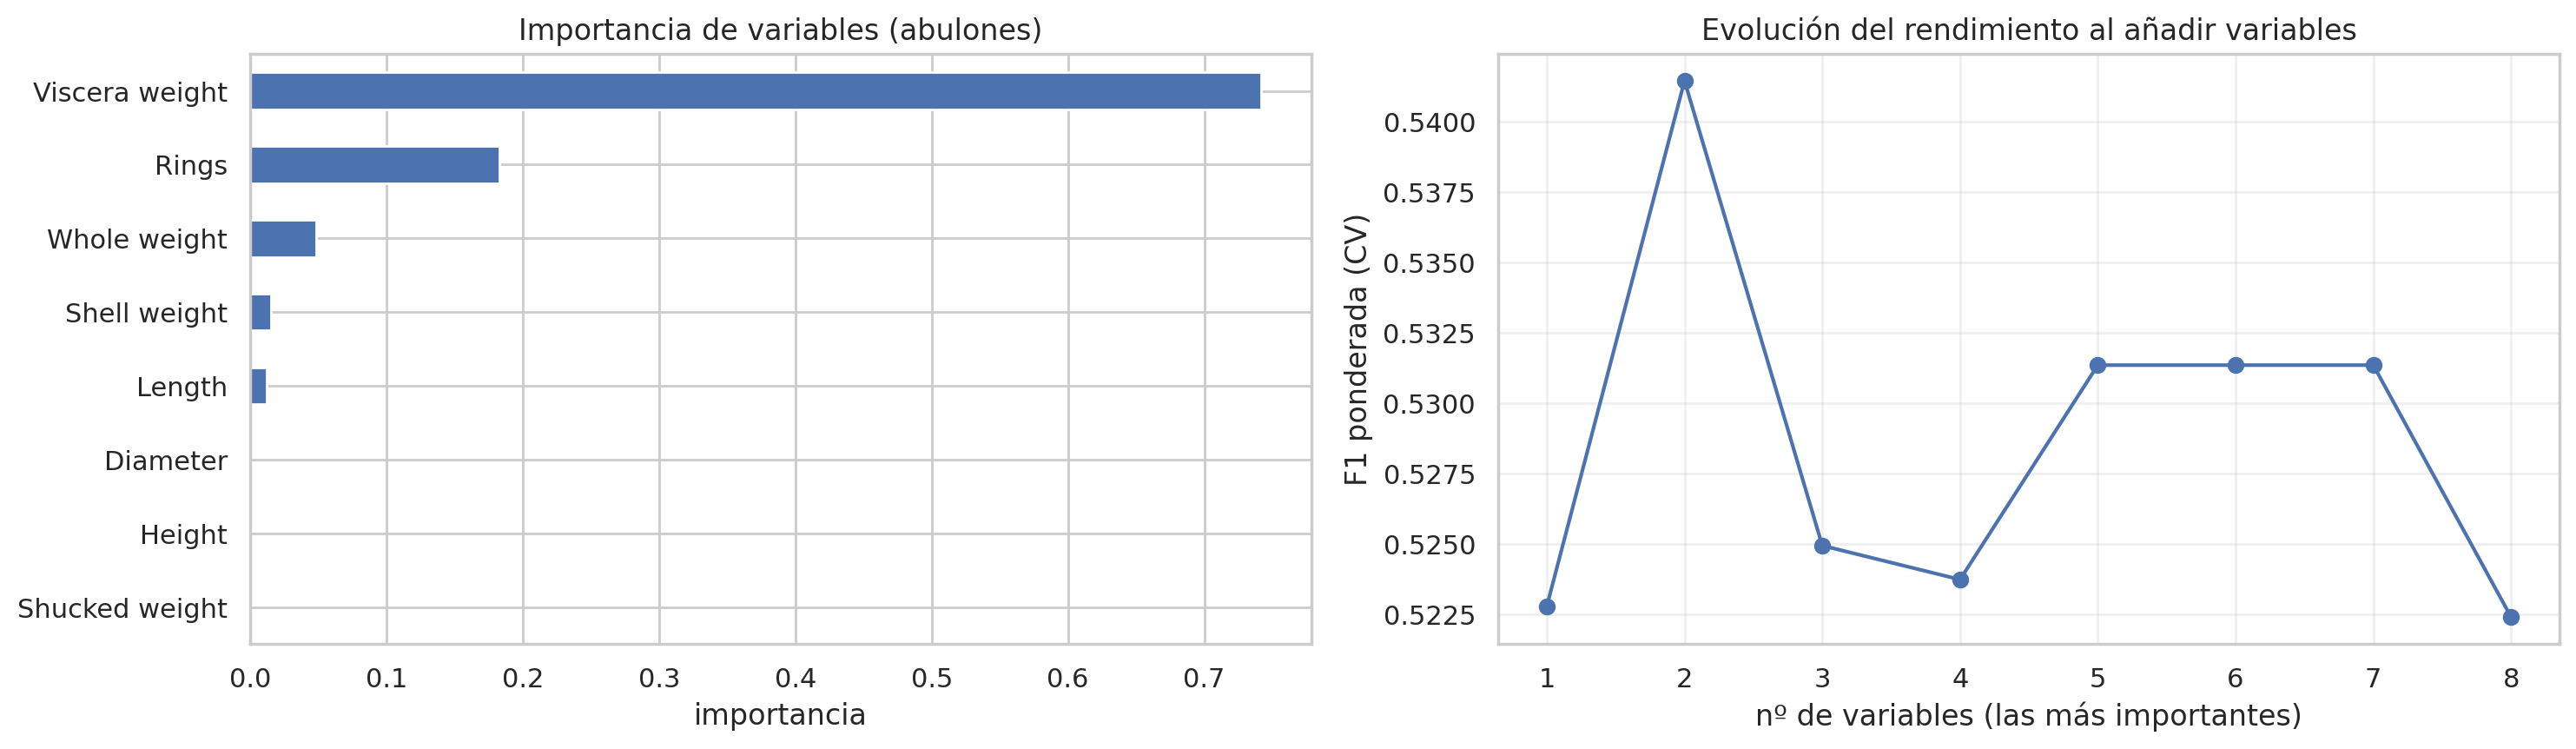

Variable más importante: Viscera weight ( 0.741 )


In [59]:
aimp = pd.Series(amodelo.feature_importances_, index=axtrain.columns).sort_values(ascending=False)
aorden = aimp.index.tolist(); aks = list(range(1, len(aorden) + 1)); af1 = []
for k in aks:
    af1.append(cross_val_score(DecisionTreeClassifier(random_state=0, **ags.best_params_), axtrain[aorden[:k]], aytrain, cv=5, scoring='f1_weighted').mean())
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
aimp.iloc[::-1].plot.barh(ax=ax[0]); ax[0].set_title('Importancia de variables (abulones)')
ax[0].set_xlabel('importancia')
ax[1].plot(aks, af1, 'o-'); ax[1].set_xlabel('nº de variables (las más importantes)')
ax[1].set_ylabel('F1 ponderada (CV)')
ax[1].set_title('Evolución del rendimiento al añadir variables'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print('Variable más importante:', aorden[0], '(', round(aimp.iloc[0], 3), ')')

En los abulones una variable (el peso de las vísceras) **concentra buena parte** de la importancia, pero la curva de evolución es **plana y baja**: añadir más variables apenas mejora una F1 ya de por sí pobre, lo que confirma la **dificultad intrínseca** del problema para un árbol de decisión.



# <font color="steelblue">9. Referencias</font>

* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 8). Springer.
* Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (cap. 9).
* Breiman, Friedman, Olshen & Stone (1984). *Classification and Regression Trees* (CART). Wadsworth.
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Decision Trees*: https://scikit-learn.org/stable/modules/tree.html